In [1]:
from pathlib import Path
from functools import partial

import numpy as np

from matplotlib import pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time

from jwst import datamodels

from tqdm.auto import tqdm

In [2]:
import os
os.environ['STPSF_PATH'] = os.path.expanduser('~/.cache/stpsf-data')

import stpsf

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [3]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
scoord = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')  # the ra and dec would have a delta in an inference loop so is different each time
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

The below should be replaced with ``stpsf.setup_sim_to_match_file(str(n6791fits[0]))`` once that works

In [4]:
nrs = stpsf.NIRSpec()
nrs.detector = dm0.meta.instrument.detector
nrs.filter = dm0.meta.instrument.filter
nrs.disperser = dm0.meta.instrument.grating

xdet, ydet = swcs.transform('detector', 'sca', *np.indices(slit.data.shape)[::-1])
nrs.detector_position = (np.mean(xdet), np.mean(ydet))

nrs.load_wss_opd_by_date(Time(dm0.meta.exposure.mid_time, format='mjd'))

nrs.image_mask = 'Single MSA open shutter'

iterating query, tdelta=3.0

MAST OPD query around UTC: 60136.5904089294
                        MJD: 60136.5904089294

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/R2023071203-NRCA3_FP1-1.fits
	Date (MJD):	 60136.5363
	Delta time:	 -0.0542 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/R2023071403-NRCA3_FP1-1.fits
	Date (MJD):	 60138.8979
	Delta time:	 2.3075 days
User requested choosing OPD time closest in time to 60136.5904089294, which is R2023071203-NRCA3_FP1-1.fits, delta time -0.054 days
Importing and format-converting OPD from /home/erik/.cache/stpsf-data/MAST_JWST_WSS_OPDs/R2023071203-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)


In [5]:
msa_slit_width = 0.2 #u.arcsec
msa_slit_height = 0.46 #u.arcsec

offset0_x = slit.source_xpos*msa_slit_width
offset0_y = slit.source_ypos*msa_slit_height

nrs.options.update({'source_offset_x': offset0_x, 
                    'source_offset_y': offset0_y})

# Make data

In [6]:
n = 1024
path = Path('psfarrs.npz')

if path.is_file():
    data = np.load(path)

    psfarrs = data['psfarrs']
    psfxs = data['xs']
    psfys = data['ys']

    if len(psfxs) == len(psfys) == len(psfarrs) == n:
        print('Loaded precomputed PSF array')
    else:
        print('Precomputed PSF array has wrong shape, recomputing')
        psfarrs = None

if psfarrs is None:
    psfxs = (np.random.rand(n)-0.5)*msa_slit_width
    psfys = (np.random.rand(n)-0.5)*msa_slit_height

    psfarrs = []
    for x, y in tqdm(list(zip(psfxs, psfys))):
        nrs.options.update({'source_offset_x': x, 
                            'source_offset_y': y})
        psf = nrs.calc_psf(fov_pixels=20, monochromatic=1.1e-6, oversample=8)
        psfarrs.append(psf['OVERDIST'].data)

    psfarrs = np.array(psfarrs)
    np.savez('psfarrs.npz', psfarrs=psfarrs, xs=psfxs, ys=psfys)

psfarrs.shape

Loaded precomputed PSF array


(1024, 160, 160)

# INR w/ 1d wavelets

In [7]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax

rkey = jax.random.PRNGKey(42)

jax.devices()

[CudaDevice(id=0)]

In [8]:
class GaborLayer(eqx.Module):
    w0: float
    s0: float
    lin1: eqx.nn.Linear
    #lin2: eqx.nn.Linear
    
    def __init__(self, nin, nout, w0=20, s0=10, rkey=None,trainable0s=True):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rk1, = jax.random.split(rkey, 1)
        self.lin1 = eqx.nn.Linear(nin, nout, key=rk1)

        if trainable0s:
            self.w0 = jnp.array(w0, dtype=jnp.float32)
            self.s0 = jnp.array(s0, dtype=jnp.float32)
        else:
            self.w0 = w0
            self.s0 = s0

    def __call__(self, x):
        x1 = self.lin1(x)

        return self.nonlinearity(x1)
    
class CosGaborLayer(GaborLayer):
    def nonlinearity(self, x1):
        return jnp.cos(self.w0 * x1) * jnp.exp(-(x1 * self.s0)**2)

class ComplexGaborLayer(GaborLayer):
    def nonlinearity(self, x1):
        t1 = x1 * (self.w0 * 1j)

        z = x1 * self.s0
        #t2 = jnp.abs(z)**2
        #t2 = z * z.conj()
        t2 = jnp.real(z)**2 + jnp.imag(z)**2
        return jnp.exp(t1-t2)


class PSFWIRE(eqx.Module):
    layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       rkey=None,
                       complex=True,
                       w0=20, s0=10,
                       trainable_activations=False):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        if complex:
            layers = [ComplexGaborLayer(n_in_coo, hidden_size, rkey=rkeys[0],
                                    w0=w0, s0=s0, trainable0s=trainable_activations)]
            for i in range(num_hidden_layers):
                layers.append(ComplexGaborLayer(hidden_size, hidden_size, rkey=rkeys[i+1],
                                            w0=w0, s0=s0, trainable0s=trainable_activations))

            layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
            layers.append(jnp.real)
        else:
            layers = [CosGaborLayer(n_in_coo, hidden_size, rkey=rkeys[0],
                                    w0=w0, s0=s0, trainable0s=trainable_activations)]
            for i in range(num_hidden_layers):
                layers.append(CosGaborLayer(hidden_size, hidden_size, rkey=rkeys[i+1],
                                            w0=w0, s0=s0, trainable0s=trainable_activations))

            layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
        layers.append(final_activation)

        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()  

model = PSFWIRE(n_in_coo=4)
print(model)

x = jax.random.uniform(rkey, (10, 4))
jax.vmap(model)(x)

PSFWIRE(
  layers=[
    ComplexGaborLayer(
      w0=20,
      s0=10,
      lin1=Linear(
        weight=f32[256,4],
        bias=f32[256],
        in_features=4,
        out_features=256,
        use_bias=True
      )
    ),
    ComplexGaborLayer(
      w0=20,
      s0=10,
      lin1=Linear(
        weight=f32[256,256],
        bias=f32[256],
        in_features=256,
        out_features=256,
        use_bias=True
      )
    ),
    ComplexGaborLayer(
      w0=20,
      s0=10,
      lin1=Linear(
        weight=f32[256,256],
        bias=f32[256],
        in_features=256,
        out_features=256,
        use_bias=True
      )
    ),
    Linear(
      weight=f32[1,256],
      bias=f32[1],
      in_features=256,
      out_features=1,
      use_bias=True
    ),
    <PjitFunction of <function real at 0x7f4961b6dc70>>,
    <PjitFunction of <function sigmoid at 0x7f496093e560>>
  ]
)


Array([0.5256167 , 0.577195  , 0.52515805, 0.5971476 , 0.5731658 ,
       0.530591  , 0.5551306 , 0.5252538 , 0.48758823, 0.49248388],      dtype=float32)

In [9]:
def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

def mse_plus_log_loss_fn(model, x, y, logfrac=0.01, eps=1e-8):
    y_pred = jax.vmap(model)(x)
    mse = (y_pred - y)**2
    log_loss = (jnp.log(y_pred+eps) - jnp.log(y+eps))**2
    return jnp.mean(mse + logfrac*log_loss)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, losslamb=0.01):
    loss, grads = eqx.filter_value_and_grad(mse_plus_log_loss_fn)(model, x, y, losslamb)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

class CoordinateNormalizer:
    def __init__(self, coord):
        self.min = jnp.min(coord)
        self.ptp = jnp.ptp(coord)

    def normalize(self, coord):
        return (coord - self.min)/self.ptp * 2 - 1
    
    def denormalize(self, norm_coord):
        return (norm_coord + 1)/2 * self.ptp + self.min


### Test with just a single psf location/2d

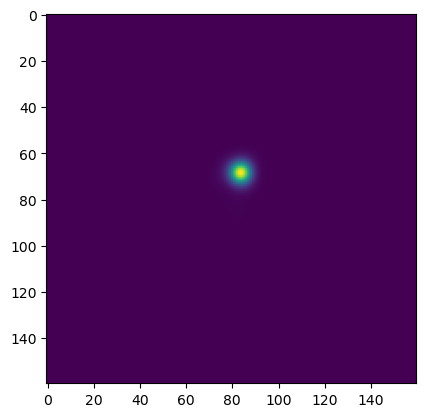

In [10]:
plt.imshow(psfarrs[512])

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 2.0234602e-05 relative to image: 0.04022046


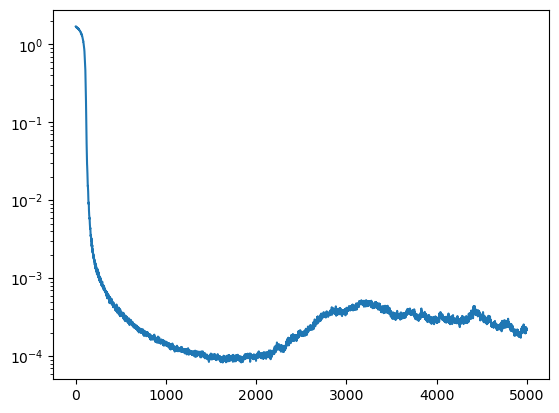

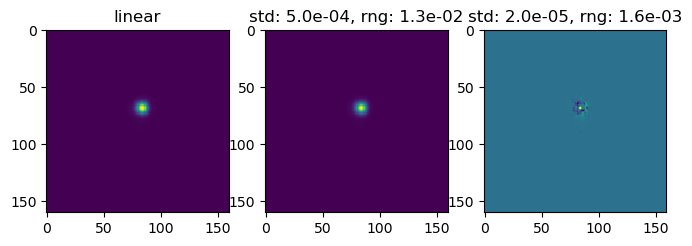

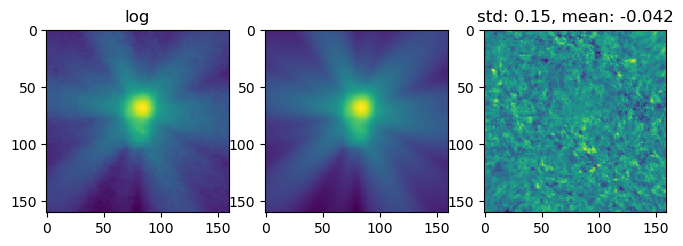

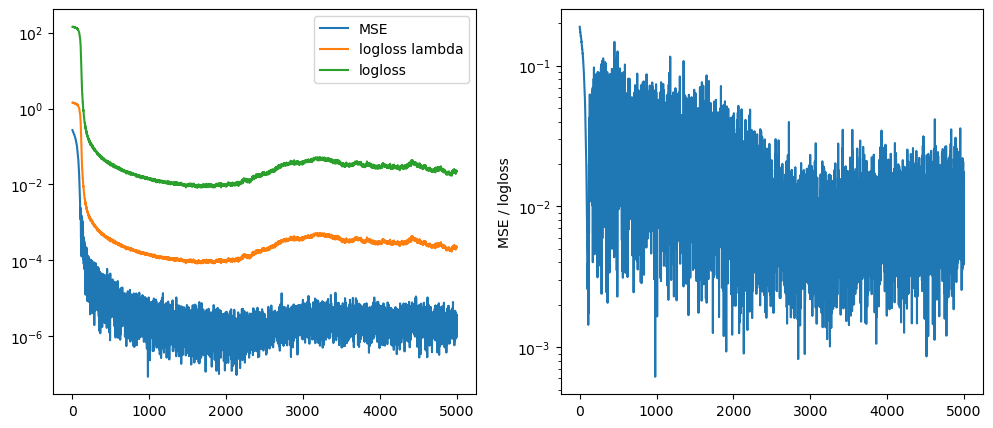

In [84]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

In [85]:
vm = jax.jit(jax.vmap(model))
vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

%timeit vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

472 μs ± 14.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


y1 shape: (160, 160, 1)


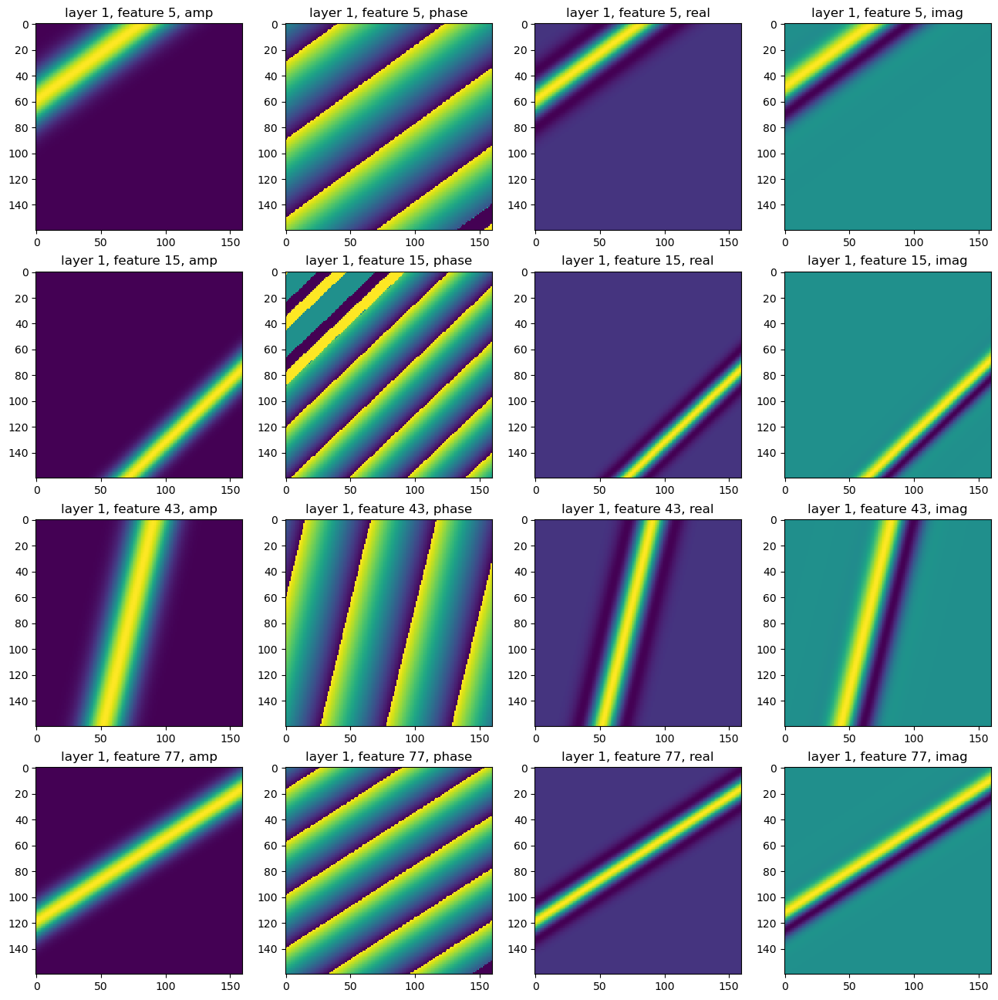

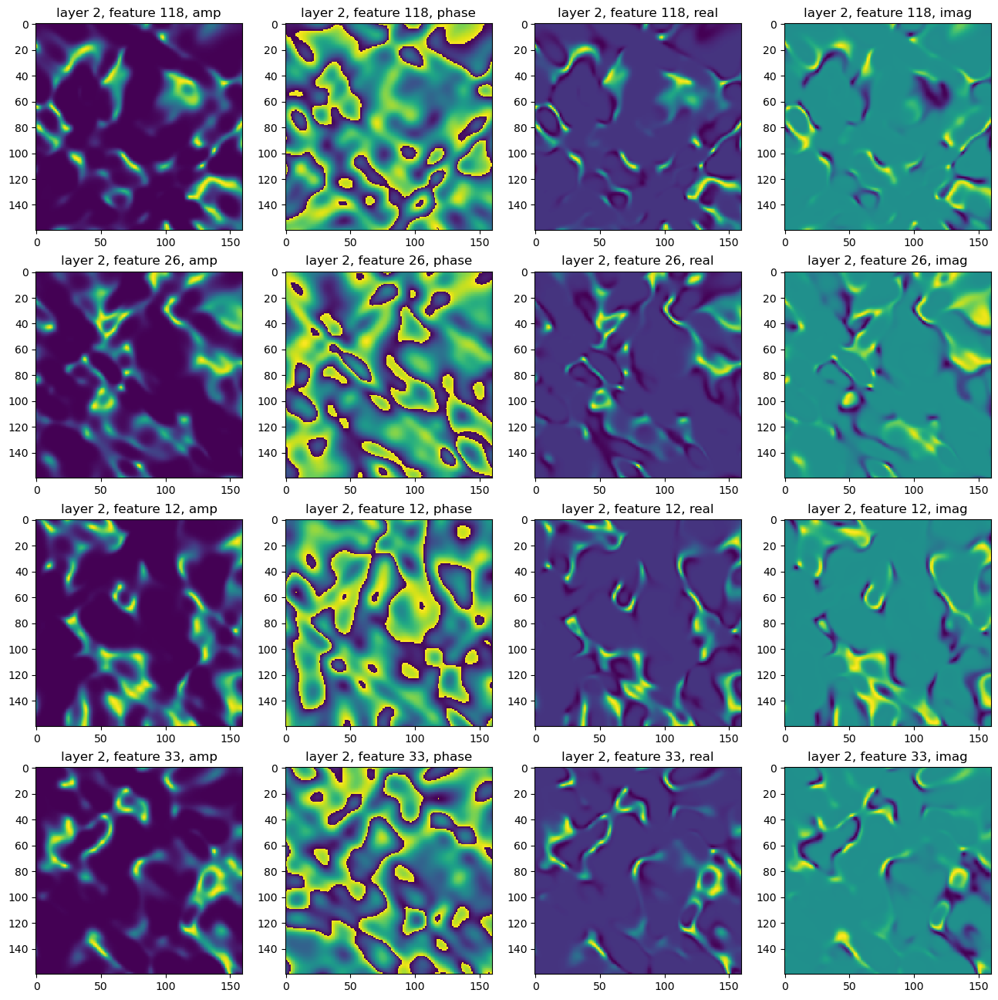

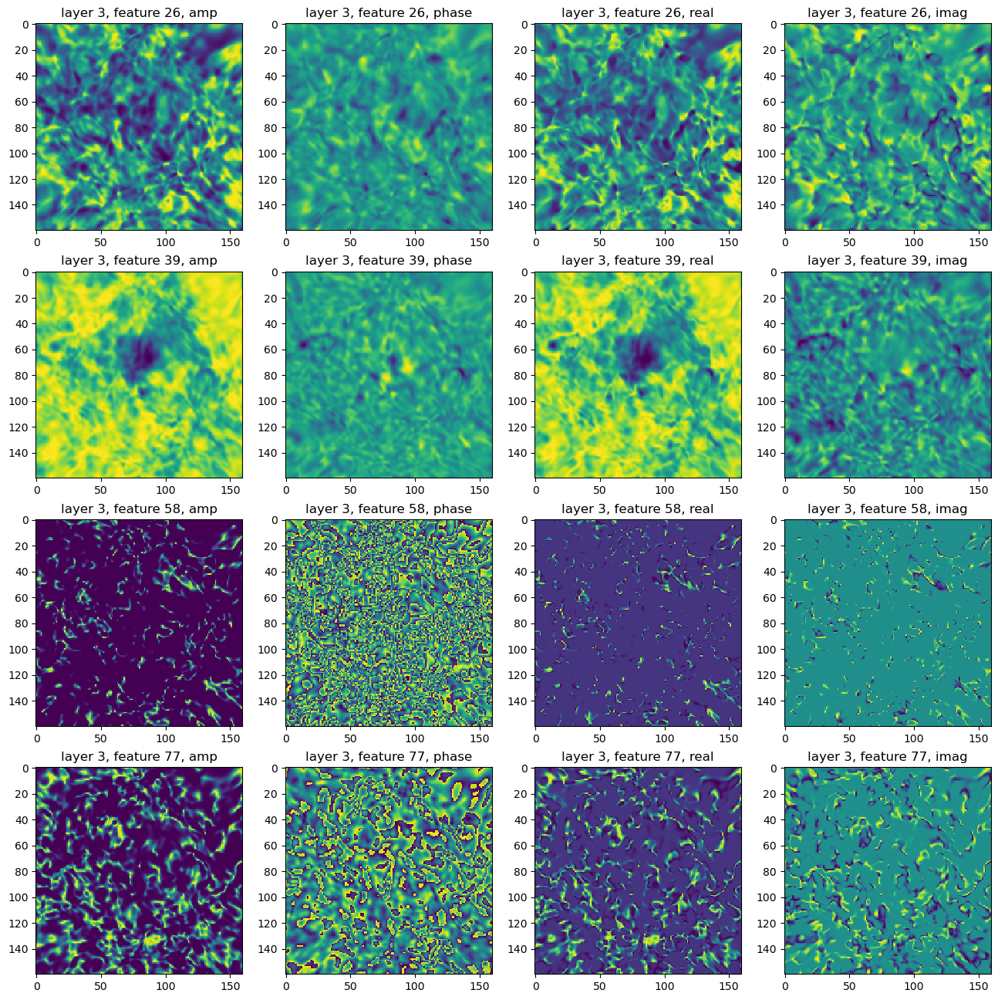

<Figure size 640x480 with 0 Axes>

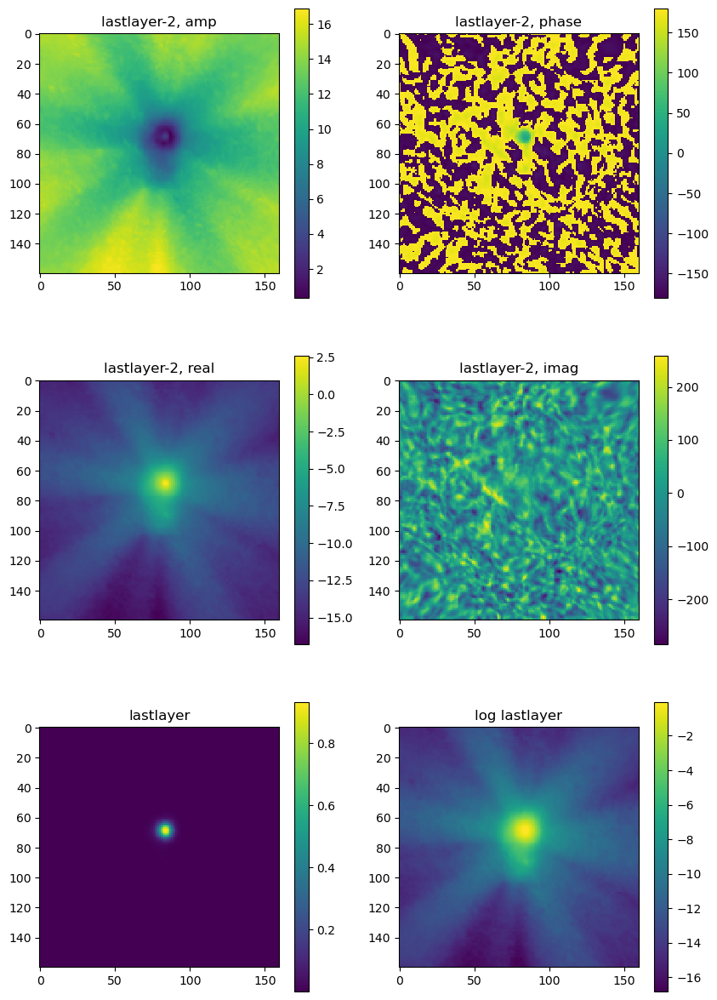

In [86]:
def viz_layers2(model, xs, axlen=4, figsize=(16, 16)):
    nl = len(model.layers)
    def eval_layers(x, n):
        for i in range(n):
            x = model.layers[i](x)
        return x
    
    for n in range(1, nl-2):
        yl =  jax.vmap(partial(eval_layers, n=n))(xs).reshape(psfarrs.shape[1:] + (-1,))
        _, axs = plt.subplots(axlen, 4, figsize=figsize)
        idxs = np.random.choice(np.arange(yl.shape[-1]), size=axlen, replace=False)
        for axrow, idx in zip(axs, idxs):
            axrow[0].imshow(jnp.abs(yl[..., idx]), interpolation='nearest')
            axrow[0].set_title(f'layer {n}, feature {idx}, amp')
            axrow[1].imshow(jnp.angle(yl[..., idx]), interpolation='nearest')
            axrow[1].set_title(f'layer {n}, feature {idx}, phase')
            axrow[2].imshow(jnp.real(yl[..., idx]), interpolation='nearest')
            axrow[2].set_title(f'layer {n}, feature {idx}, real')
            axrow[3].imshow(jnp.imag(yl[..., idx]), interpolation='nearest')
            axrow[3].set_title(f'layer {n}, feature {idx}, imag')


    y1 = jax.vmap(partial(eval_layers, n=nl-2))(xs).reshape(psfarrs.shape[1:] + (-1,))
    print('y1 shape:', y1.shape)

    plt.figure()
    _, axs = plt.subplots(3, 2, figsize=(10, 15))
    axs = axs.ravel()

    cb = axs[0].imshow(jnp.abs(y1[..., 0]), interpolation='nearest')
    plt.colorbar(cb, ax=axs[0])
    axs[0].set_title('lastlayer-2, amp')
    cb = axs[1].imshow(jnp.angle(y1[..., 0])*180/np.pi, interpolation='nearest')
    plt.colorbar(cb, ax=axs[1])
    axs[1].set_title('lastlayer-2, phase')

    cb = axs[2].imshow(jnp.real(y1[..., 0]), interpolation='nearest')
    plt.colorbar(cb, ax=axs[2])
    axs[2].set_title('lastlayer-2, real')
    cb = axs[3].imshow(jnp.imag(y1[..., 0])*180/np.pi, interpolation='nearest')
    plt.colorbar(cb, ax=axs[3])
    axs[3].set_title('lastlayer-2, imag')


    y2 = jax.vmap(partial(eval_layers, n=nl-1))(xs).reshape(psfarrs.shape[1:] + (-1,))
    y3 = jax.vmap(partial(eval_layers, n=nl))(xs).reshape(psfarrs.shape[1:] + (-1,))
    cb = axs[4].imshow(y3[..., 0], interpolation='nearest')
    plt.colorbar(cb, ax=axs[4])
    axs[4].set_title('lastlayer')
    cb = axs[5].imshow(jnp.log(y3[..., 0]), interpolation='nearest')
    plt.colorbar(cb, ax=axs[5])
    axs[5].set_title('log lastlayer')
             
viz_layers2(model, xs)


And the real version

  0%|          | 0/5000 [00:00<?, ?it/s]

E0704 22:11:09.912407   20016 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[256,25600]{1,0} fusion(a.1, b.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0704 22:11:09.912497   20016 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[256,256]{1,0} parameter(0)
  parameter_1 = f32[25600,256]{1,0} parameter(1)
  ROOT dot_general.0 = f32[256,25600]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}


resid std: 1.9296307e-05 relative to image: 0.038355406


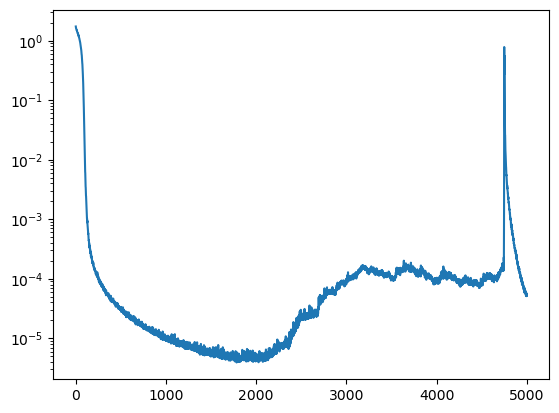

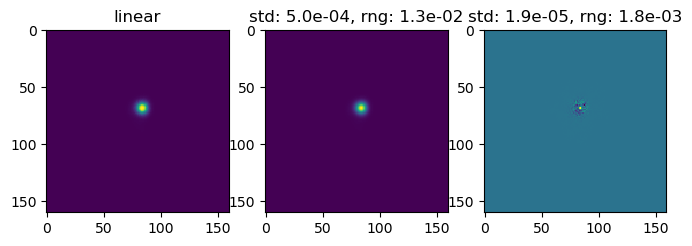

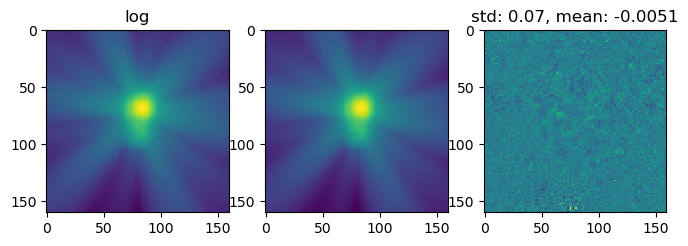

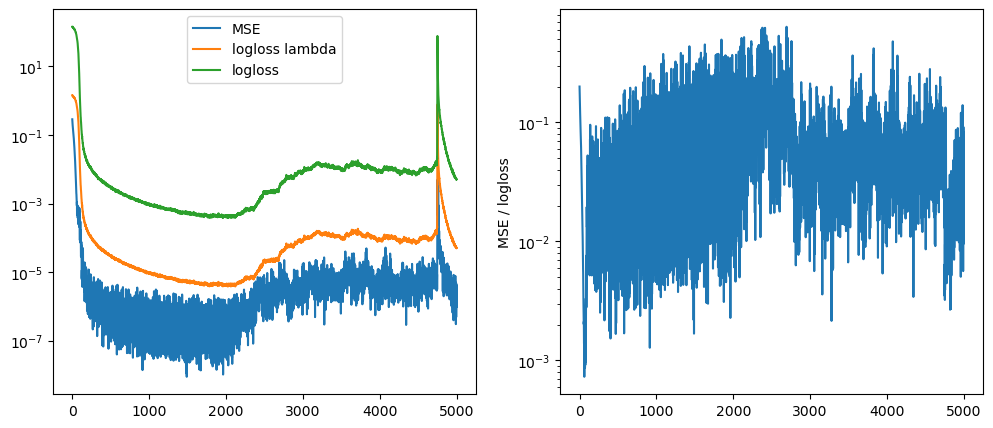

In [87]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, complex=False)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

In [88]:
vm = jax.jit(jax.vmap(model))
vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

%timeit vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

E0704 22:11:11.103107   20011 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[25600,256]{1,0} fusion(mul.11, constant.19), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0704 22:11:11.103257   20011 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0.1 = f32[25600,256]{1,0} parameter(0)
  parameter_1.1 = f32[256,256]{1,0} parameter(1)
  ROOT dot.5 = f32[25600,256]{1,0} dot(parameter_0.1, parameter_1.1), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}


299 μs ± 7.45 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


y1 shape: (160, 160, 256)


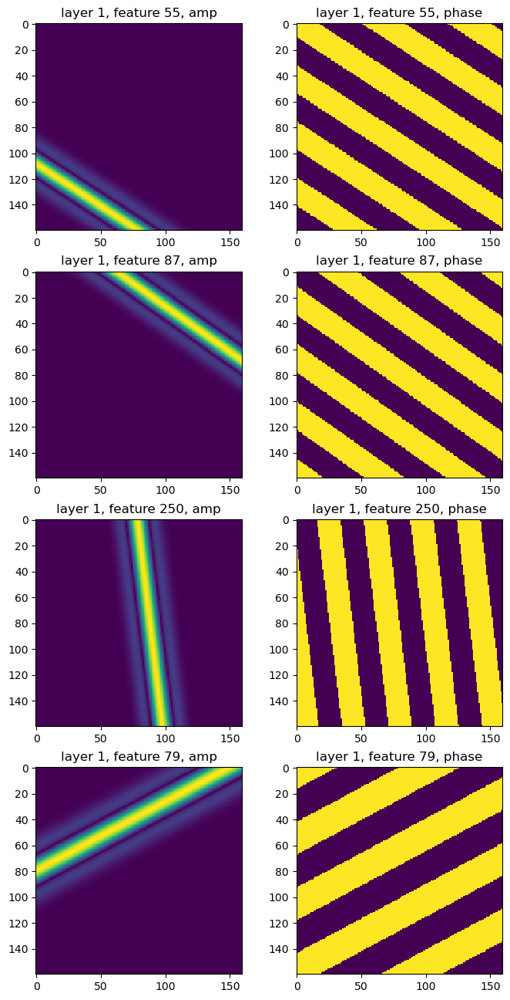

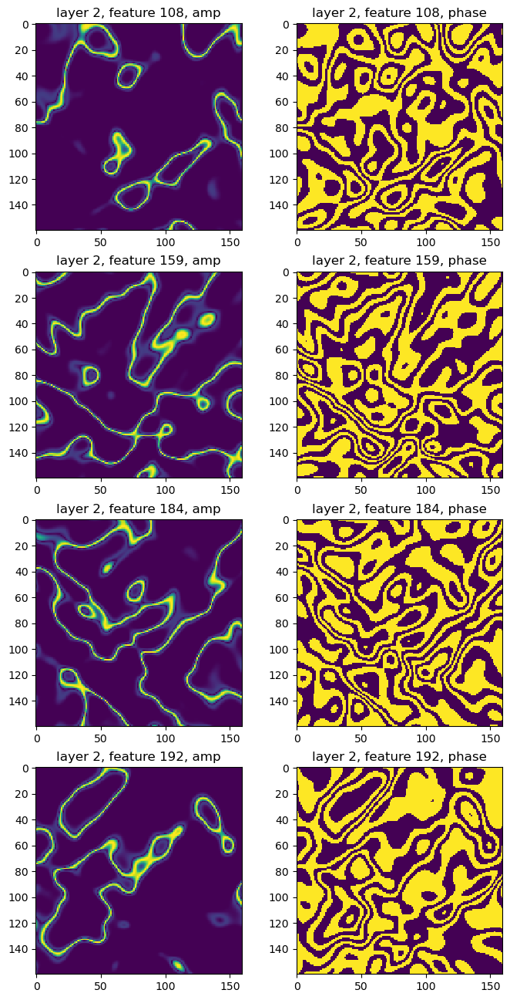

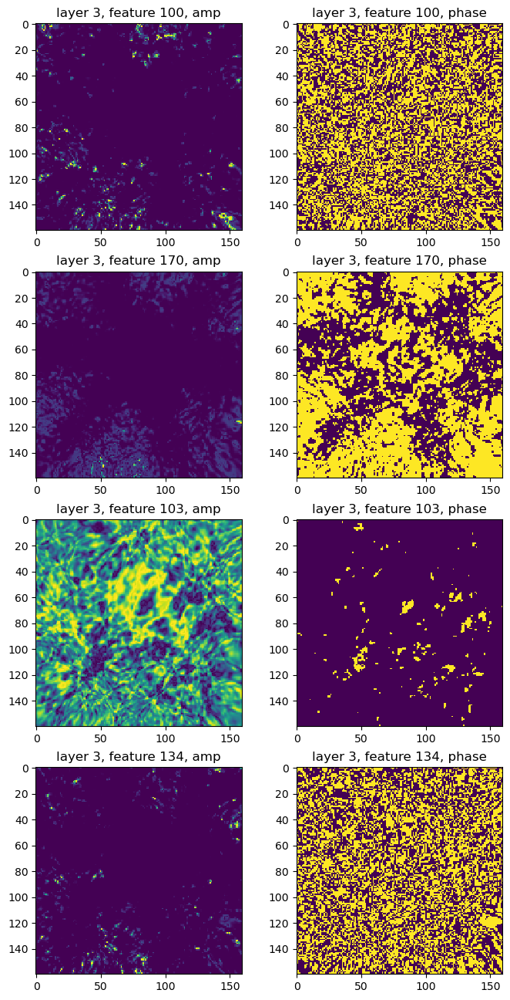

<Figure size 640x480 with 0 Axes>

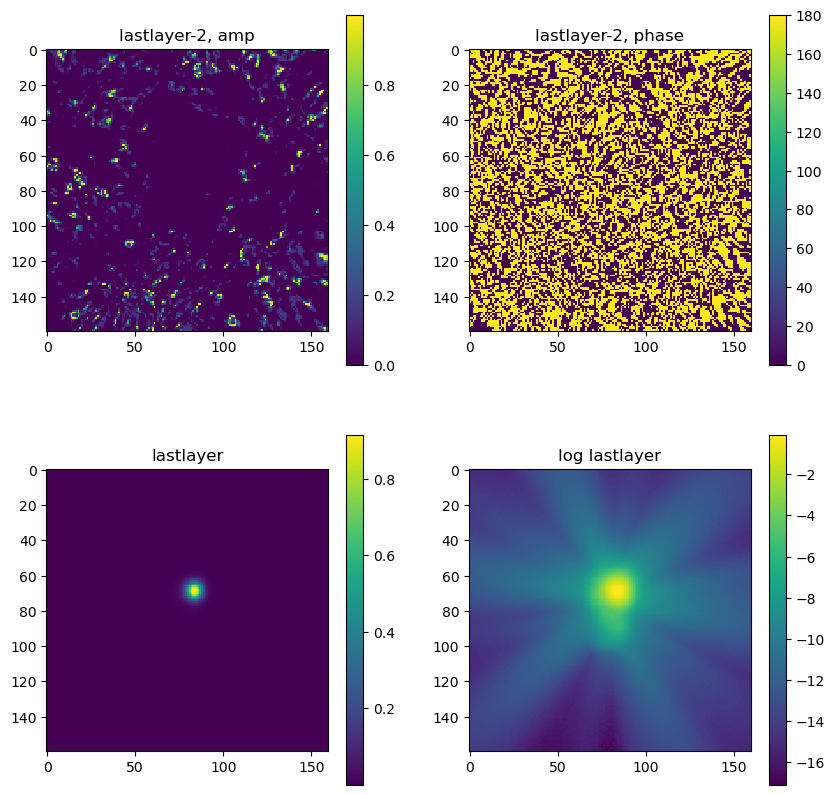

In [89]:
def viz_layers2r(model, xs, axlen=4, figsize=(8, 16)):
    nl = len(model.layers)
    def eval_layers(x, n):
        for i in range(n):
            x = model.layers[i](x)
        return x
    
    for n in range(1, nl-1):
        yl =  jax.vmap(partial(eval_layers, n=n))(xs).reshape(psfarrs.shape[1:] + (-1,))
        _, axs = plt.subplots(axlen, 2, figsize=figsize)
        idxs = np.random.choice(np.arange(yl.shape[-1]), size=axlen, replace=False)
        for axrow, idx in zip(axs, idxs):
            axrow[0].imshow(jnp.abs(yl[..., idx]), interpolation='nearest')
            axrow[0].set_title(f'layer {n}, feature {idx}, amp')
            axrow[1].imshow(jnp.angle(yl[..., idx]), interpolation='nearest')
            axrow[1].set_title(f'layer {n}, feature {idx}, phase')


    y1 = jax.vmap(partial(eval_layers, n=nl-2))(xs).reshape(psfarrs.shape[1:] + (-1,))
    print('y1 shape:', y1.shape)

    plt.figure()
    _, axs = plt.subplots(2, 2, figsize=(10, 10))
    axs = axs.ravel()

    cb = axs[0].imshow(jnp.abs(y1[..., 0]), interpolation='nearest')
    plt.colorbar(cb, ax=axs[0])
    axs[0].set_title('lastlayer-2, amp')
    cb = axs[1].imshow(jnp.angle(y1[..., 0])*180/np.pi, interpolation='nearest')
    plt.colorbar(cb, ax=axs[1])
    axs[1].set_title('lastlayer-2, phase')


    y2 = jax.vmap(partial(eval_layers, n=nl-1))(xs).reshape(psfarrs.shape[1:] + (-1,))
    y3 = jax.vmap(partial(eval_layers, n=nl))(xs).reshape(psfarrs.shape[1:] + (-1,))
    cb = axs[2].imshow(y3[..., 0], interpolation='nearest')
    plt.colorbar(cb, ax=axs[2])
    axs[2].set_title('lastlayer')
    cb = axs[3].imshow(jnp.log(y3[..., 0]), interpolation='nearest')
    plt.colorbar(cb, ax=axs[3])
    axs[3].set_title('log lastlayer')
             
viz_layers2r(model, xs)


## Explore loss functions

In [11]:
yp, yt = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))

def plot_loss(loss, name='', **kwargs):
    l = loss(yp.ravel(), yt.ravel()).reshape(yp.shape)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    cb = axs[0].pcolor(yp, yt, l, **kwargs)
    axs[0].set_title(name + ' loss')
    plt.colorbar(cb, ax=axs[0])
    
    cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
    axs[1].set_title('log ' + name + ' loss')
    plt.colorbar(cb, ax=axs[1])

    for ax in axs:
        ax.set_xlabel('predicted')
        ax.set_ylabel('true')

    return fig

ypl, ytl = np.meshgrid(np.logspace(-8, 0, 100), np.logspace(-8, 0, 100))

def plot_loss_log(loss, name='', **kwargs):
    l = loss(ypl.ravel(), ytl.ravel()).reshape(ypl.shape)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    for ax in axs:
        ax.set_xlabel('predicted')
        ax.set_ylabel('true')
        ax.loglog()
        
    cb = axs[0].pcolor(ypl, ytl, l, **kwargs)
    axs[0].set_title(name + ' loss')
    plt.colorbar(cb, ax=axs[0])
    
    cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)
    axs[1].set_title('log ' + name + ' loss')
    plt.colorbar(cb, ax=axs[1])

    return fig


def plot_losses(loss, name):
    fig1 = plot_loss(loss, name)
    fig2 = plot_loss_log(loss, name)
    return fig1, fig2

/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

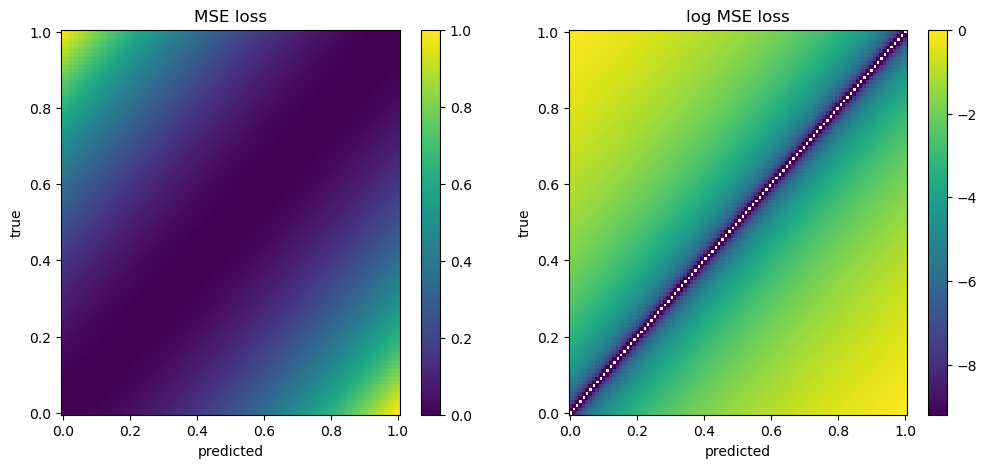

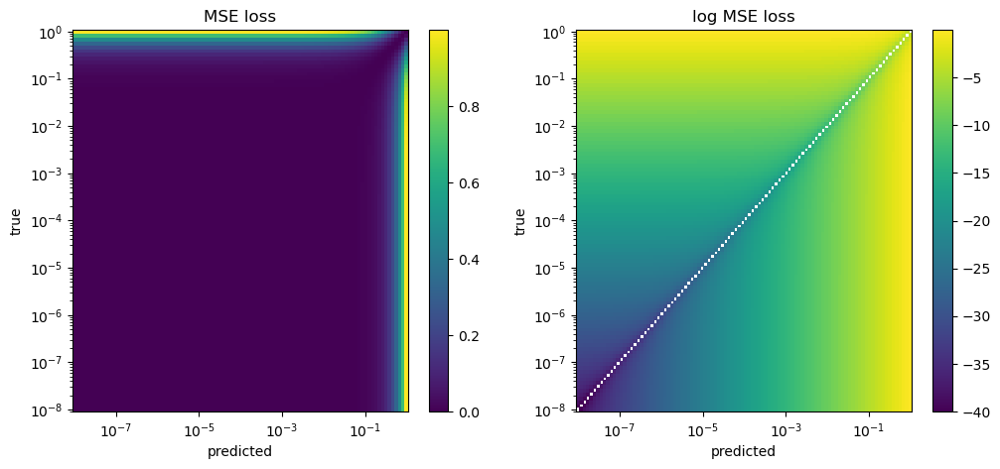

In [12]:
plot_losses(lambda yp,yt: (yp-yt)**2, name='MSE')

/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

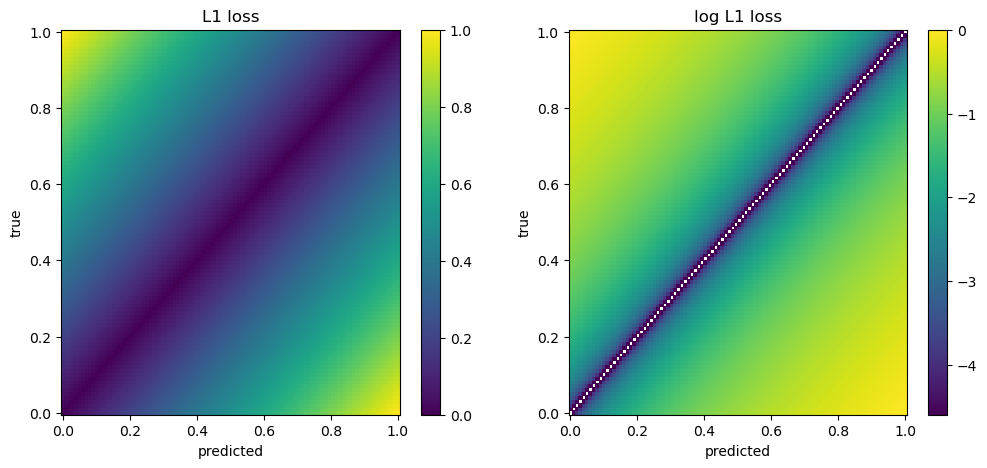

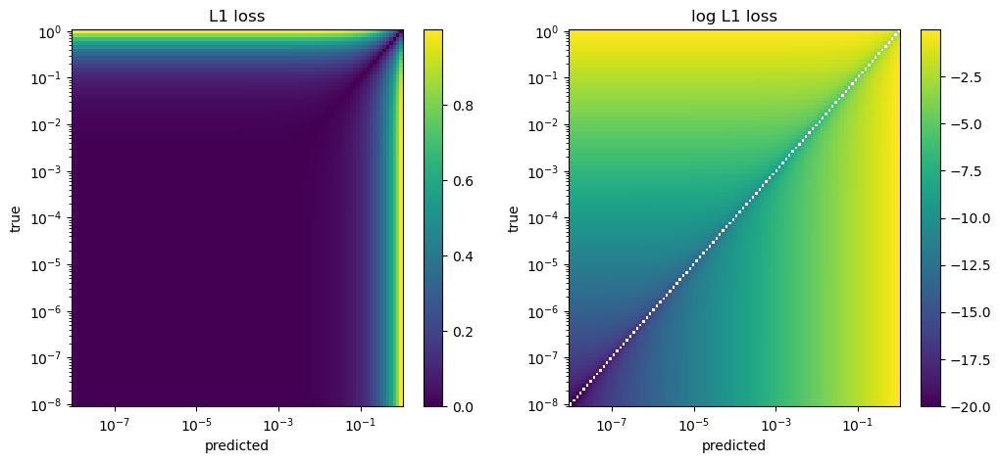

In [13]:
plot_losses(lambda yp,yt: np.abs(yp-yt), name='L1')

/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

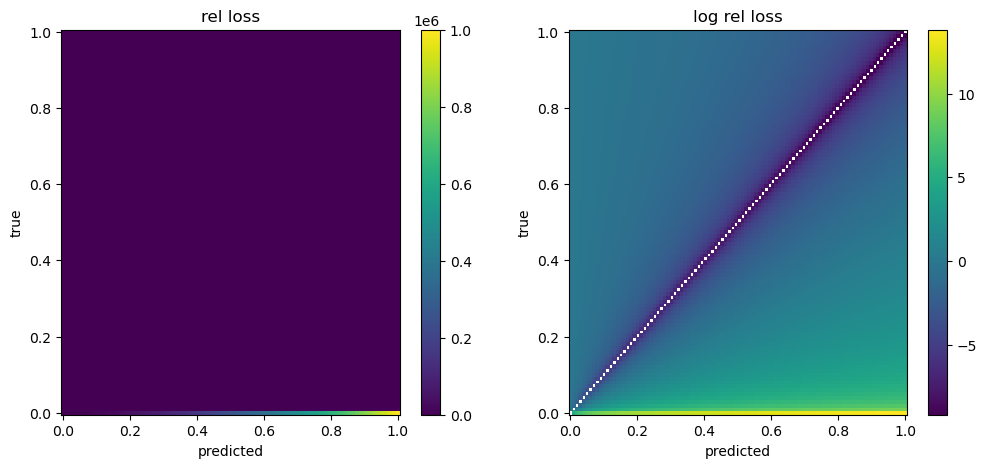

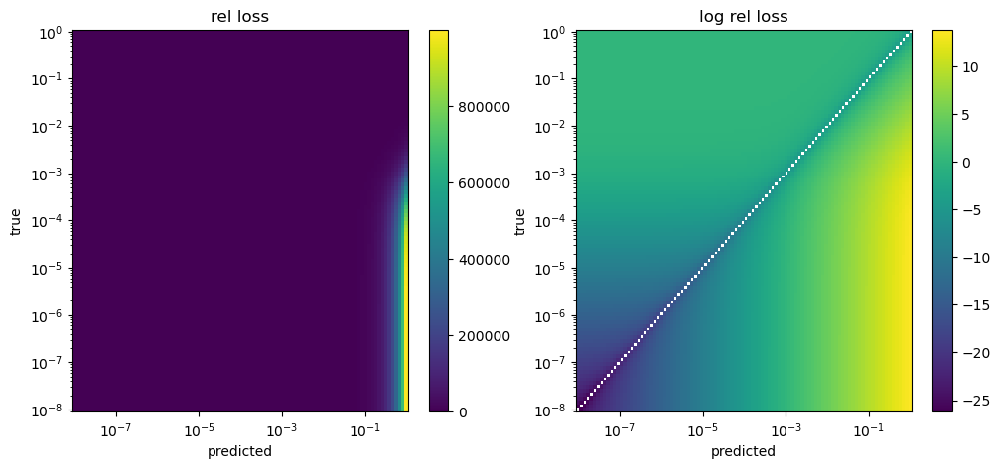

In [14]:
eps = 1e-3
plot_losses(lambda yp,yt: ((yp - yt)/(yt + eps))**2, name='rel')

/tmp/ipykernel_7260/4275746120.py:1: RuntimeWarning: divide by zero encountered in log
  plot_losses(lambda yp,yt: (np.log(yp)-np.log(yt))**2, name='MLSE')
/tmp/ipykernel_7260/4275746120.py:1: RuntimeWarning: invalid value encountered in subtract
  plot_losses(lambda yp,yt: (np.log(yp)-np.log(yt))**2, name='MLSE')
/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

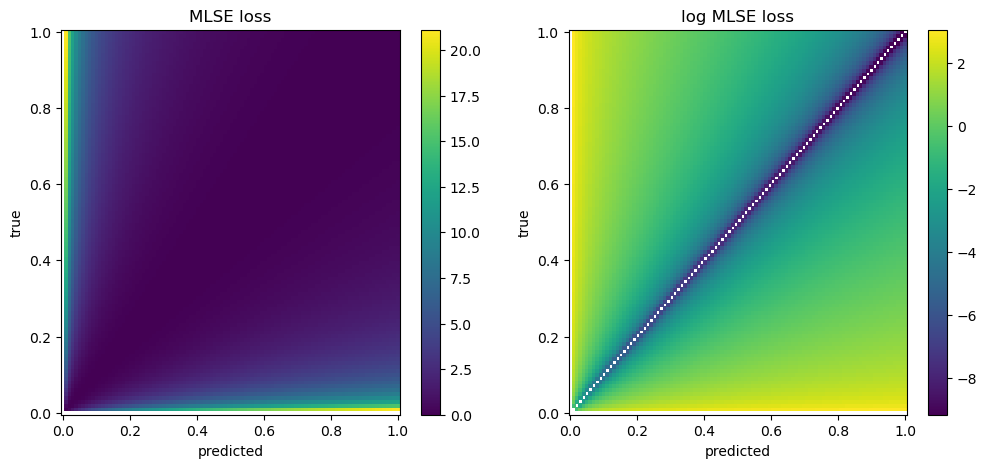

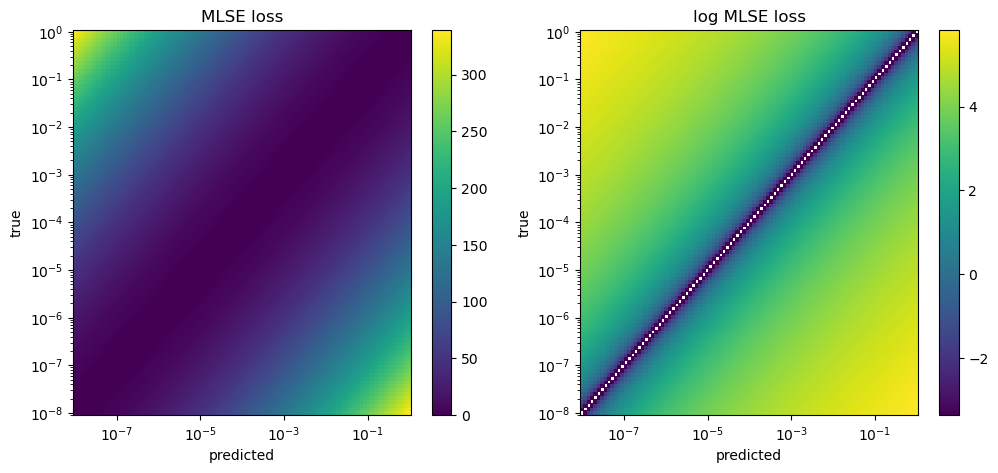

In [15]:
plot_losses(lambda yp,yt: (np.log(yp)-np.log(yt))**2, name='MLSE')

/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

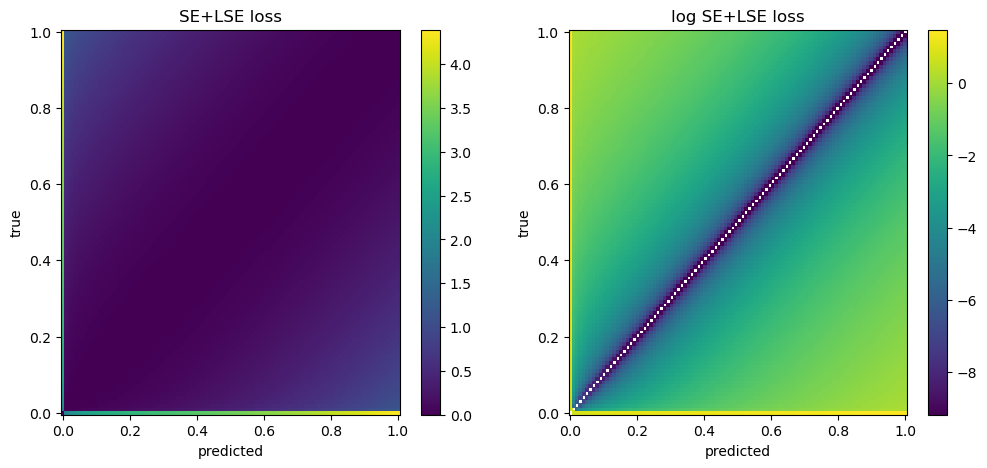

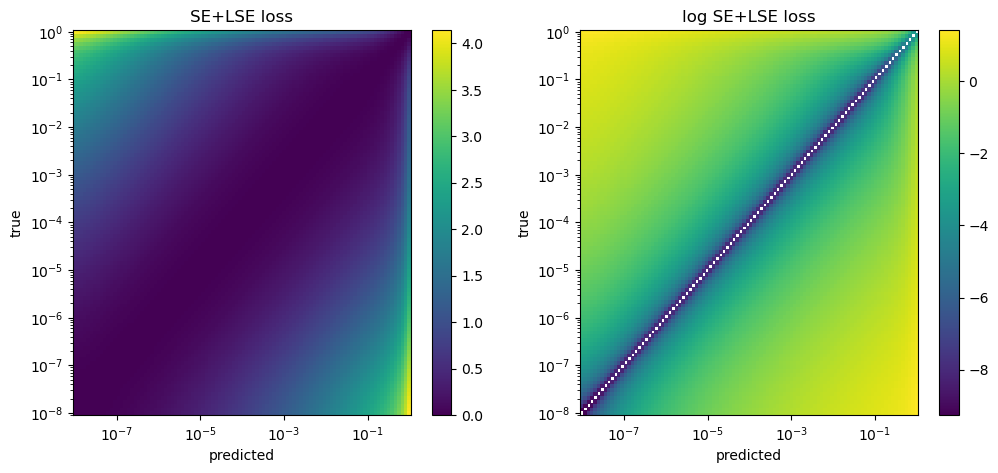

In [16]:
def mse_plus_log_loss(y_pred, y, logfrac=1e-2, eps=1e-8):
    mse = (y_pred - y)**2
    log_loss = (jnp.log(y_pred+eps) - jnp.log(y+eps))**2
    return mse + logfrac*log_loss

plot_losses(mse_plus_log_loss, name='SE+LSE')

/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

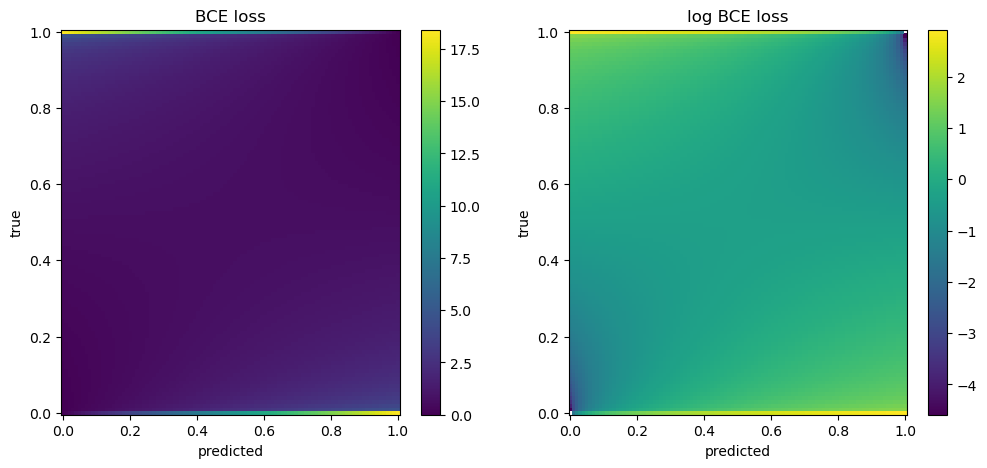

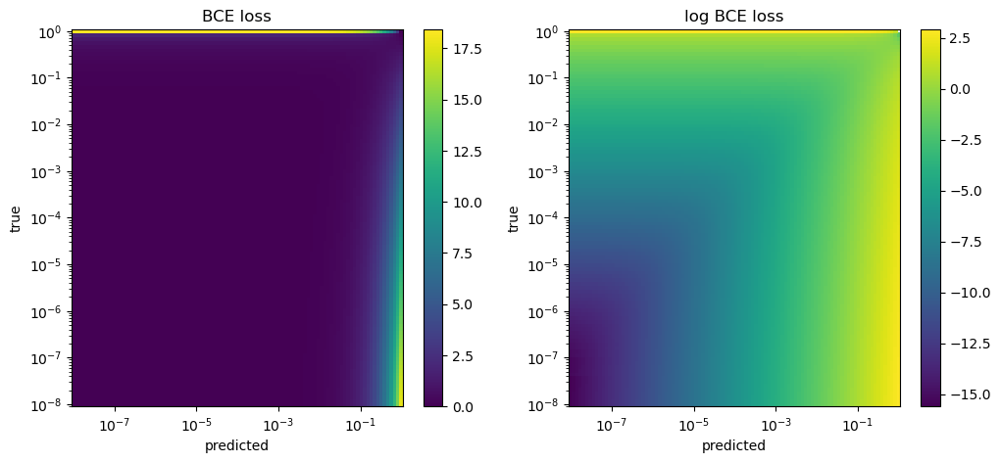

In [17]:
def bce_loss(yp, yt, weight=1., eps=1e-8):
    t1 = yp * jnp.log(yt + eps) 
    t2 = (1-yp) * jnp.log(1-yt + eps)
    return -weight * (t1 + t2)

plot_losses(bce_loss, name='BCE')

/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

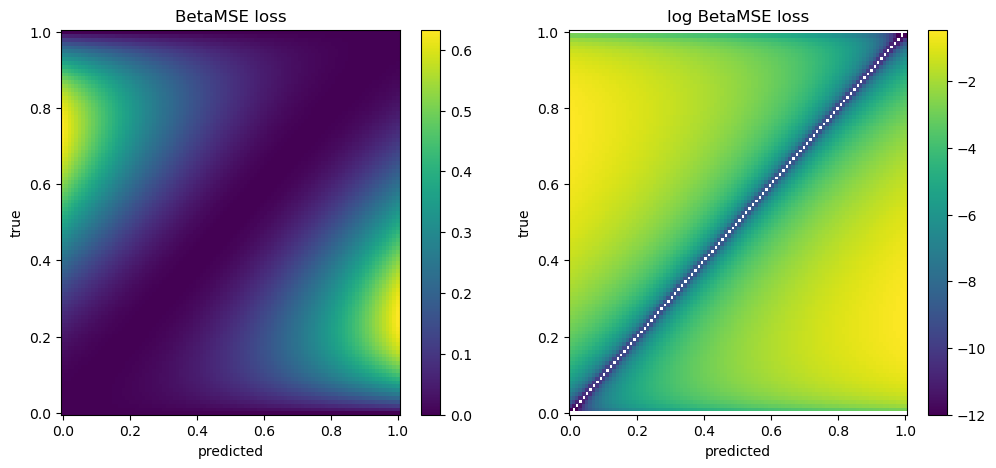

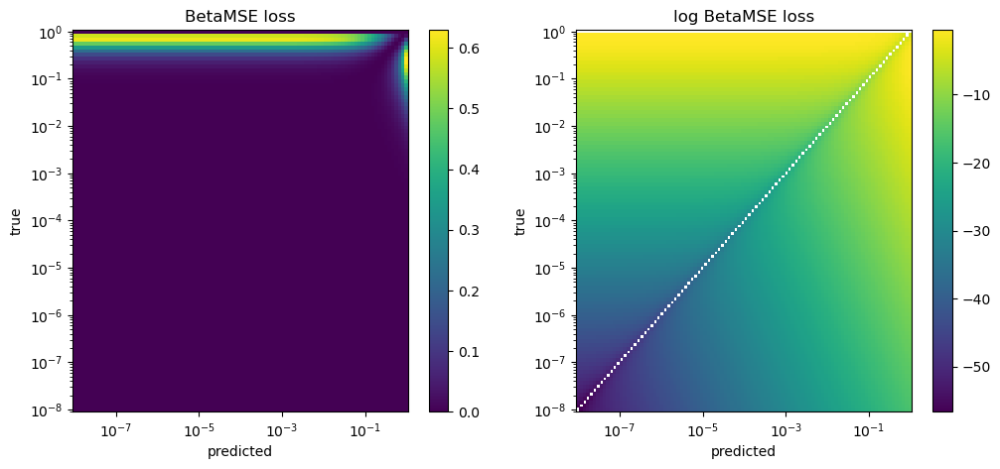

In [18]:
def betamse_loss(yp, yt, a=2, b=2,):
    B = jax.scipy.special.beta(a, b)
    mse = (yp - yt)**2
    x = yt
    betapdf = (x**(a-1) * (1-x)**(b-1)) / B
    return mse*betapdf

plot_losses(betamse_loss, name='BetaMSE')

Hmm... Need to understand what the goal is here:

### Visualize a training run in loss space

In [49]:
predstosave = jnp.sort(jnp.array(list(set(list(range(0, EPOCHS, 100)) + [EPOCHS-1] + list(range(100))))))
jnp.where(predstosave == 4)[0][0]

Array(4, dtype=int32)

  0%|          | 0/5000 [00:00<?, ?it/s]

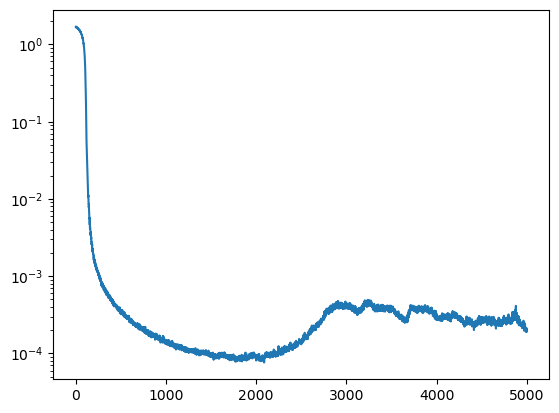

In [52]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))

predstosave = jnp.sort(jnp.array(list(set(list(range(0, EPOCHS, 100)) + [EPOCHS-1] + list(range(100))))))
preds = []
@eqx.filter_jit
def eval_model(model):
    return jax.vmap(model)(xs)
    
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    if i in predstosave:
        preds.append(eval_model(model))

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})
preds = jnp.array(preds)

plt.semilogy(losses)

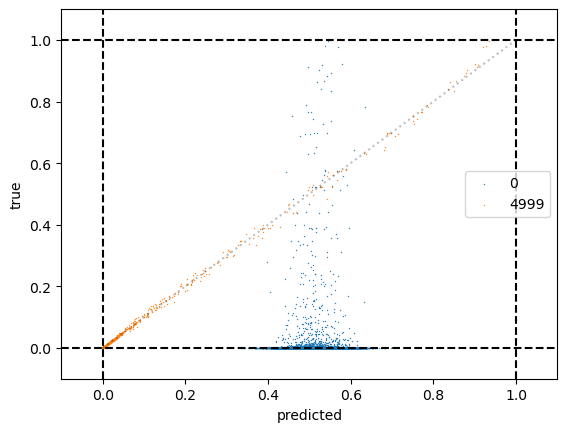

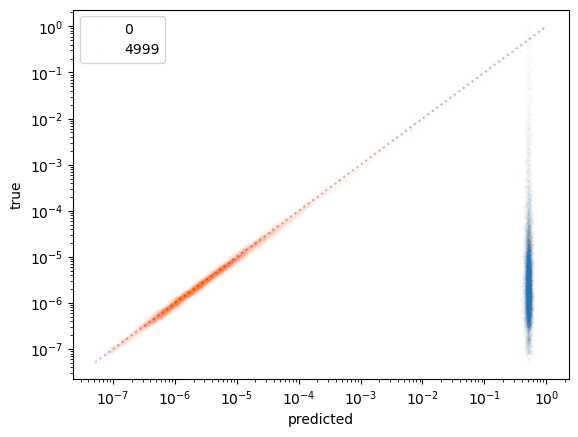

In [128]:
def plot_preds(predidx, al=1):
    for i in predidx:
        plt.scatter(preds[i], ys, s=1, label=f'{predstosave[i]}', alpha=al, lw=0)
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    plt.axhline(0, color='k', ls='--')
    plt.axhline(1, color='k', ls='--')
    plt.axvline(0, color='k', ls='--')
    plt.axvline(1, color='k', ls='--')
    plt.ylabel('true')
    plt.xlabel('predicted')
    plt.legend()
    plt.plot([0, 1], [0, 1], color='k', ls=':', alpha=.25)

def plot_preds_log(predidx, al=1):
    plt.loglog()
    for i in predidx:
        plt.scatter(preds[i], ys, s=1, label=f'{predstosave[i]}', alpha=al, lw=0)
    
    plt.plot([ys.min(), 1], [ys.min(), 1], color='k', ls=':', alpha=.25)
    plt.ylabel('true')
    plt.xlabel('predicted')
    plt.legend()

plot_preds([0, -1], .9)
plt.figure()
plot_preds_log([0, -1], .02)

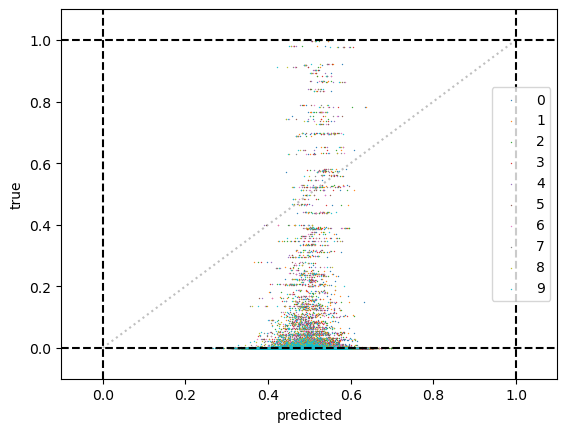

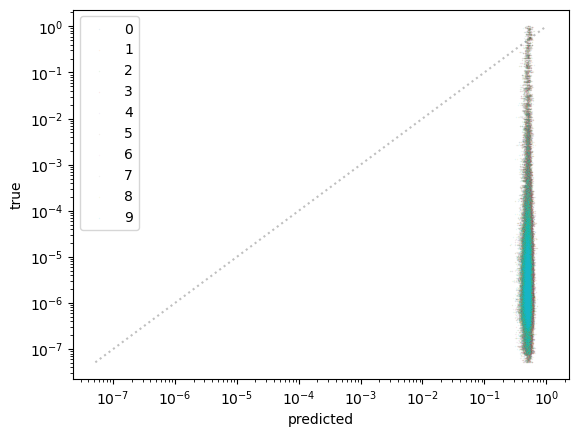

In [129]:
plot_preds(range(10), .9)
plt.figure()
plot_preds_log(range(10), .1)

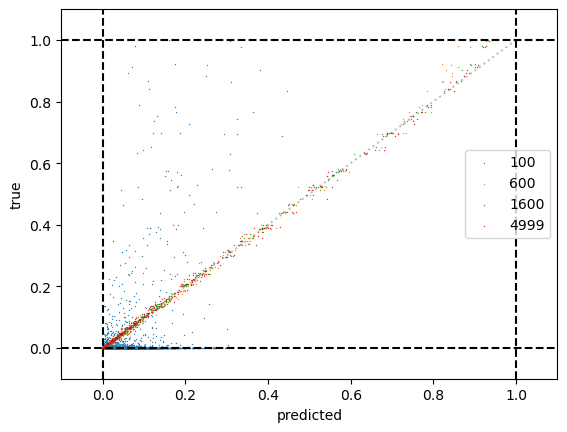

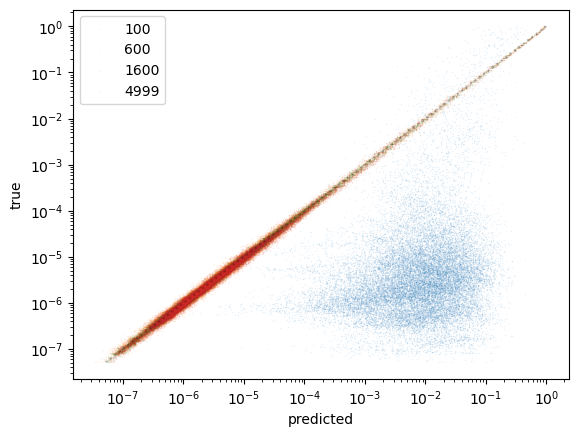

In [130]:
pis = [100, 105, 115, 150]
plot_preds(pis, .9)
plt.figure()
plot_preds_log(pis, .1)

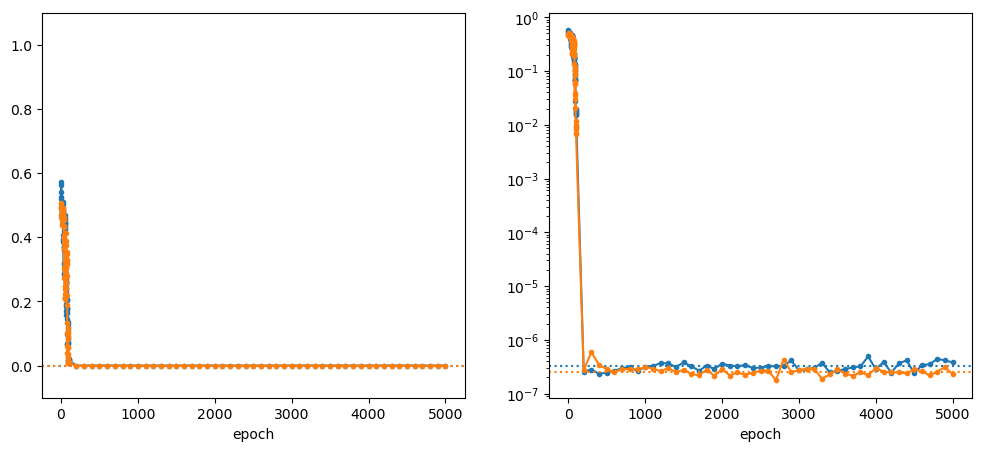

In [156]:
def plot_pred_track(ixds=None, orderidx=None, xlims=None):
    if ixds is None:
        ays = jnp.argsort(ys)
        ixds = [ays[o] for o in orderidx]
    elif orderidx is not None:
        raise ValueError('Cannot specify both ixds and orderidx')

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    for ax in axs:
        for i, pxidx in enumerate(ixds):
            trueval = ys[pxidx]
            predvals = preds[:, pxidx]
            ax.plot(predstosave, predvals, '-o', ms=3, color=f'C{i}', label='predicted')
            ax.axhline(trueval, color=f'C{i}', ls=':', label='true')
        ax.set_xlabel('epoch')
        if xlims is not None:
            ax.set_xlim(*xlims)
    axs[0].set_ylim(-0.1, 1.1)
    axs[1].semilogy()
    
plot_pred_track([0, -1])

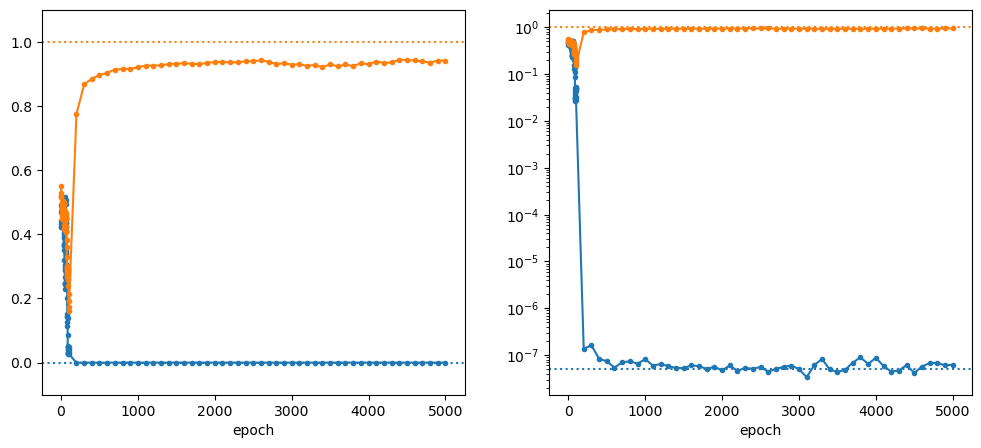

In [135]:
plot_pred_track(orderidx=[0, -1])

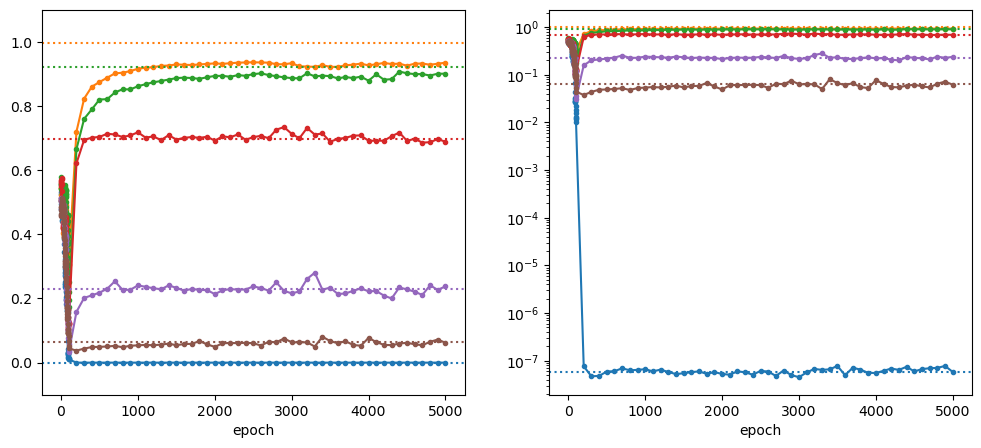

<Figure size 640x480 with 0 Axes>

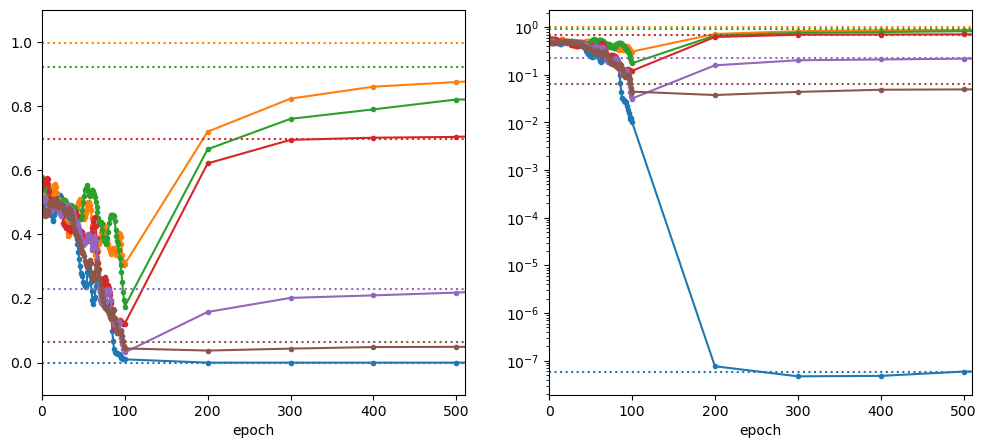

In [180]:
plot_pred_track(orderidx=[10,  -2, -5, -25, -100, -200])
plt.figure()
plot_pred_track(orderidx=[10,  -2, -5, -25, -100, -200], xlims=(0, 510))

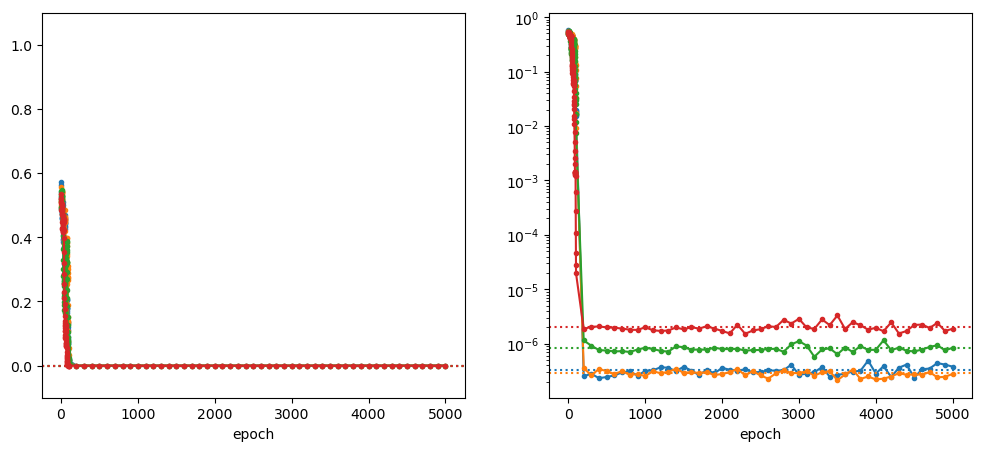

<Figure size 640x480 with 0 Axes>

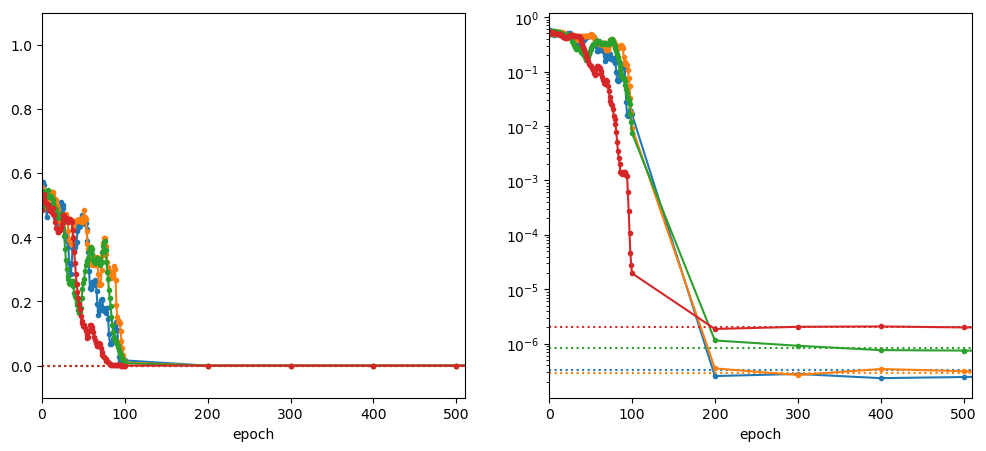

In [181]:
plot_pred_track([0, 20, 120, 1000])
plt.figure()
firplot_pred_track([0, 20, 120, 1000], xlims=(0, 510))

It's really hard to see from this why the loss gets worse from epoch ~2000 on.  Maybe it's the high ones?  Or more noise in the low ones?  Lets try to build a loss function that weights the high ones and the typical in the log space about the same.

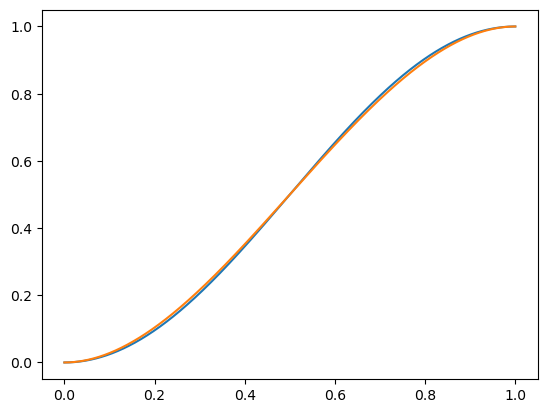

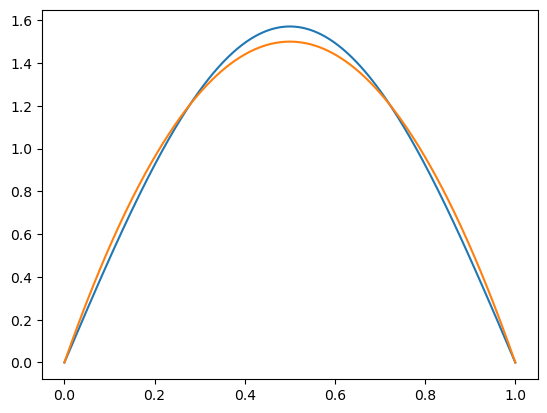

In [120]:
x = np.linspace(0,1, 1024)
def f(x):
    return (1-np.cos(x*np.pi))/2

def fp(x):
    return np.sin(x*np.pi)*np.pi/2


def fpoly(x):
    return x**2*(3 - 2*x)
def fpolyp(x):
    return 6*x - 6*x**2

plt.figure()
plt.plot(x, f(x))
plt.plot(x, fpoly(x))
plt.figure()
plt.plot(x, fp(x))
plt.plot(x, fpolyp(x));

# Designed Loss

So design a loss function with the property that it's got roughly equal loss (~1) shoulders in the O(1) regime and the maximum logarithmic regime. The "maximum logarithmic" needs to be a parameter that could either be explicitly the dynamic range (i.e. the minimum above 0).  Might be nice to also have a tunable parameter to set whether the linear or logarithmic regime is stronger.

## MSES CosW

/tmp/ipykernel_19274/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_19274/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

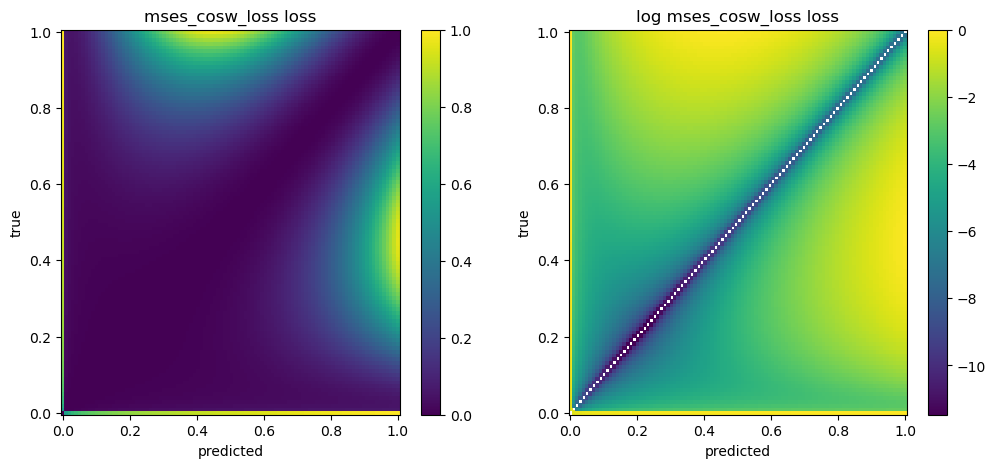

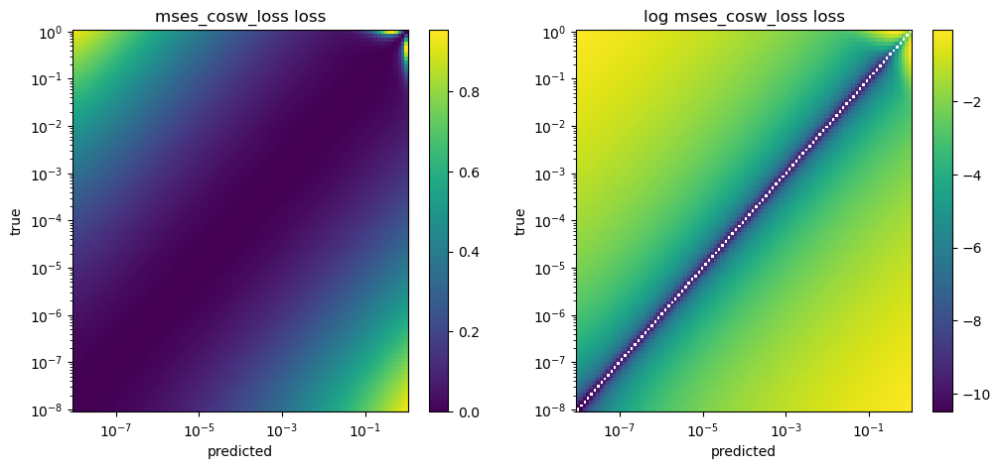

In [221]:
def mses_cosw_loss(yp, yt, eps=1e-8, logweighting=1):
    epsscale = jnp.log(eps)**-2
    yw = (yt*yp)
    w = (1-jnp.cos(yw*jnp.pi))/2
    w2 = 1-w
    mse = 7.5*(yp - yt)**2  # this 7.5 just makes the O(1) region max out around 1. Probably derivable somehow, but eh.
    lmse = epsscale*(jnp.log(yp+eps) - jnp.log(yt+eps))**2
    return mse*w/logweighting + lmse*w2*logweighting

plot_losses(mses_cosw_loss, name='mses_cosw_loss')

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 0.00043617224 relative to image: 0.86698264


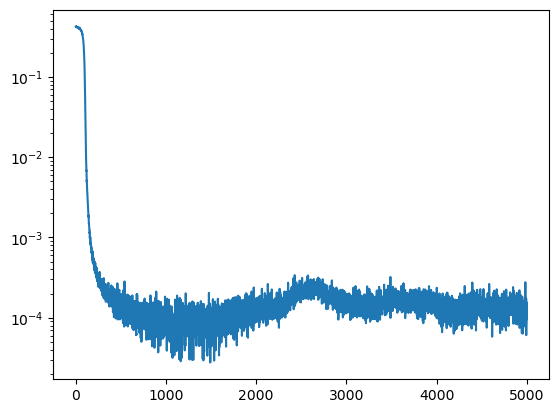

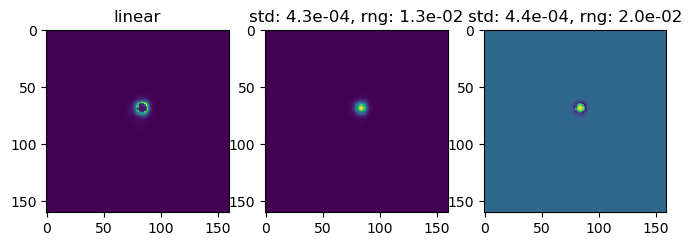

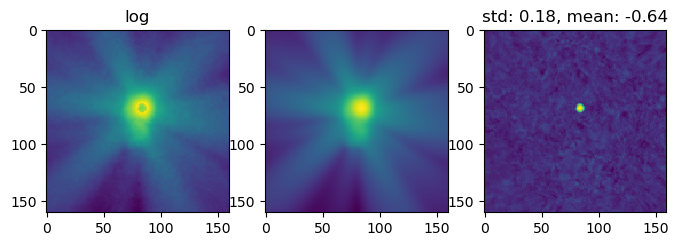

In [222]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

def mloss(model, x, y):
    y_pred = jax.vmap(model)(x)
    losses = mses_cosw_loss(y_pred, y, eps=1e-8, logweighting=1)
    return jnp.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mloss)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

/tmp/ipykernel_19274/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_19274/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


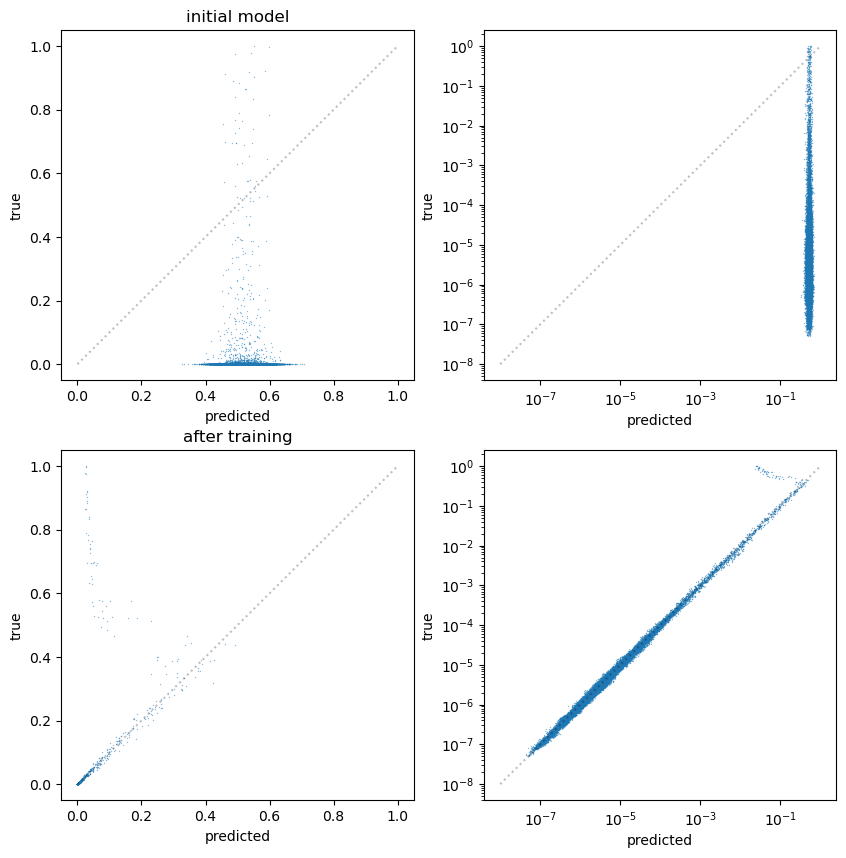

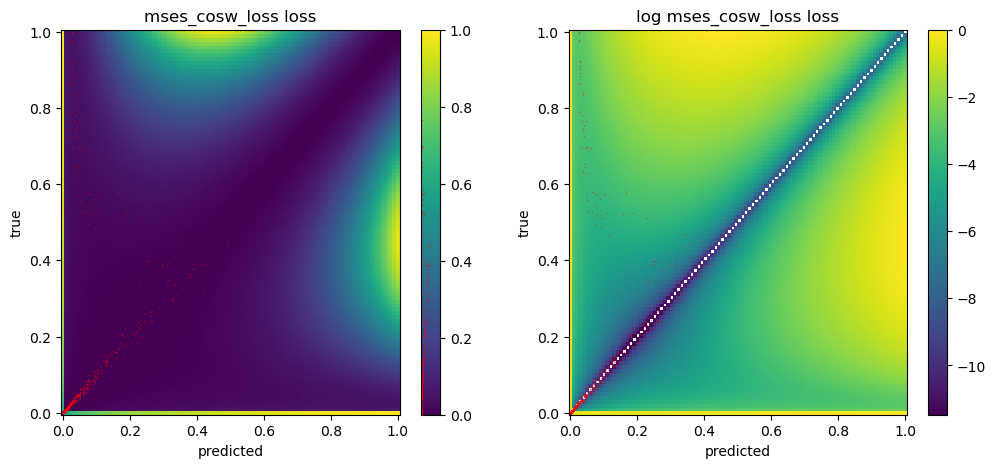

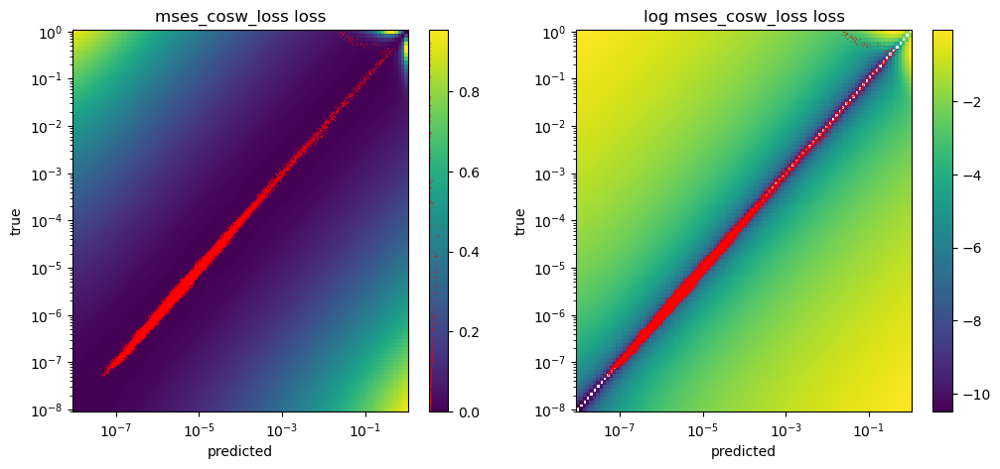

In [225]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(mses_cosw_loss, name='mses_cosw_loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

Whoops ok don't engineer a false minimum...

## Reshaped MLSE

/tmp/ipykernel_8892/806300850.py:4: RuntimeWarning: divide by zero encountered in divide
  return jnp.log((yp/yt + yt/yp)/2)/-jnp.log(yt*yp)
/tmp/ipykernel_8892/806300850.py:4: RuntimeWarning: invalid value encountered in divide
  return jnp.log((yp/yt + yt/yp)/2)/-jnp.log(yt*yp)
/tmp/ipykernel_8892/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_8892/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

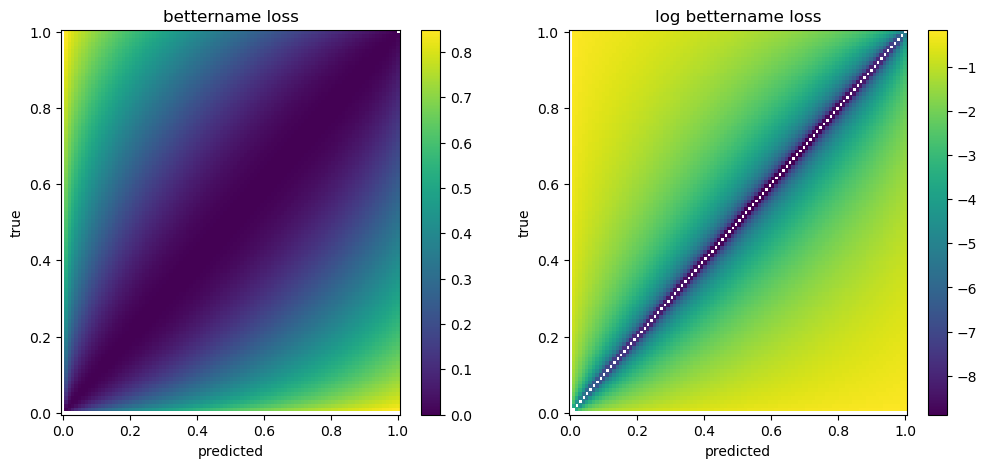

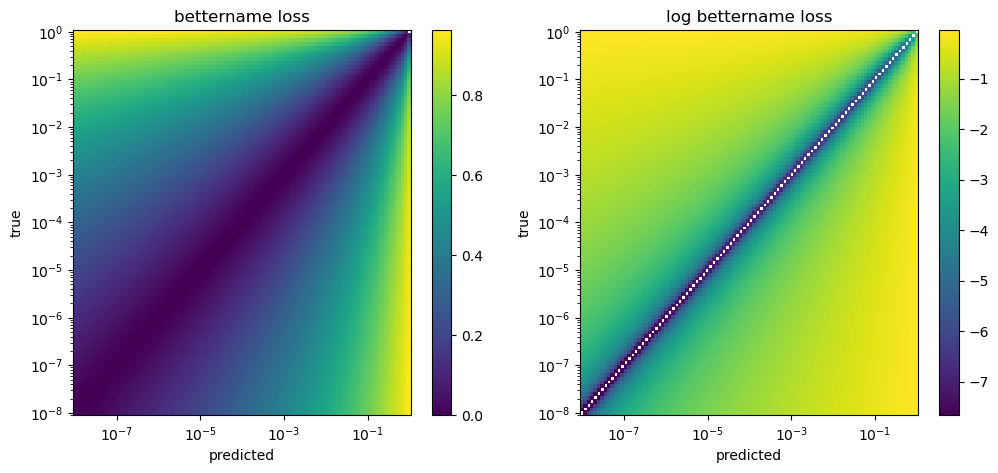

In [ ]:
def shaped_log_loss(yp, yt, eps=1e-2):
    yw = (yt*yp)
    w = (1-eps)*(1-jnp.cos(yw*jnp.pi))/2 + eps
    return jnp.log((yp/yt + yt/yp)/2)/-jnp.log(yt*yp)

plot_losses(shaped_log_loss, name='shaped_log')

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 1.7006481e-05 relative to image: 0.033803903


/tmp/ipykernel_8892/806300850.py:4: RuntimeWarning: divide by zero encountered in divide
  return jnp.log((yp/yt + yt/yp)/2)/-jnp.log(yt*yp)
/tmp/ipykernel_8892/806300850.py:4: RuntimeWarning: invalid value encountered in divide
  return jnp.log((yp/yt + yt/yp)/2)/-jnp.log(yt*yp)
/tmp/ipykernel_8892/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_8892/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


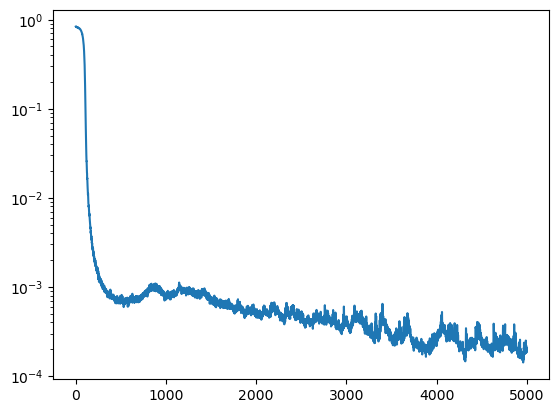

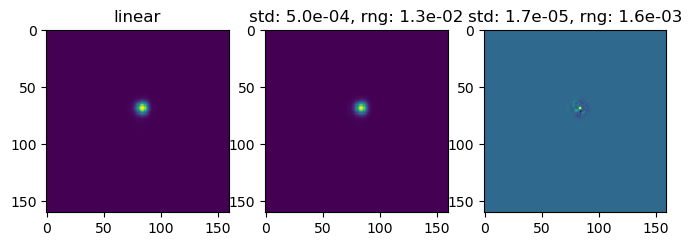

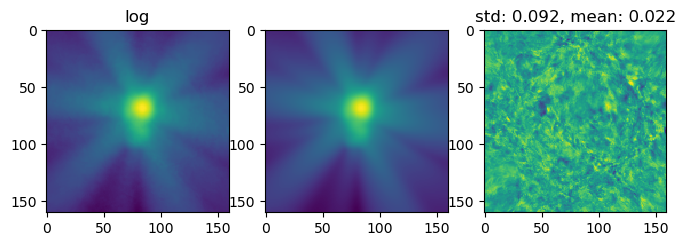

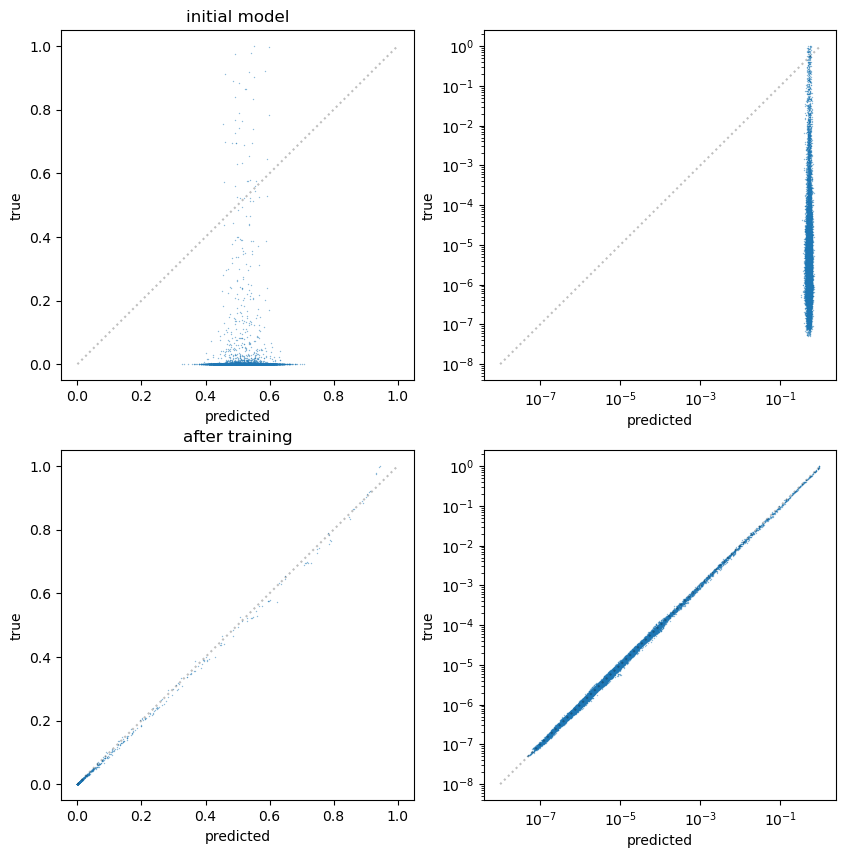

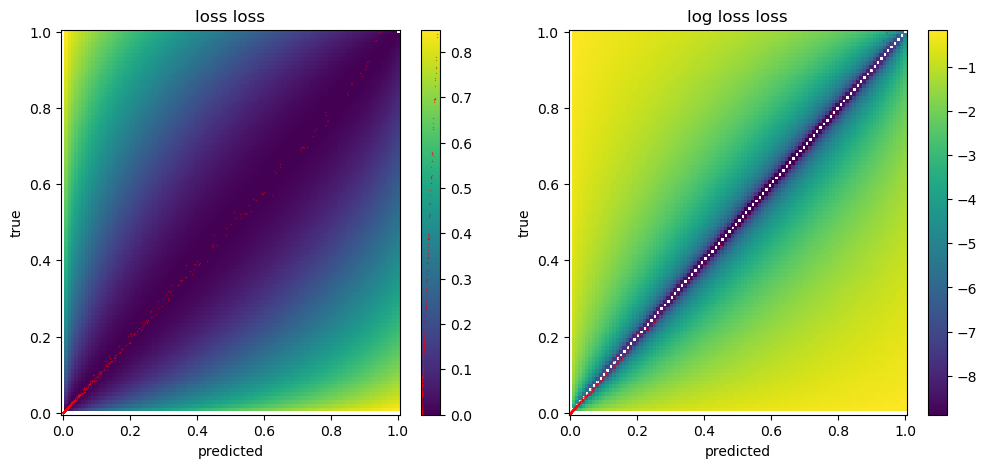

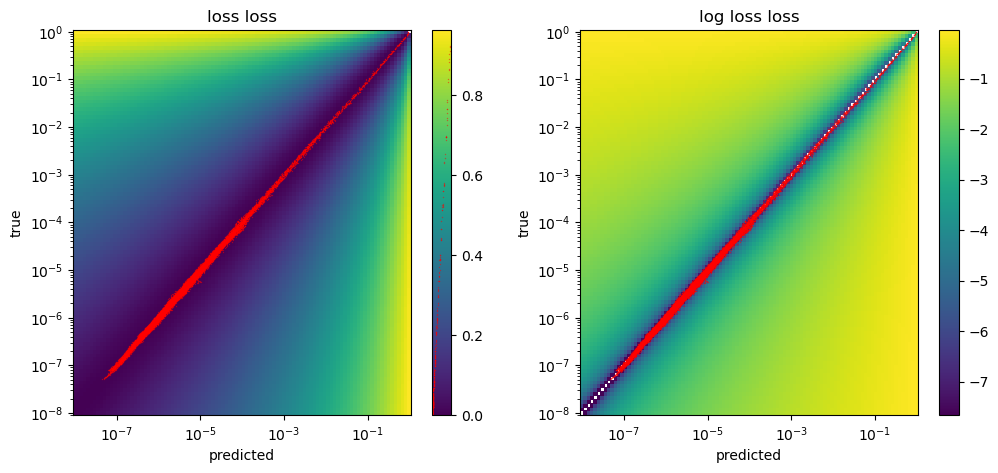

In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = shaped_log_loss

def mloss(model, x, y):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y)
    return jnp.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mloss)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

## Reweighted log

/tmp/ipykernel_7355/3095536735.py:12: RuntimeWarning: divide by zero encountered in divide
  return (1/w)*jnp.log((yp/yt + yt/yp)/2)
/tmp/ipykernel_7355/3095536735.py:12: RuntimeWarning: invalid value encountered in divide
  return (1/w)*jnp.log((yp/yt + yt/yp)/2)
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

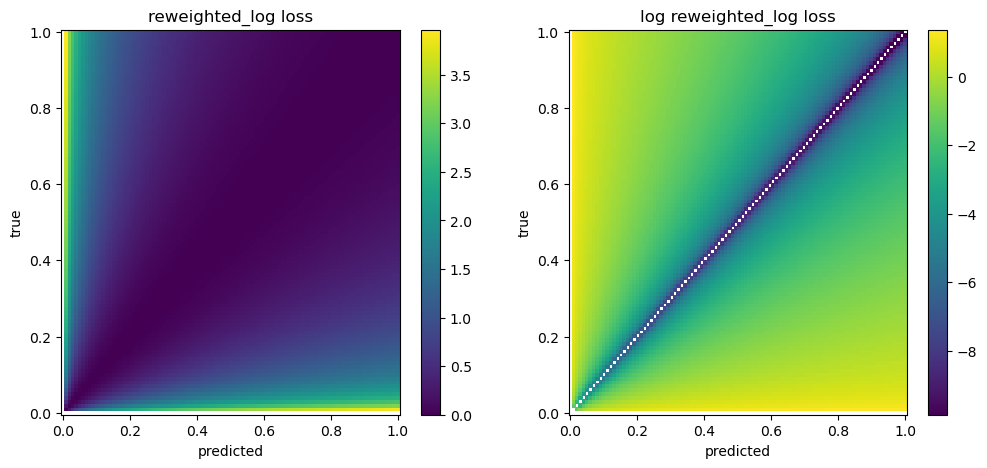

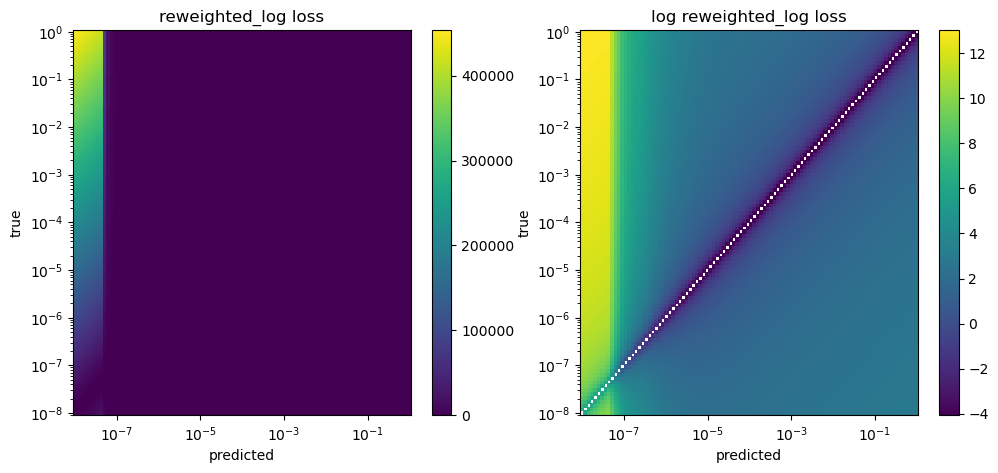

In [78]:
ysrank = jnp.argsort(ys)
ysp = (ysrank+1)/ys.size

def ytprob(yt):
    rank = jnp.searchsorted(ys[ysrank], yt)
    p = (rank+1)/ys.size
    return p

def reweighted_log_loss(yp, yt, eps=1e-4):
    py = yp
    w = ytprob(py)
    return (1/w)*jnp.log((yp/yt + yt/yp)/2)

plot_losses(reweighted_log_loss, name='reweighted_log')

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 4.8334008e-05 relative to image: 0.09607385


/tmp/ipykernel_8892/2039871058.py:12: RuntimeWarning: divide by zero encountered in divide
  return (1/w)*jnp.log((yp/yt + yt/yp)/2)
/tmp/ipykernel_8892/2039871058.py:12: RuntimeWarning: invalid value encountered in divide
  return (1/w)*jnp.log((yp/yt + yt/yp)/2)
/tmp/ipykernel_8892/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_8892/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


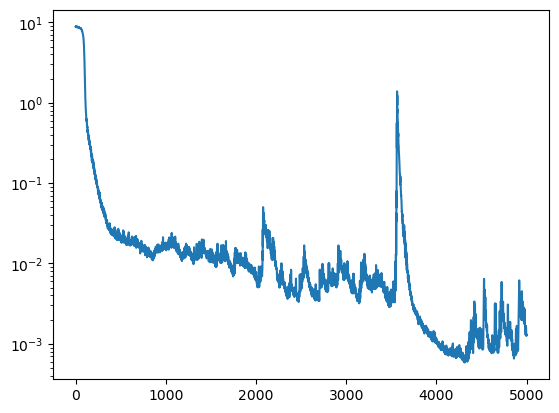

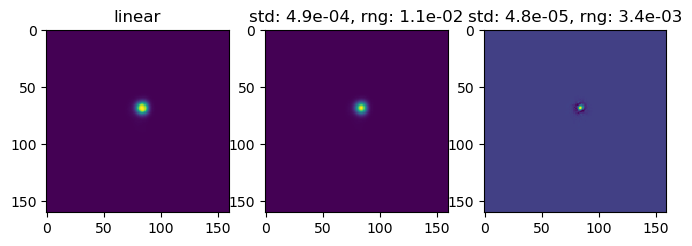

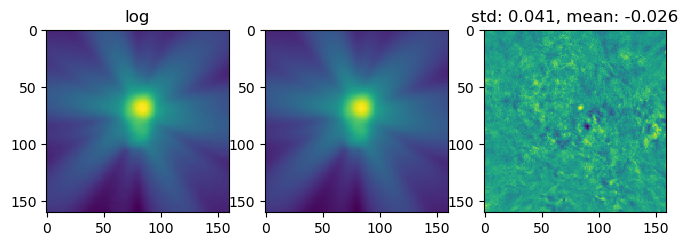

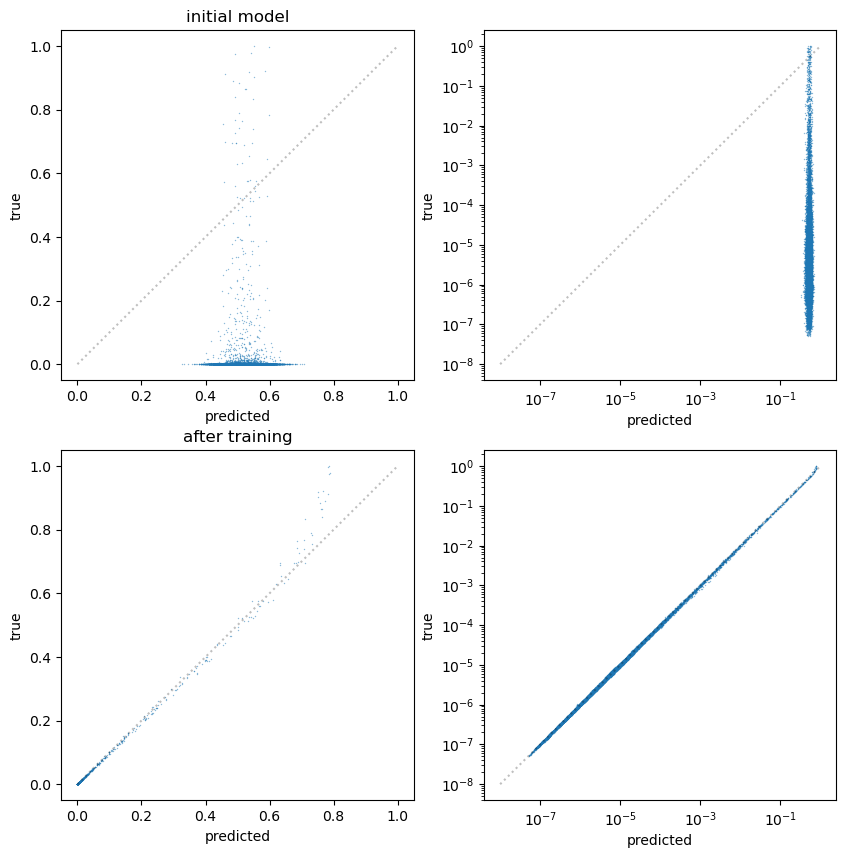

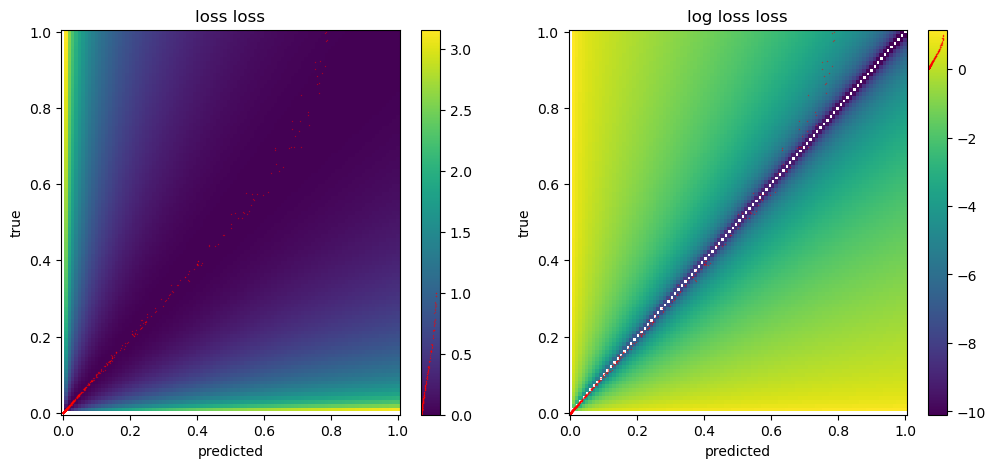

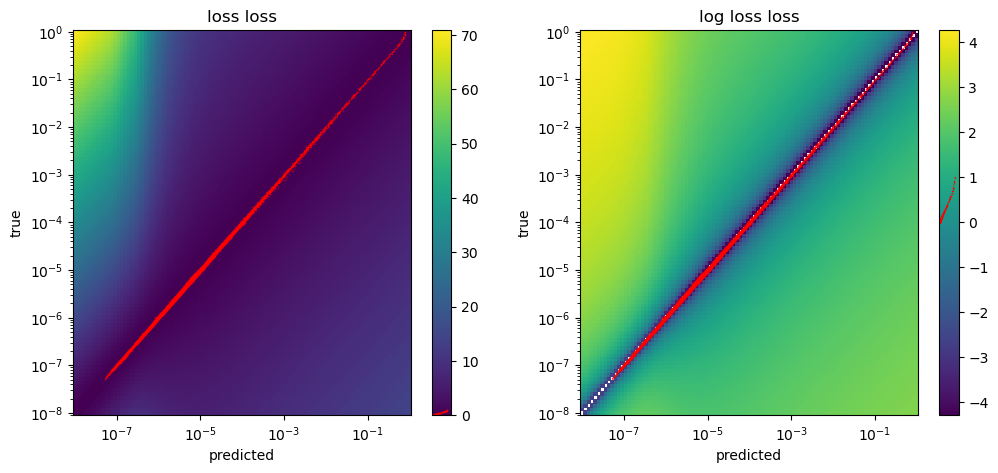

In [135]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = reweighted_log_loss

def mloss(model, x, y):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y)
    return jnp.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mloss)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

## asymmetric log

/tmp/ipykernel_7355/1855665574.py:5: RuntimeWarning: divide by zero encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/1855665574.py:5: RuntimeWarning: invalid value encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

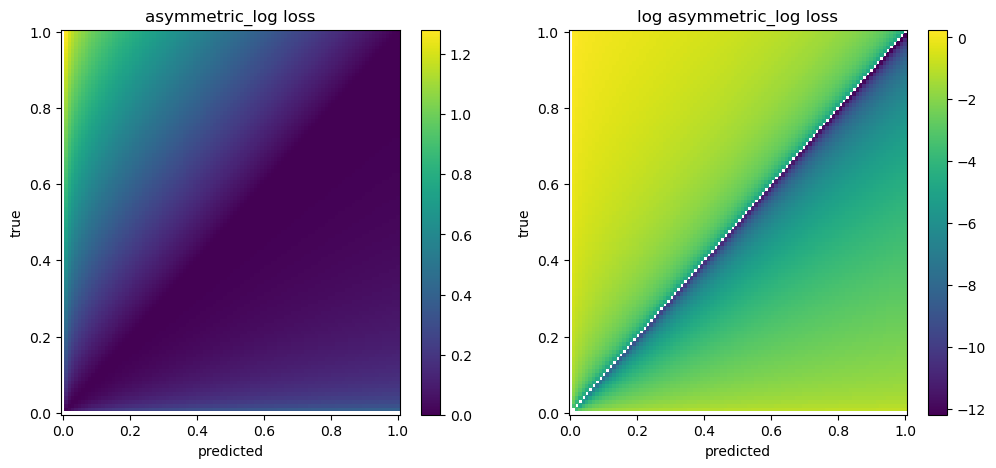

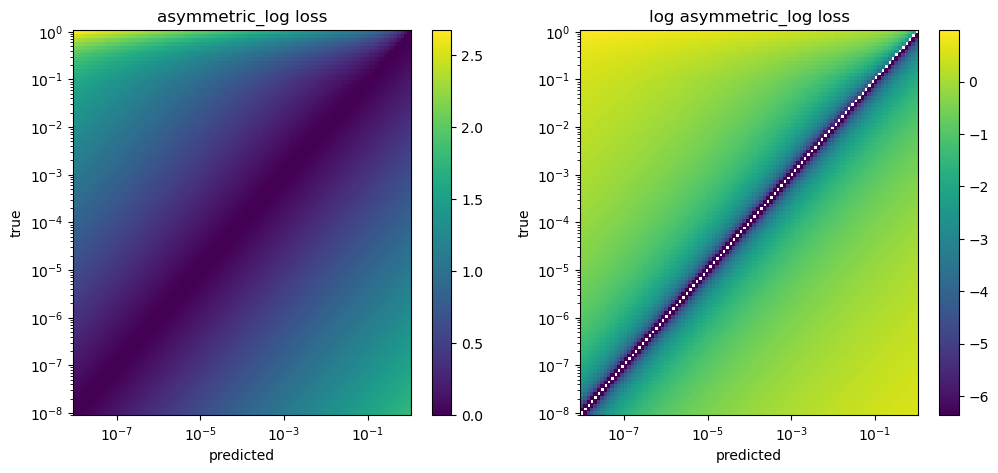

In [349]:
def asymmetric_log_loss(yp, yt, eps=1e-1):
    wr = jax.nn.relu(yt-yp)
    #dedge =  (2**0.5*jnp.min(jnp.array((1-yt, yp)), axis=0))*(jnp.sign(yt-yp)+1)/2
    mse = (yt - yp)**2
    x = (yp/yt + yt/yp)/2
    w = 1-.1
    return jnp.log(x)*(1-w) + wr*w

plot_losses(asymmetric_log_loss, name='asymmetric_log')

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 2.145951e-05 relative to image: 0.04265522 relmax: 0.08660466


/tmp/ipykernel_7355/1855665574.py:5: RuntimeWarning: divide by zero encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/1855665574.py:5: RuntimeWarning: invalid value encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


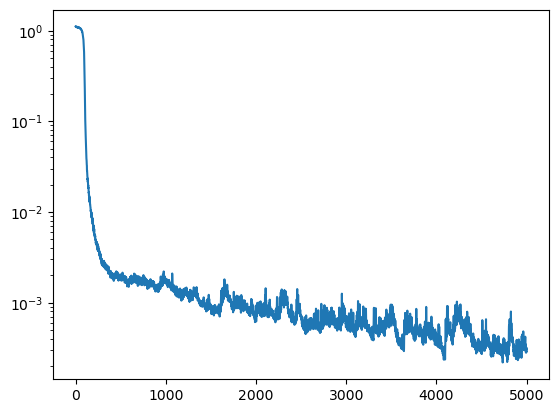

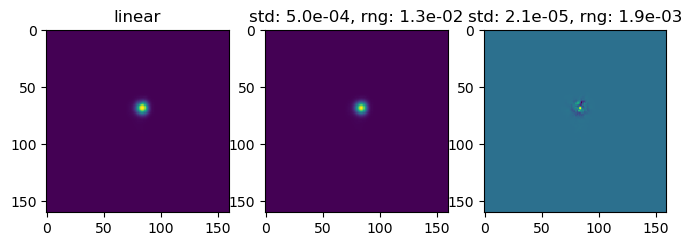

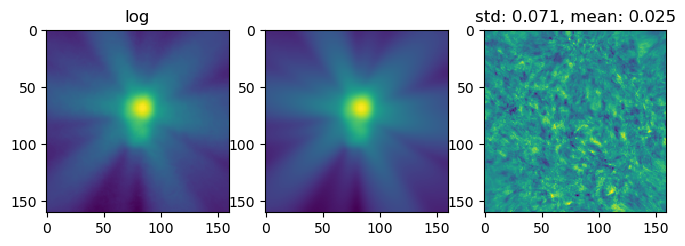

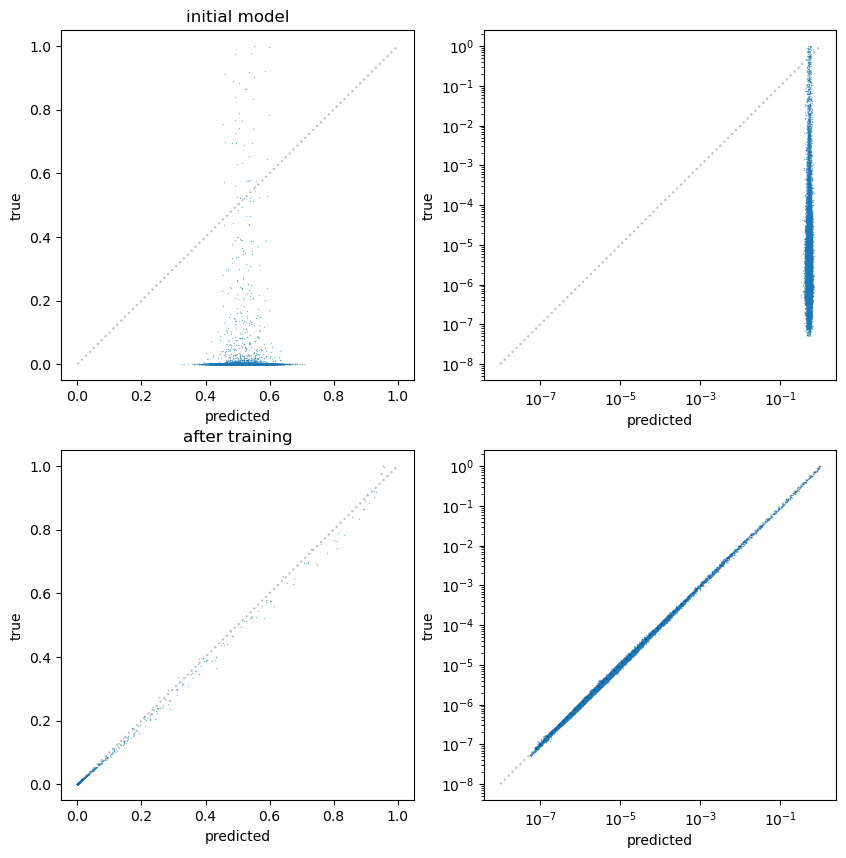

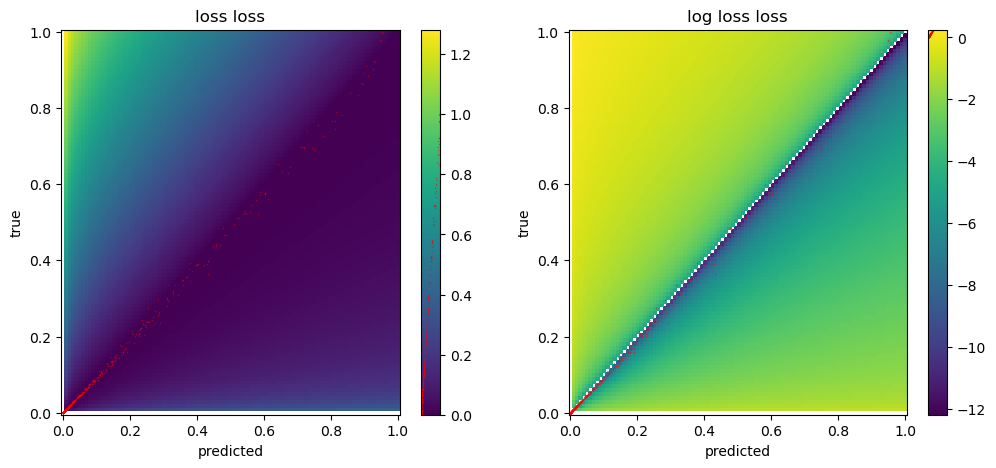

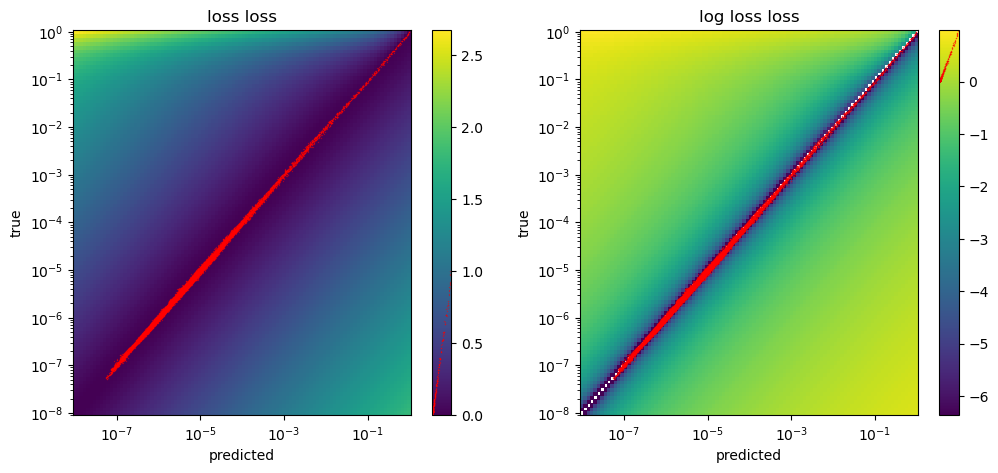

In [350]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = asymmetric_log_loss

def mloss(model, x, y):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y)
    return jnp.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mloss)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

Maybe it's not the loss function per se then, but the weigting?

## Weighted by pixel value

/tmp/ipykernel_7355/3365995524.py:2: RuntimeWarning: divide by zero encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/3365995524.py:2: RuntimeWarning: invalid value encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

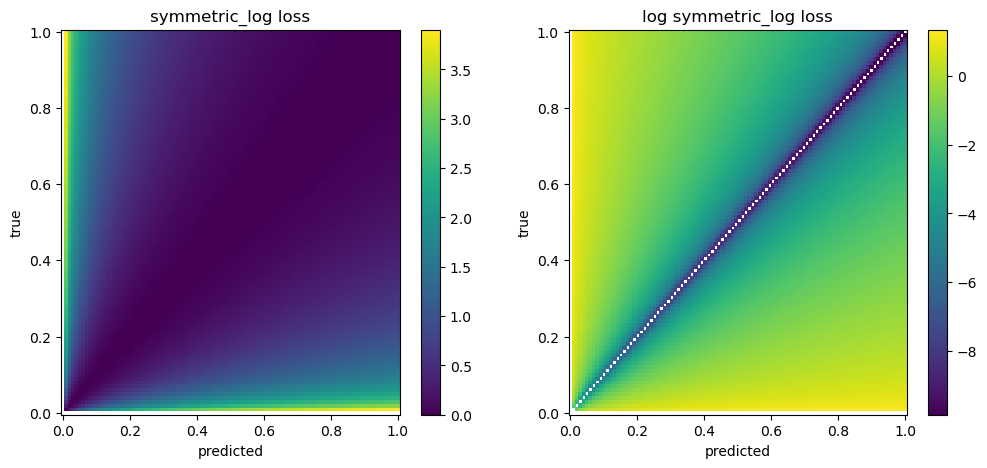

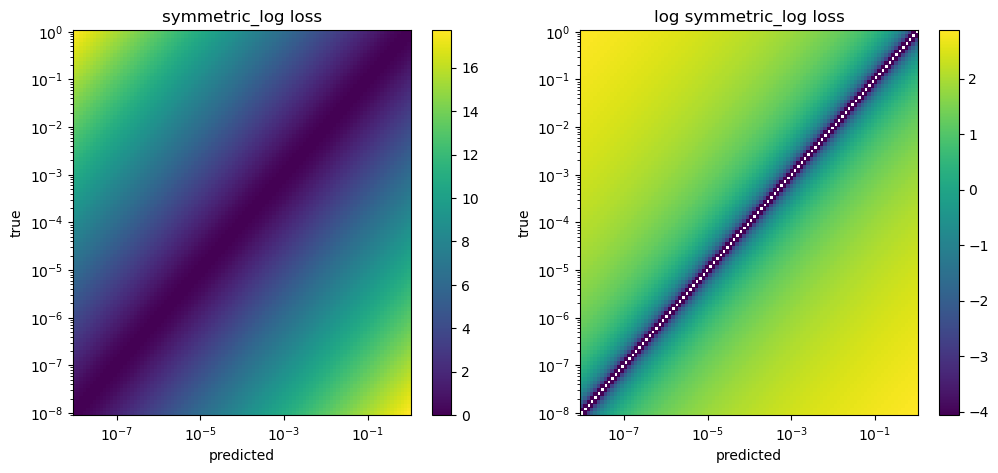

In [358]:
def symmetric_log_loss(yp, yt):
    x = (yp/yt + yt/yp)/2
    return jnp.log(x)

plot_losses(symmetric_log_loss, name='symmetric_log')

  0%|          | 0/25000 [00:00<?, ?it/s]

resid std: 4.3520427e-06 relative to image: 0.008650586 relmax: 0.0265279


/tmp/ipykernel_7355/3365995524.py:2: RuntimeWarning: divide by zero encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/3365995524.py:2: RuntimeWarning: invalid value encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


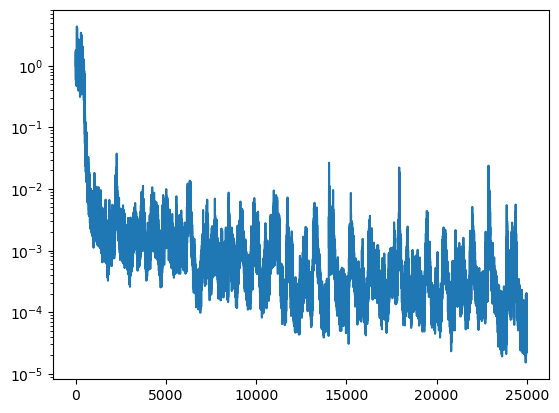

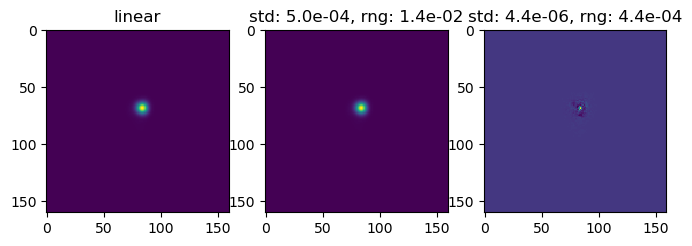

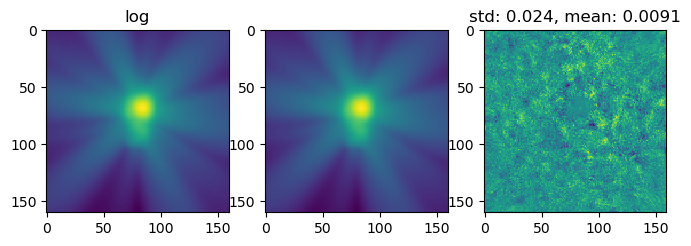

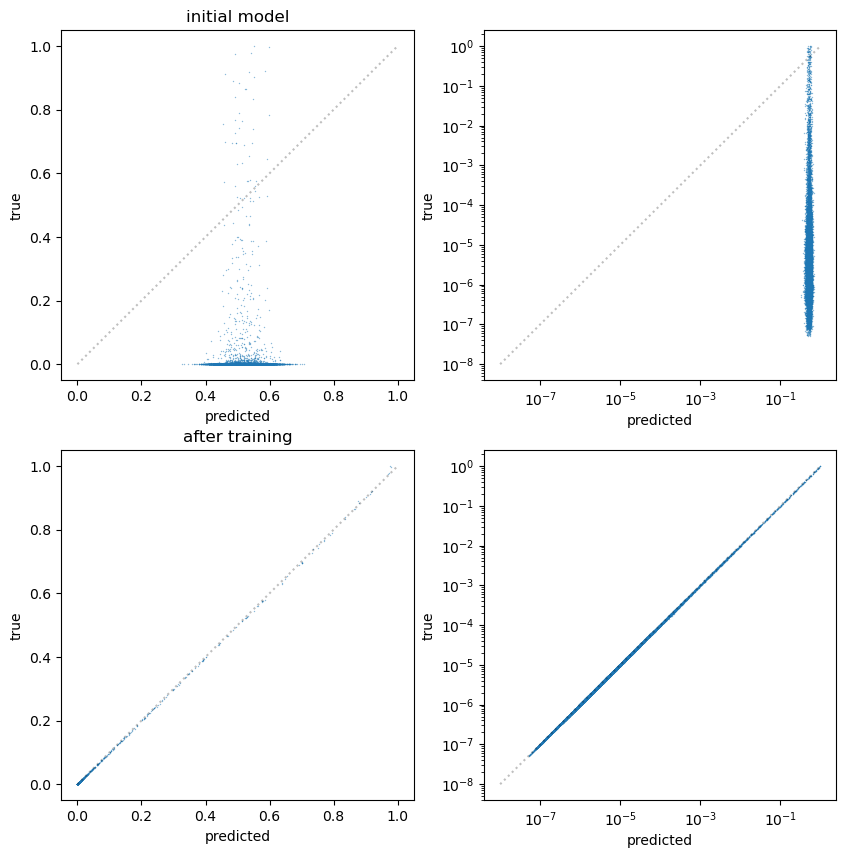

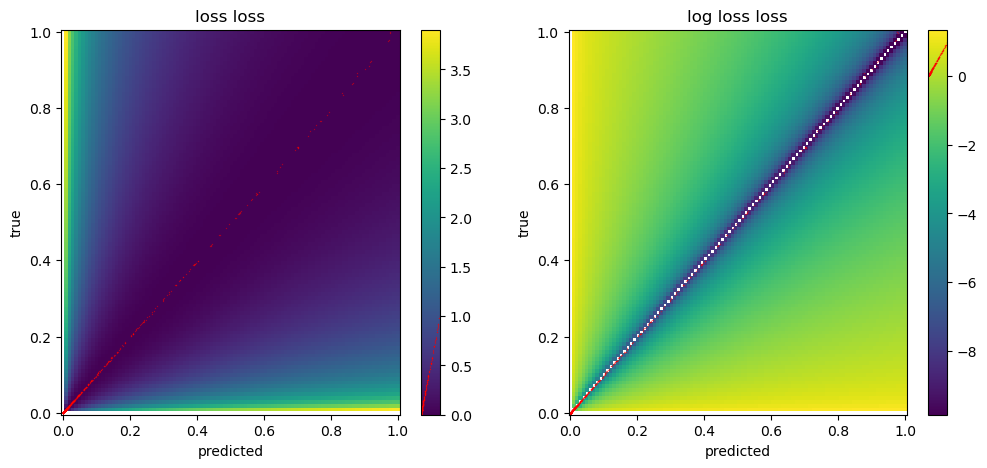

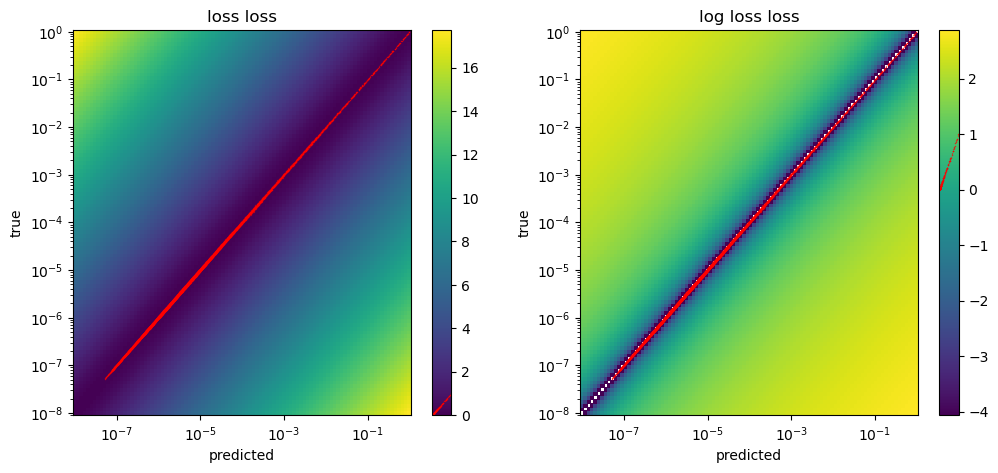

In [ ]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = symmetric_log_loss

def mloss(model, x, y, eps=1e-2):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mloss)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

# Longer runs

  0%|          | 0/25000 [00:00<?, ?it/s]

resid std: 4.3520427e-06 relative to image: 0.008650586 relmax: 0.0265279


/tmp/ipykernel_7355/3365995524.py:2: RuntimeWarning: divide by zero encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/3365995524.py:2: RuntimeWarning: invalid value encountered in divide
  x = (yp/yt + yt/yp)/2
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


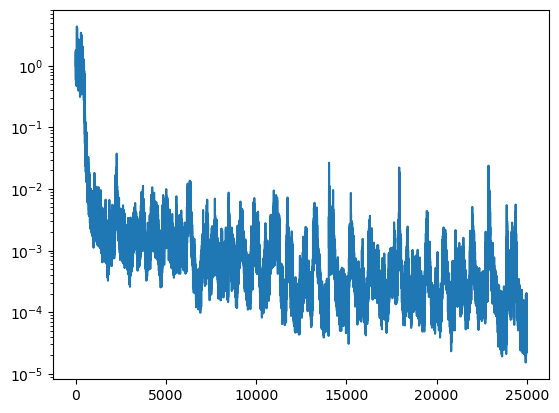

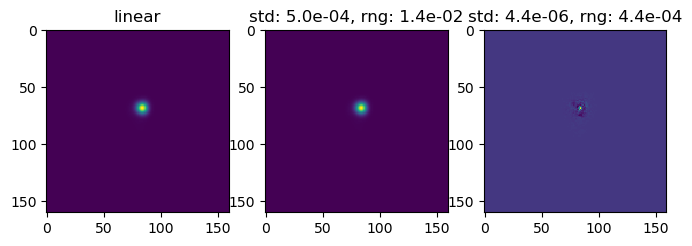

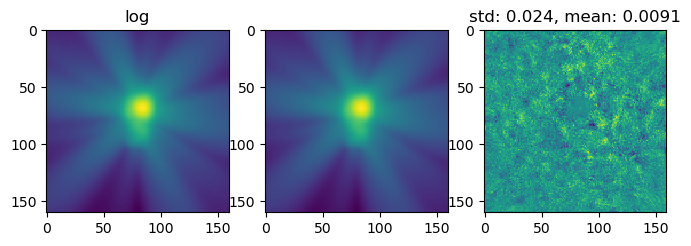

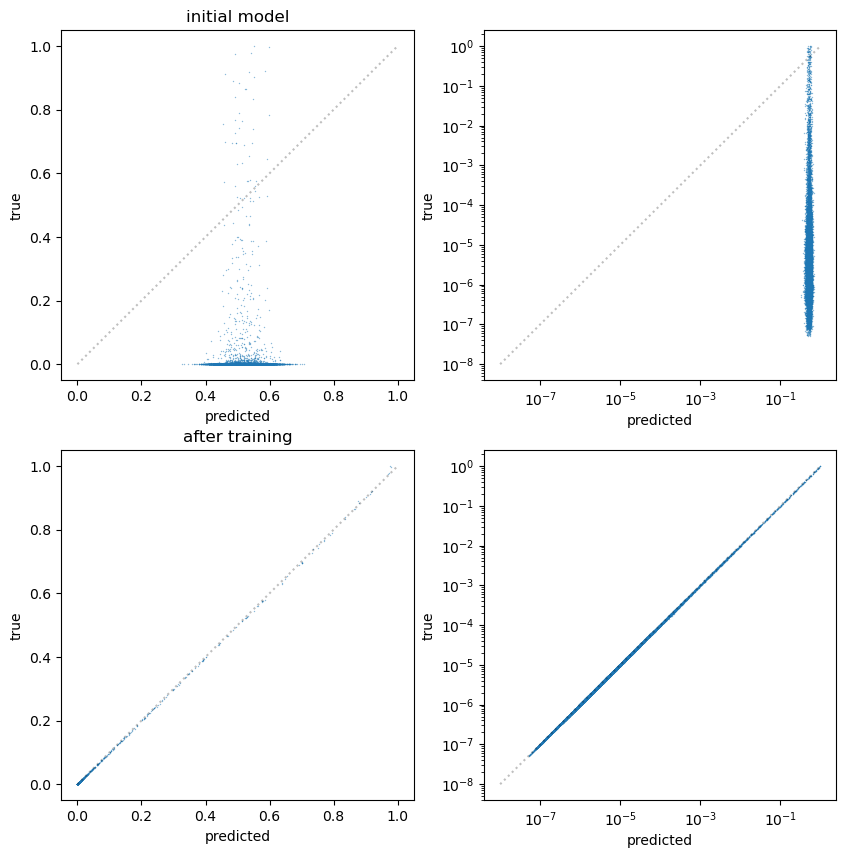

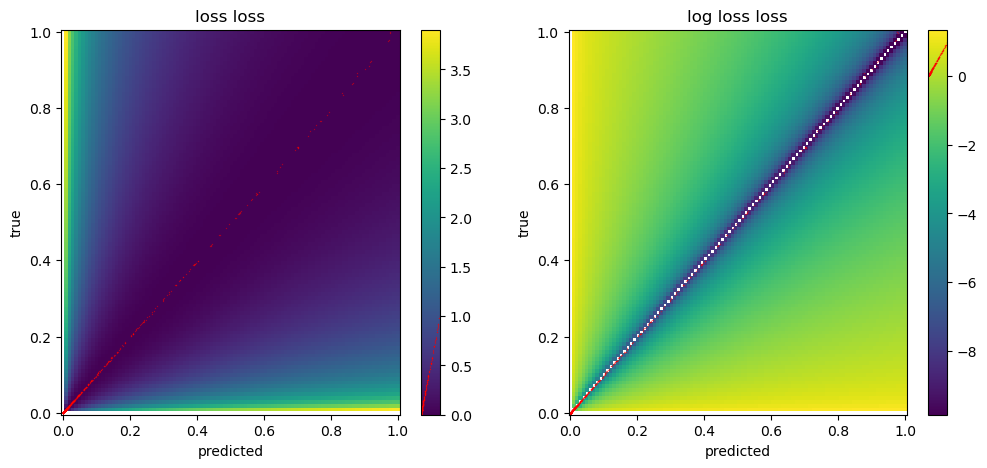

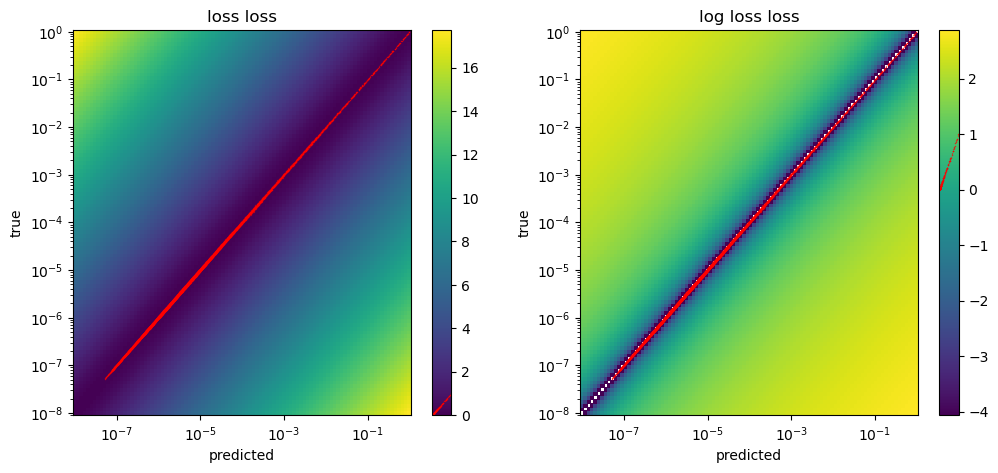

In [ ]:
LEARNING_RATE = 4e-4
EPOCHS = 25000
BATCH_SIZE = 2048

loss_to_use = symmetric_log_loss

def mloss(model, x, y, eps=1e-2):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mloss)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

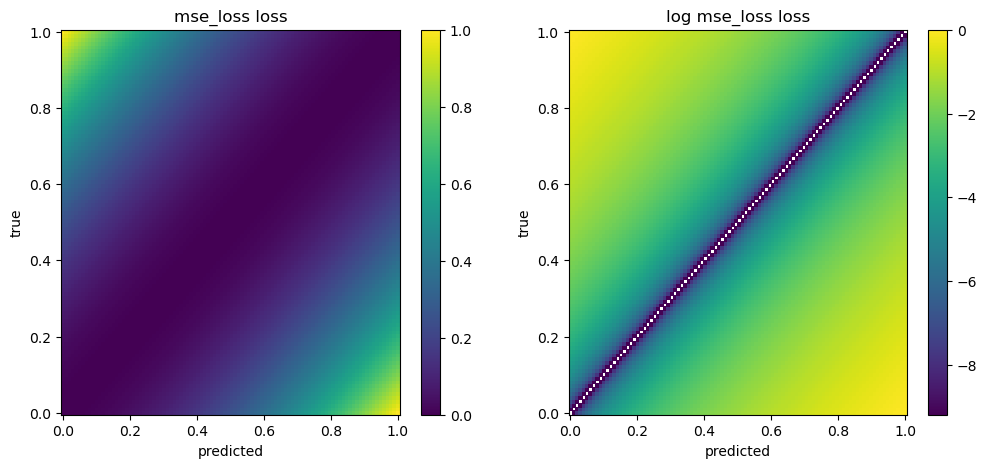

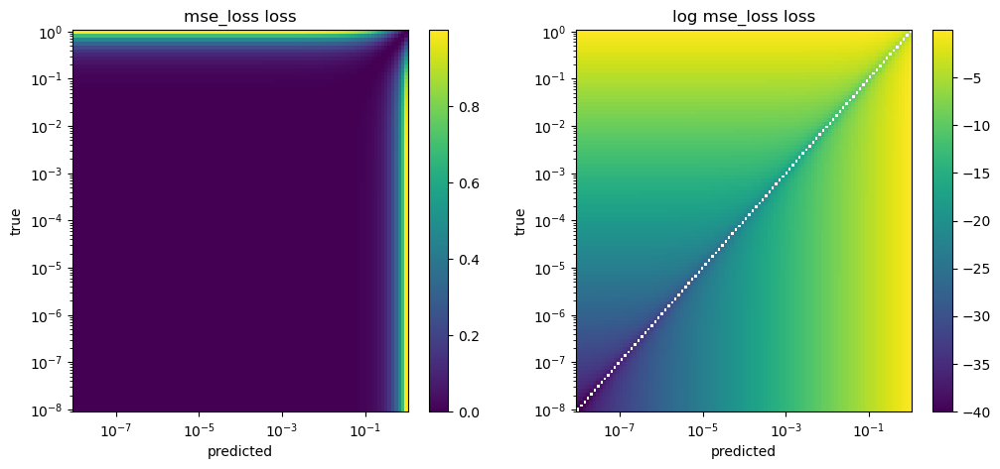

In [361]:
def mse_loss(yp, yt):
    return (yt-yp)**2

plot_losses(mse_loss, name='mse_loss')

  0%|          | 0/25000 [00:00<?, ?it/s]

resid std: 7.403437e-05 relative to image: 0.14715864 relmax: 0.15018788


/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


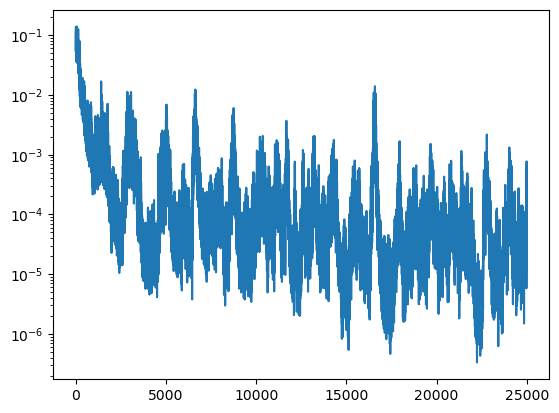

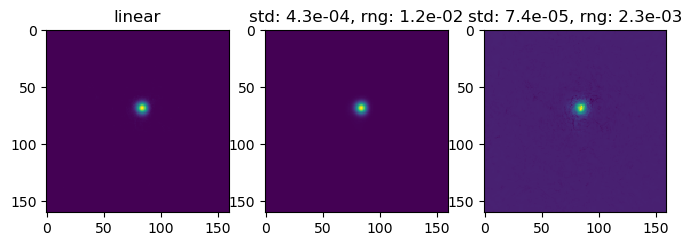

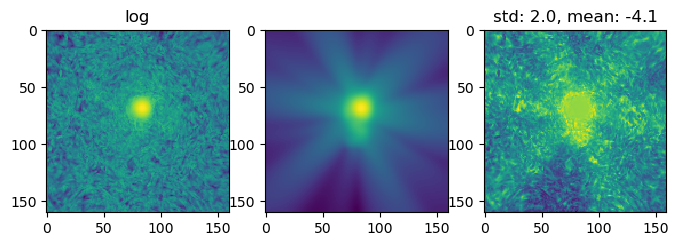

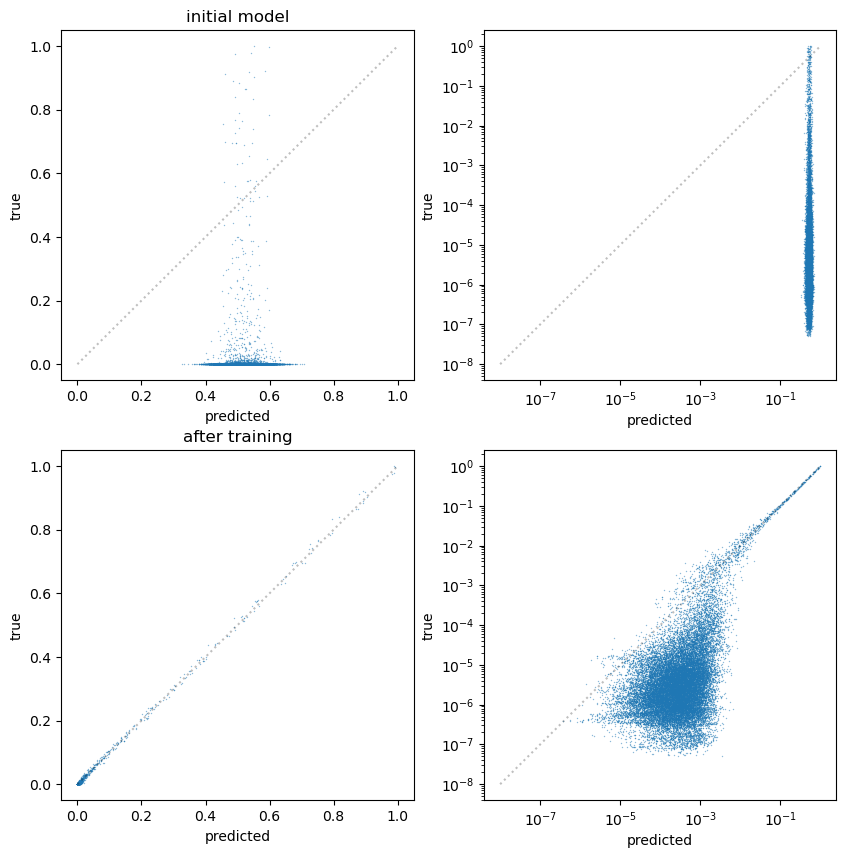

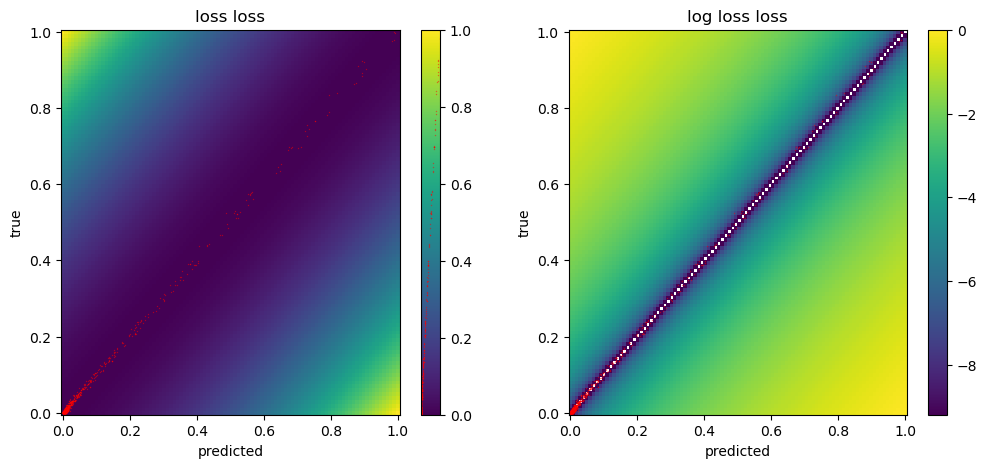

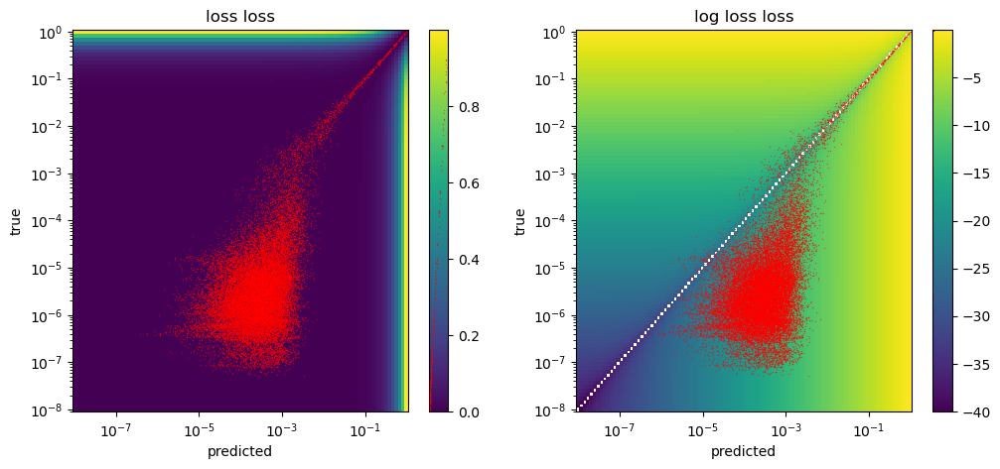

In [363]:
LEARNING_RATE = 4e-4
EPOCHS = 25000
BATCH_SIZE = 2048

loss_to_use = mse_loss

def mloss(model, x, y, eps=1e-2):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mloss)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

# Smoothly switch between log and mse while training

/tmp/ipykernel_7260/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7260/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


(<Figure size 1200x500 with 4 Axes>, <Figure size 1200x500 with 4 Axes>)

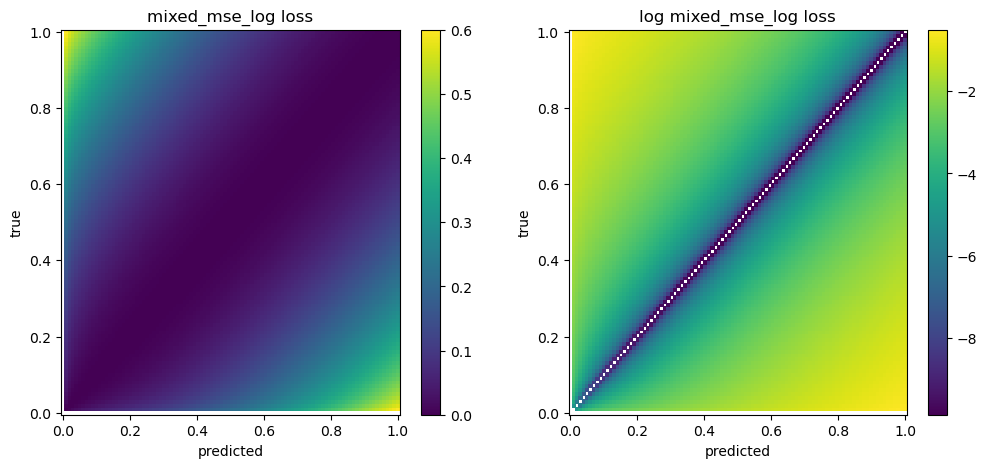

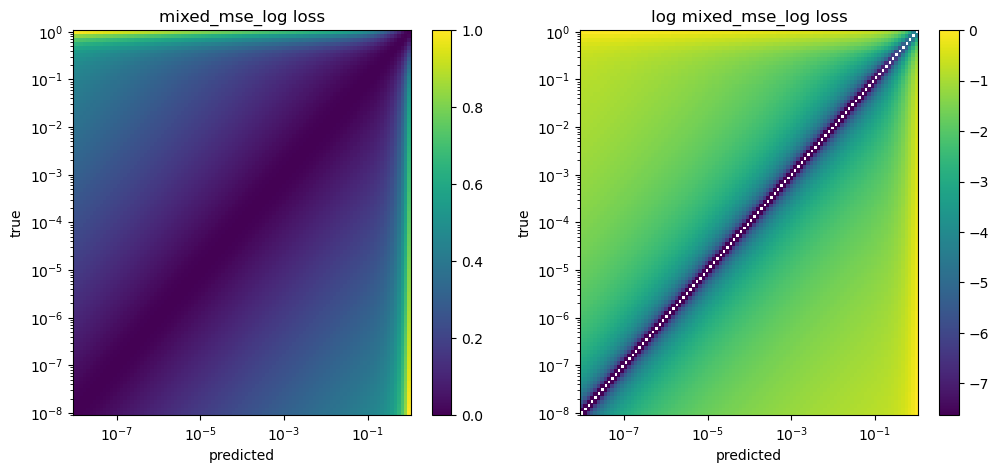

In [19]:
def mixed_mse_log_loss(yp, yt, wl=0.5, eps=0):
    lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
    mseterm = (yt-yp)**2
    return wl * lterm + (1 - wl) * mseterm

plot_losses(mixed_mse_log_loss, name='mixed_mse_log')

  0%|          | 0/25000 [00:00<?, ?it/s]

resid std: 1.5010274e-05 relative to image: 0.029836027 relmax: 0.040111274


/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


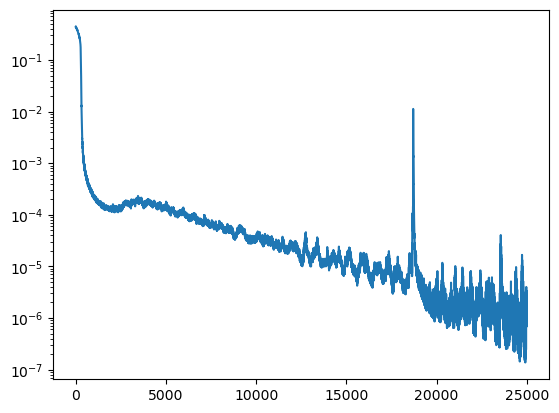

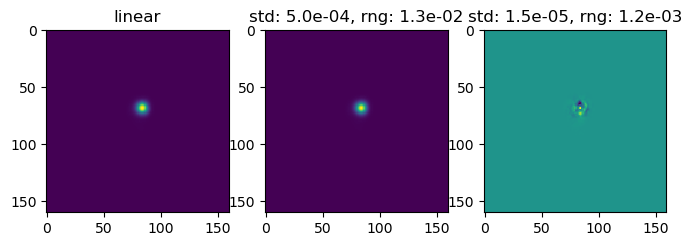

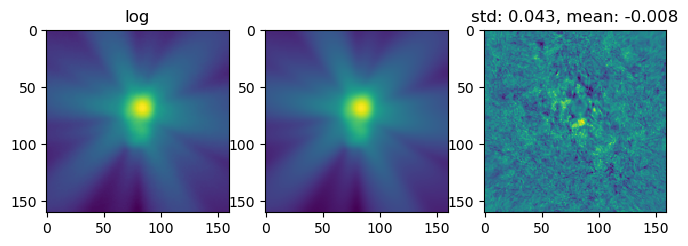

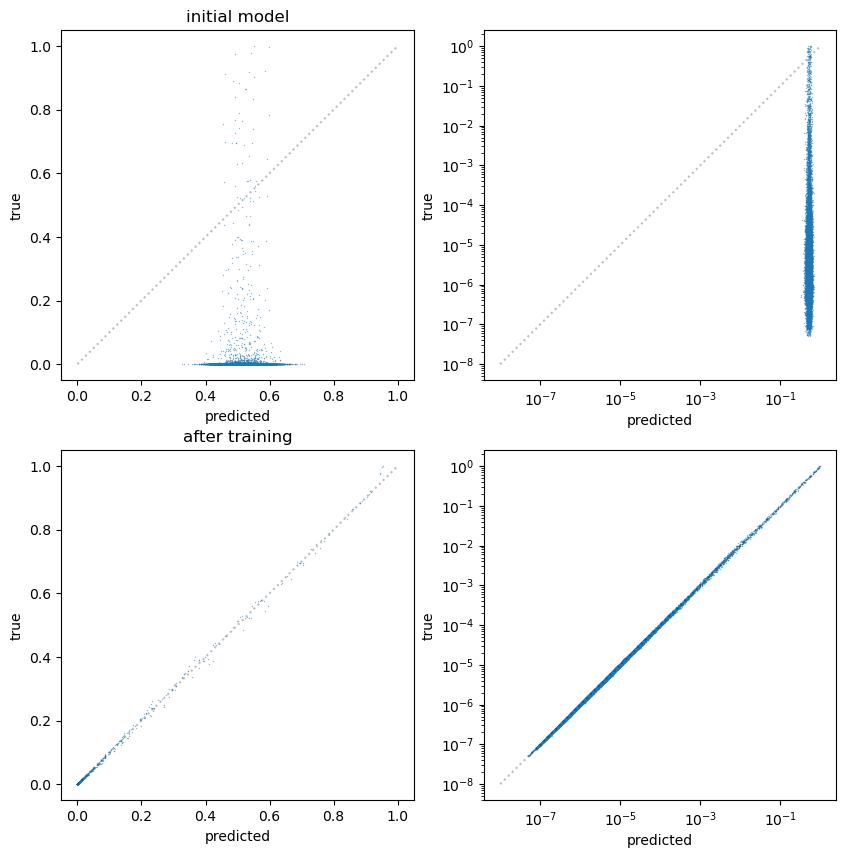

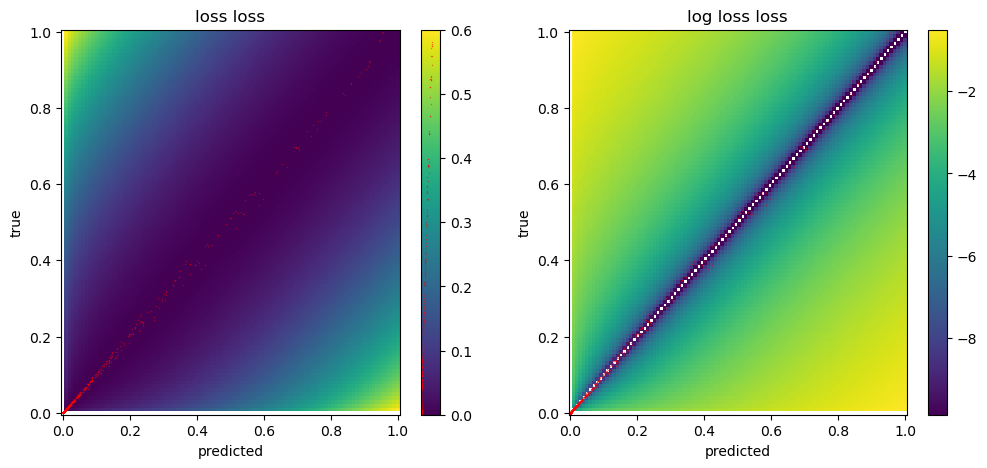

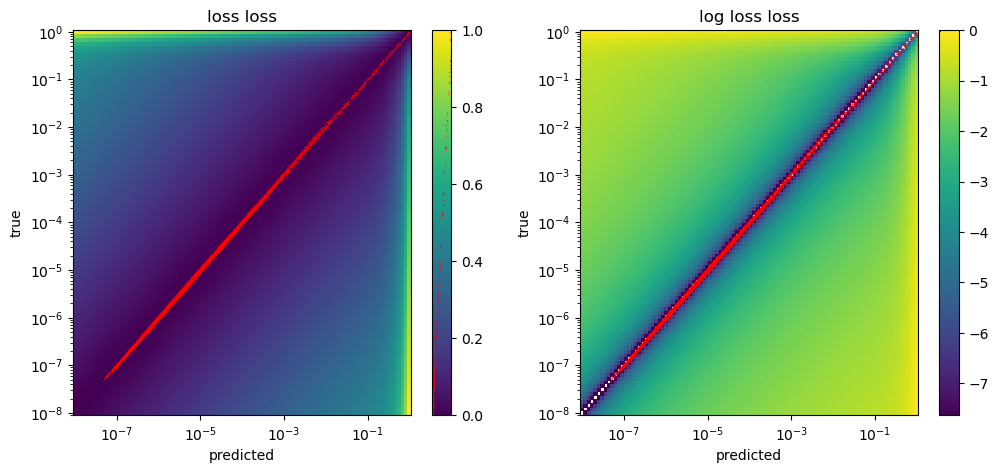

In [389]:
LEARNING_RATE = 4e-4
EPOCHS = 25000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci)*0.5)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

### Adjust some of the model parameters

#### Fiducial

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 2.873571e-05 relative to image: 0.057118174 relmax: 0.054600943


/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


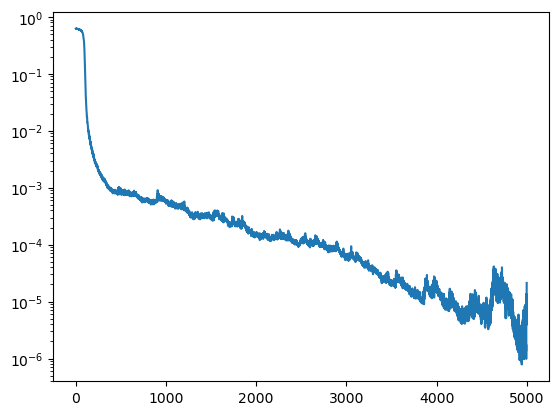

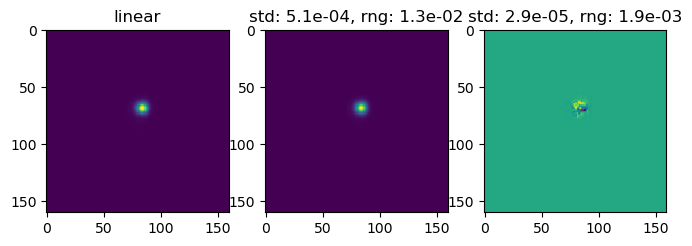

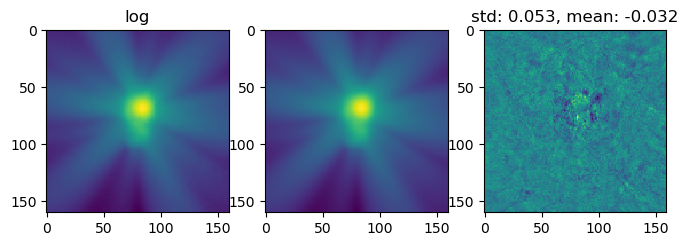

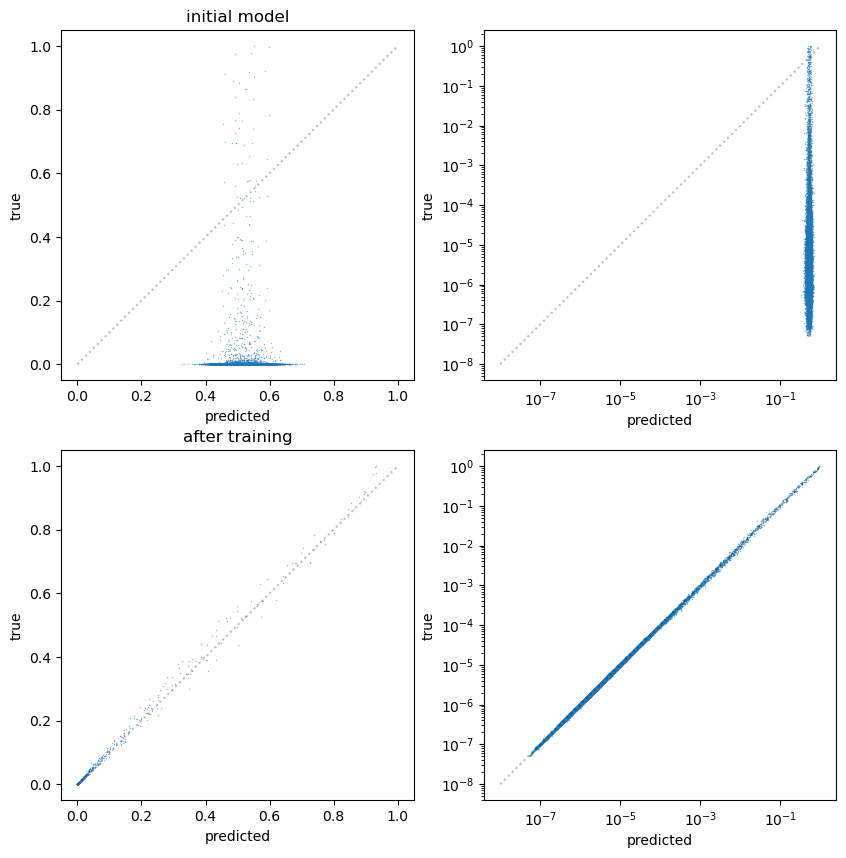

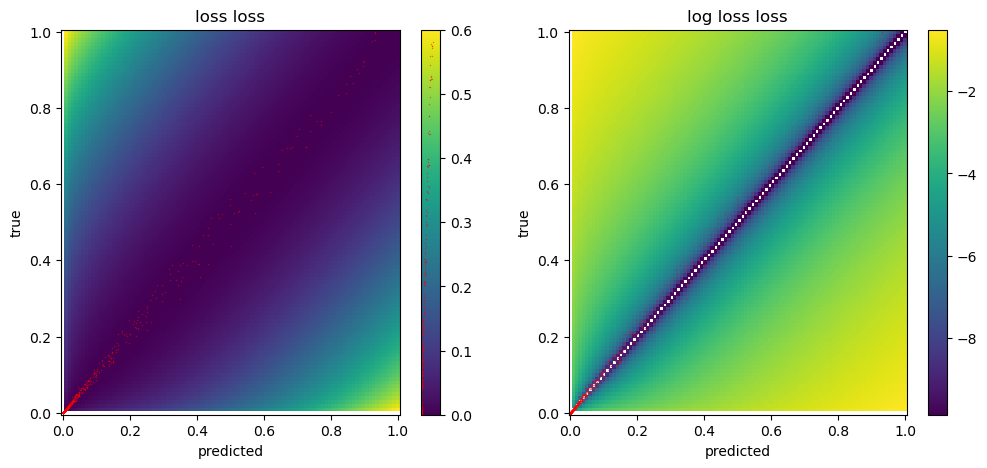

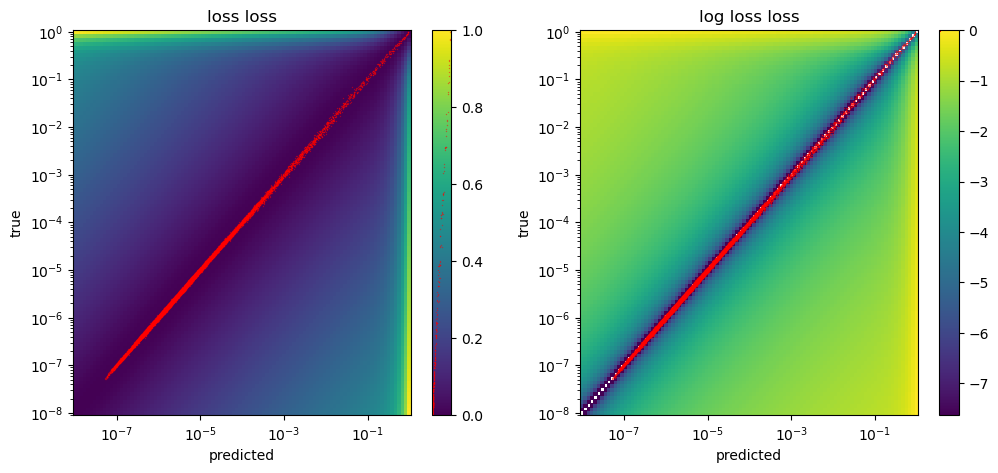

In [500]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=10, w0=20) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci))

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 1.7057078e-05 relative to image: 0.033904474 relmax: 0.04058504


/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


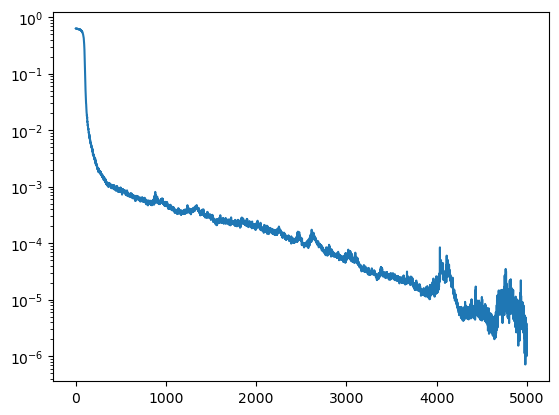

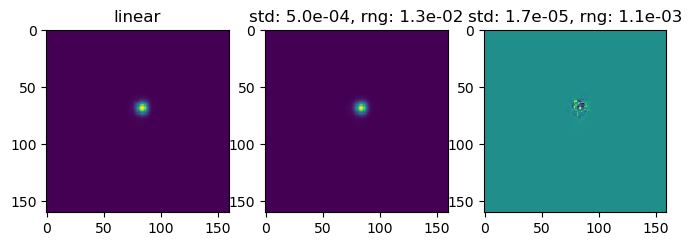

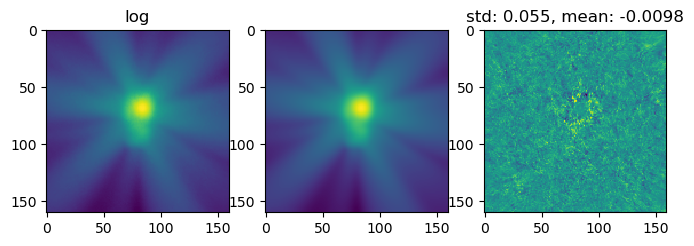

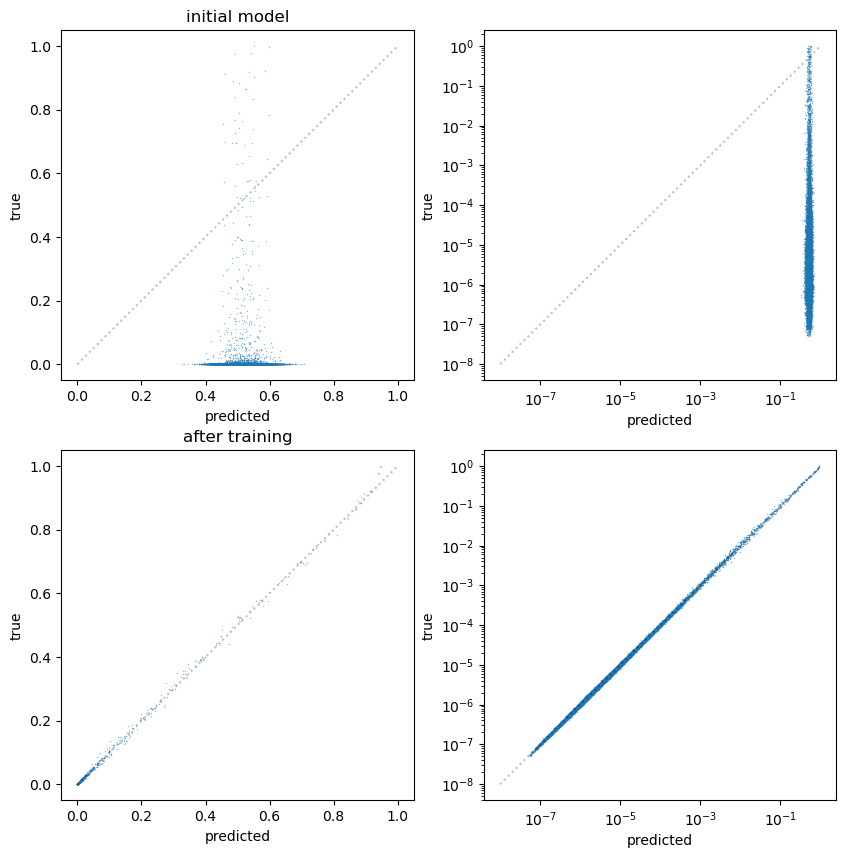

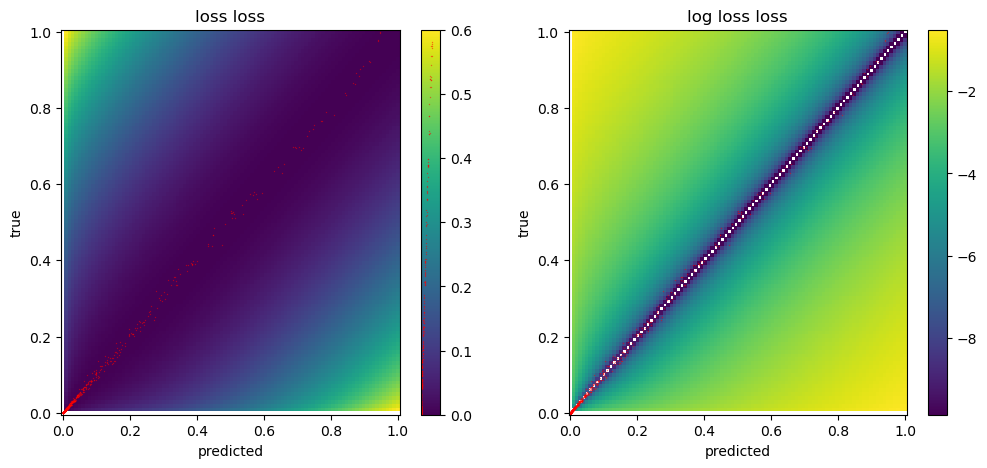

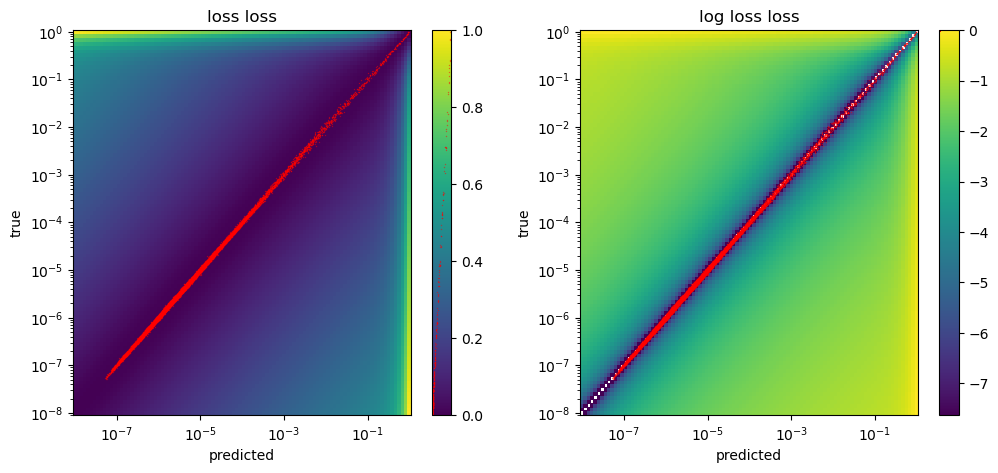

#### Extra hidden layer

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 8.7428554e-05 relative to image: 0.17378235 relmax: 0.20008162


/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


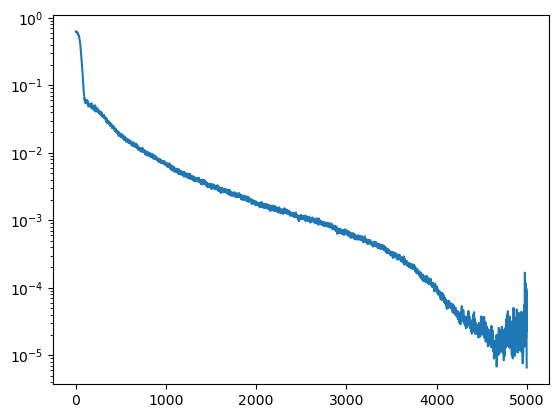

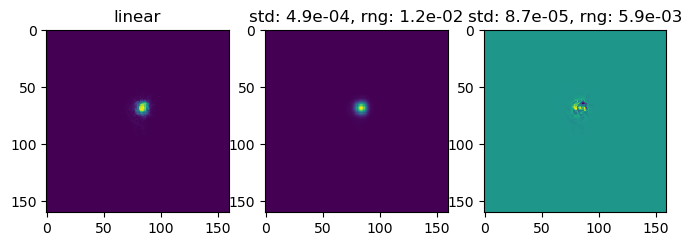

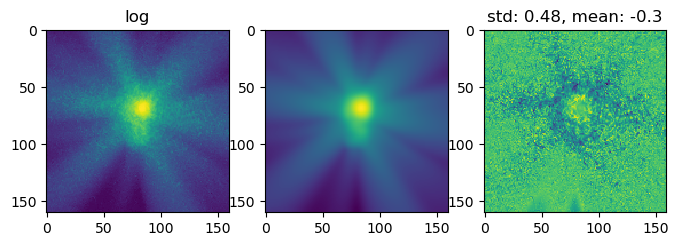

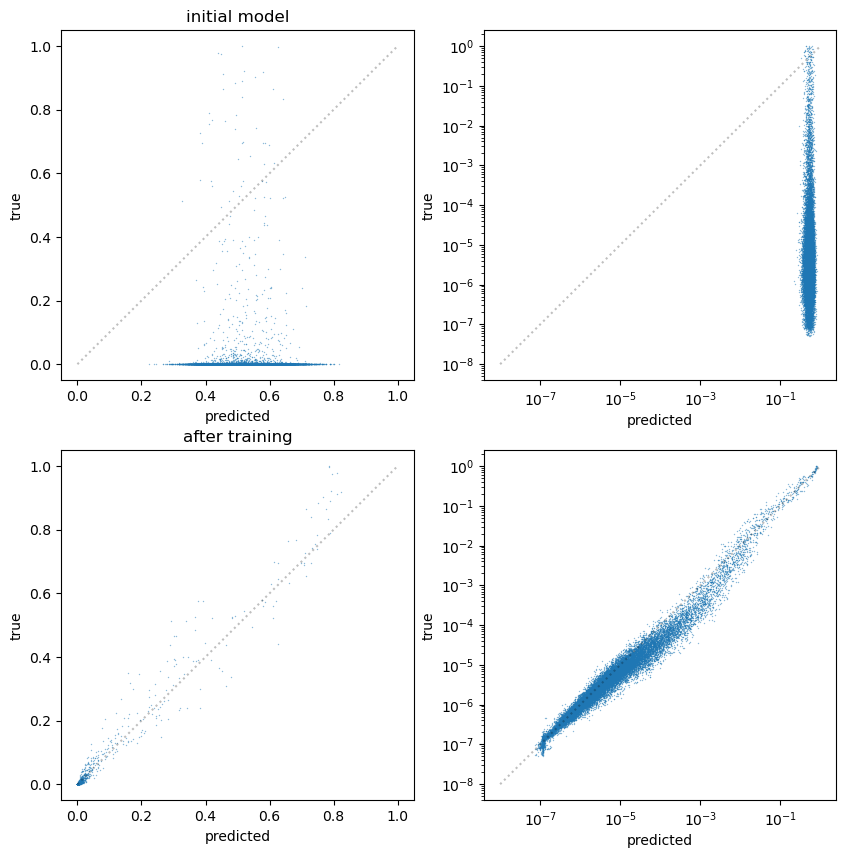

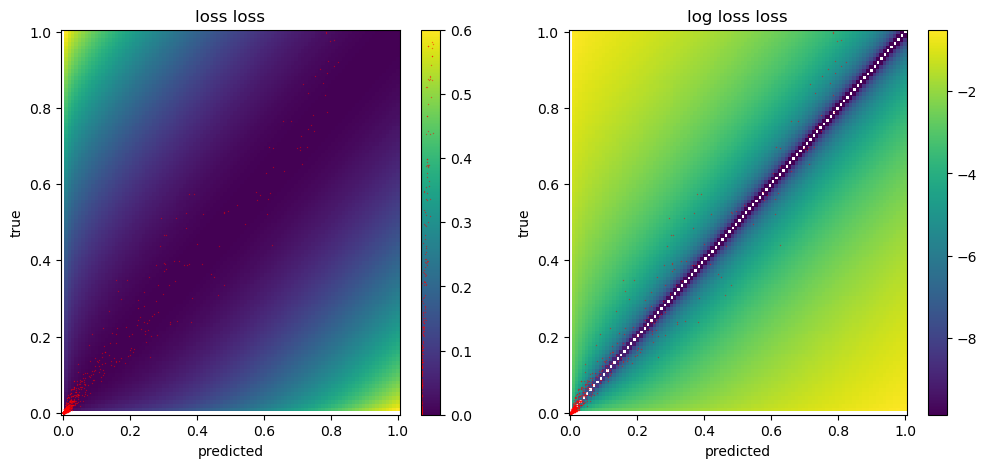

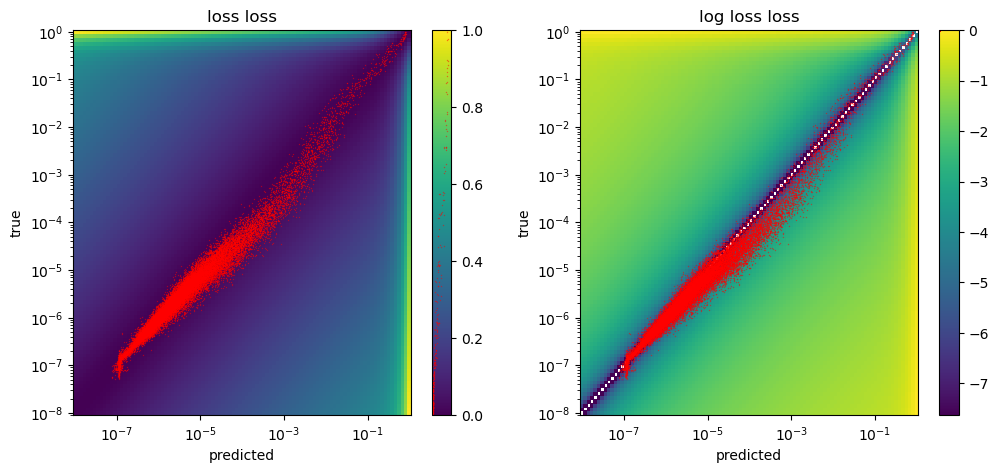

In [468]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=3, s0=10, w0=20) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci))

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

#### Boost layer width

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 4.0011317e-05 relative to image: 0.079530776 relmax: 0.0966451


/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


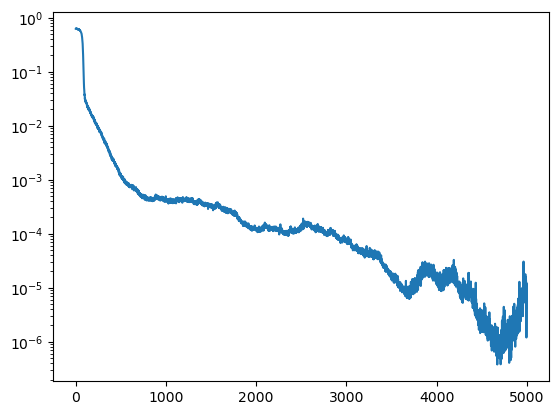

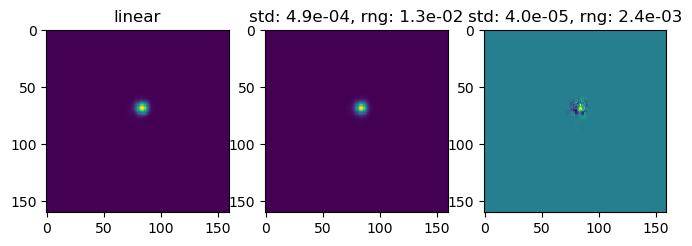

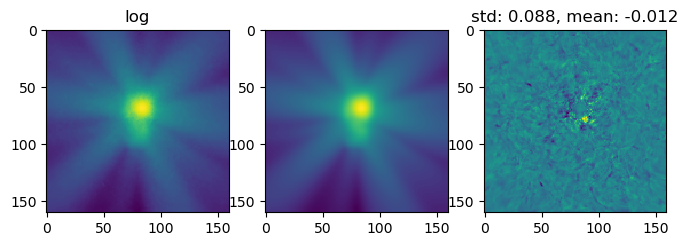

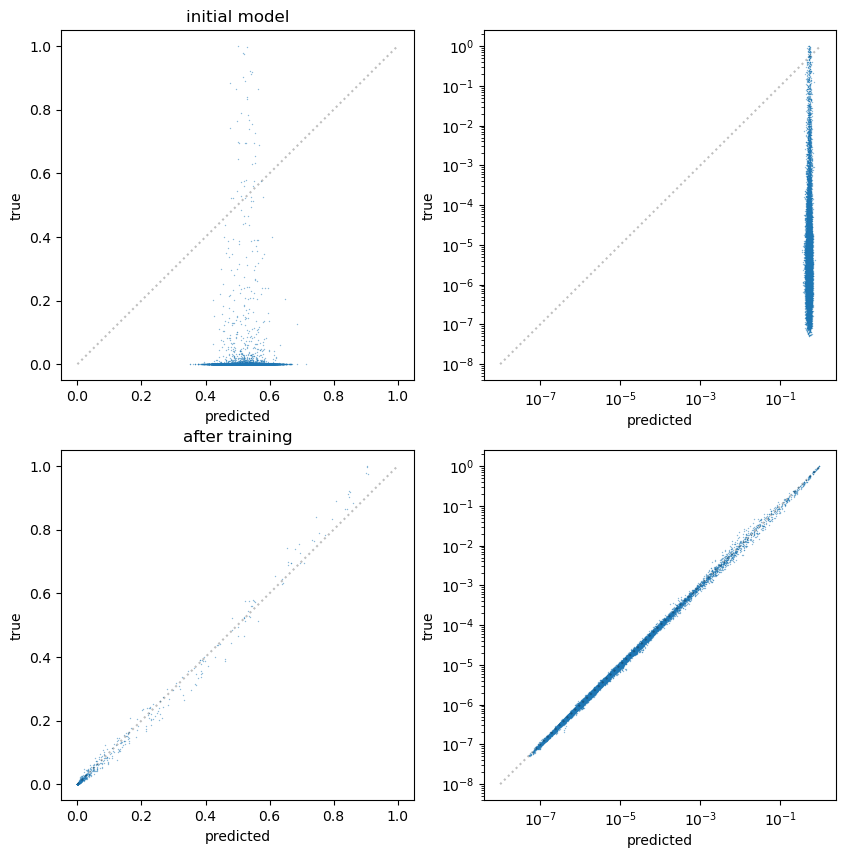

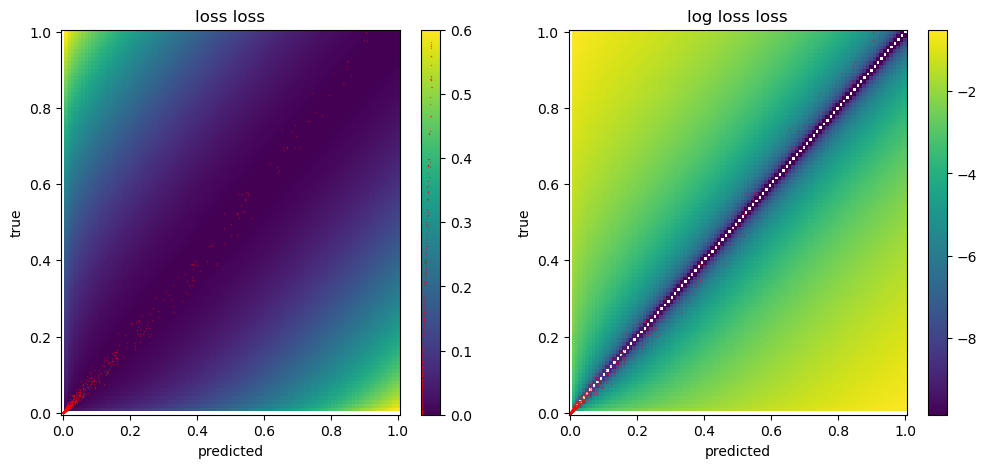

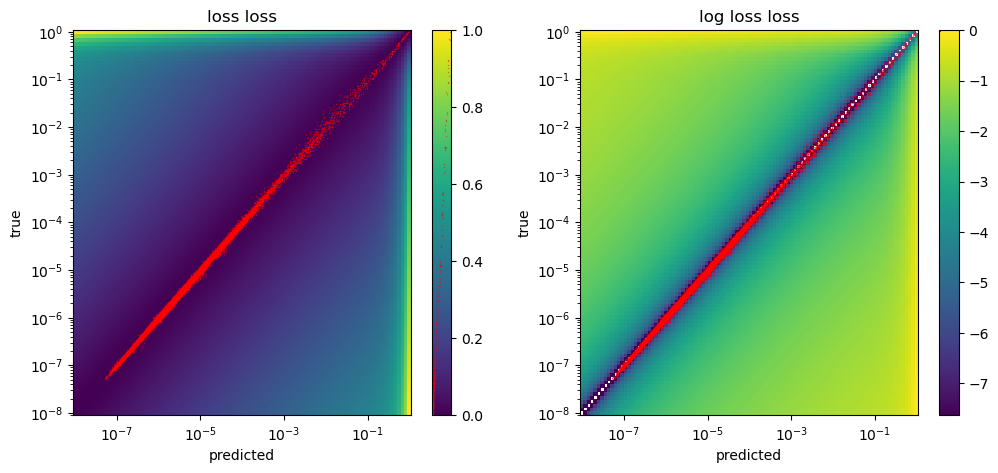

In [501]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl, epsl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl, epsl=epsl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=256, num_hidden_layers=2, s0=10, w0=20) 
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci), epsl=0)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

#### Boost s0

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 0.00010442231 relative to image: 0.20756096 relmax: 0.36355916


/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


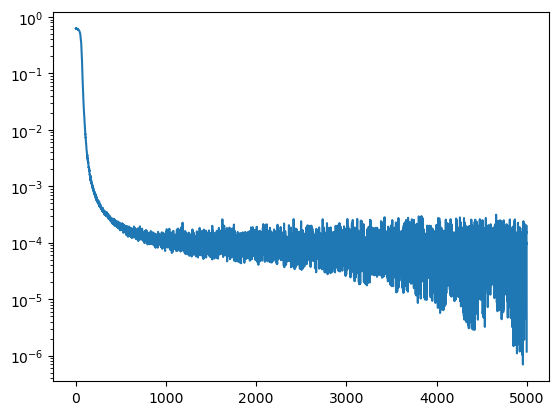

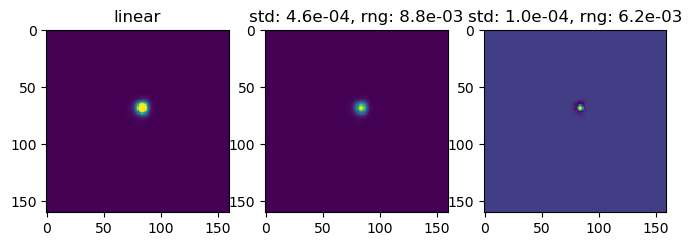

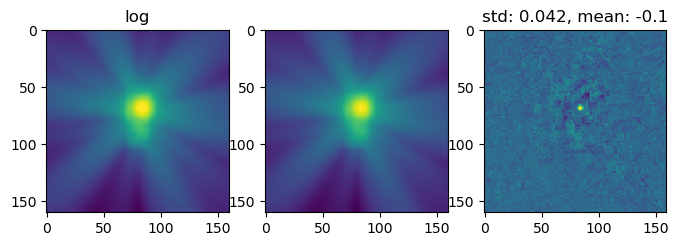

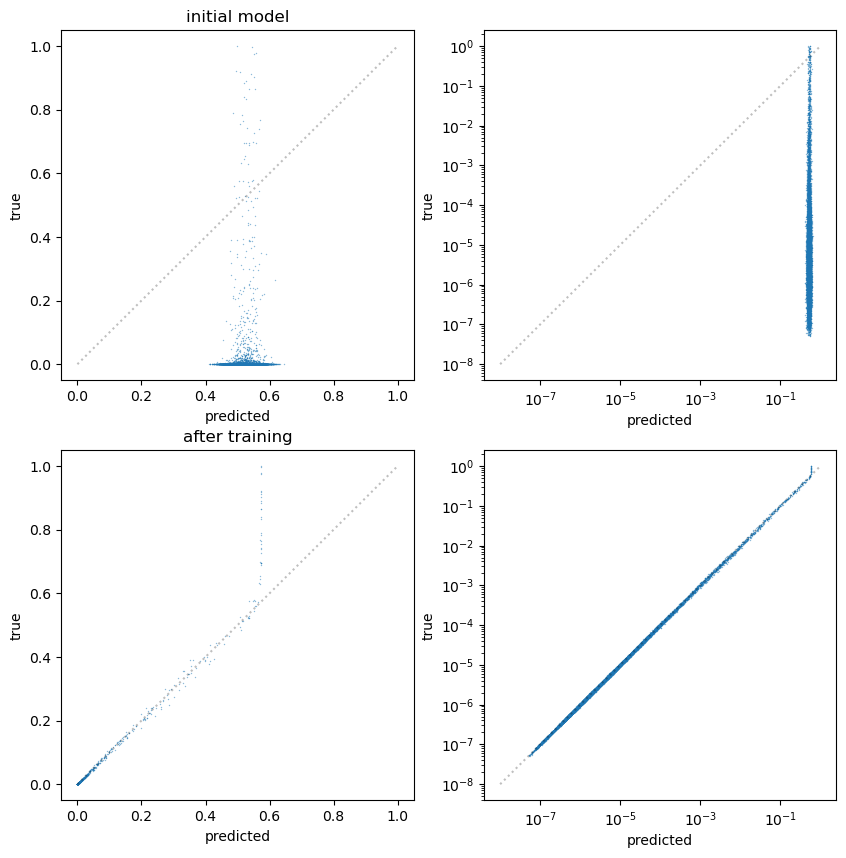

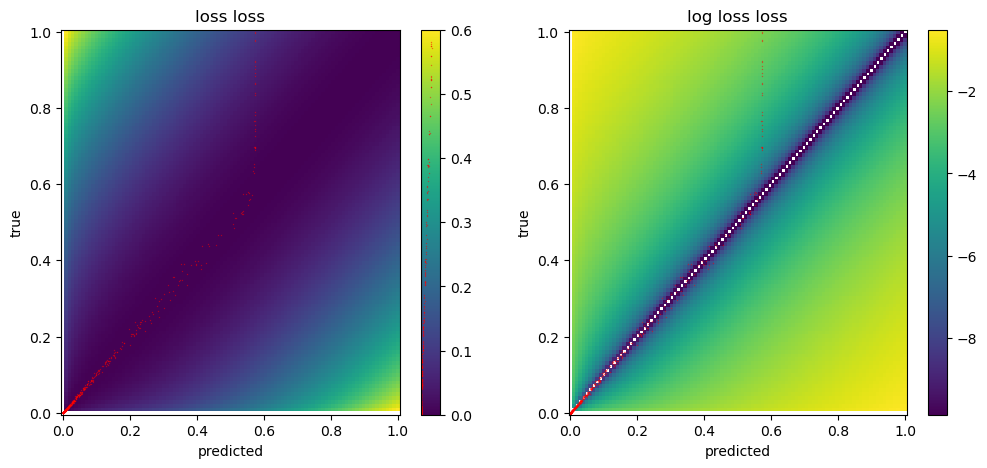

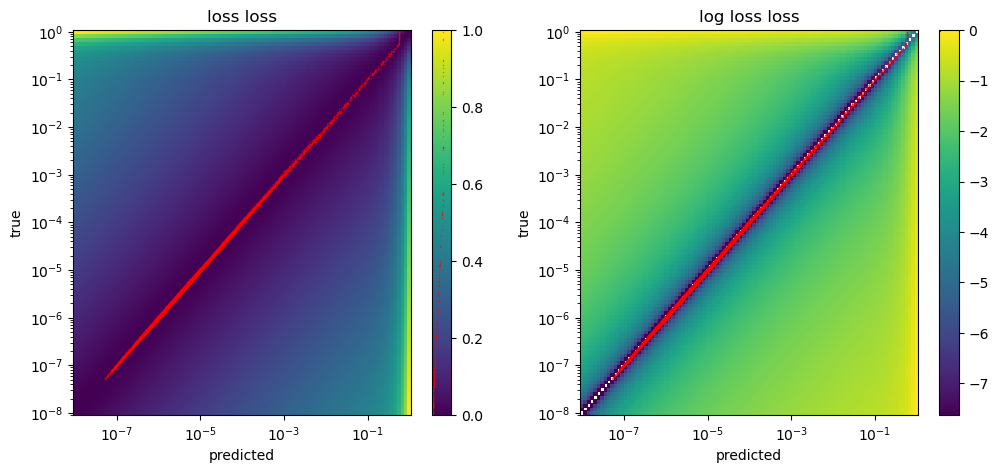

In [474]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=20, w0=20) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci))

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

#### Shrink s0

  0%|          | 0/15000 [00:00<?, ?it/s]

resid std: 0.0005030849 relative to image: 0.9999854 relmax: 0.9971876


/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


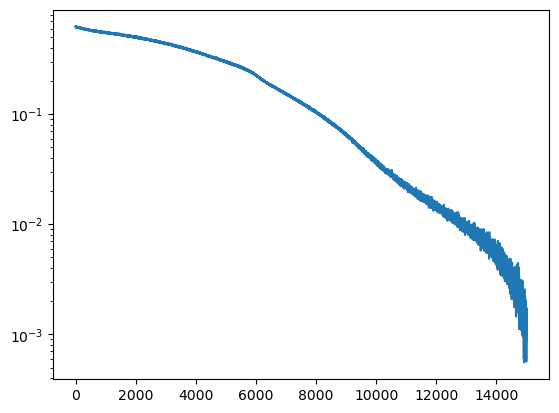

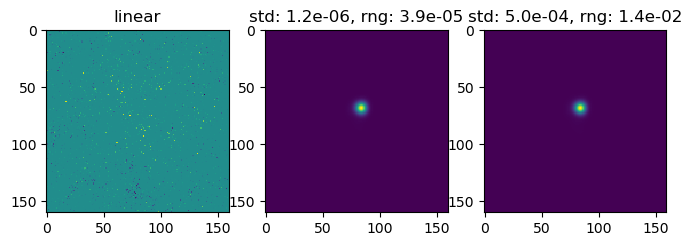

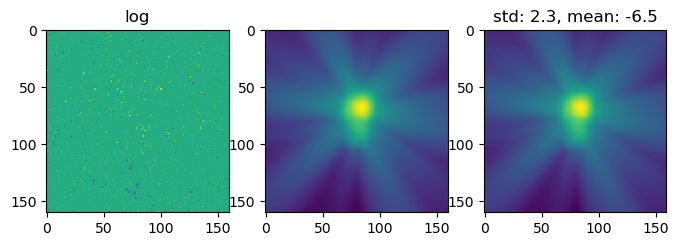

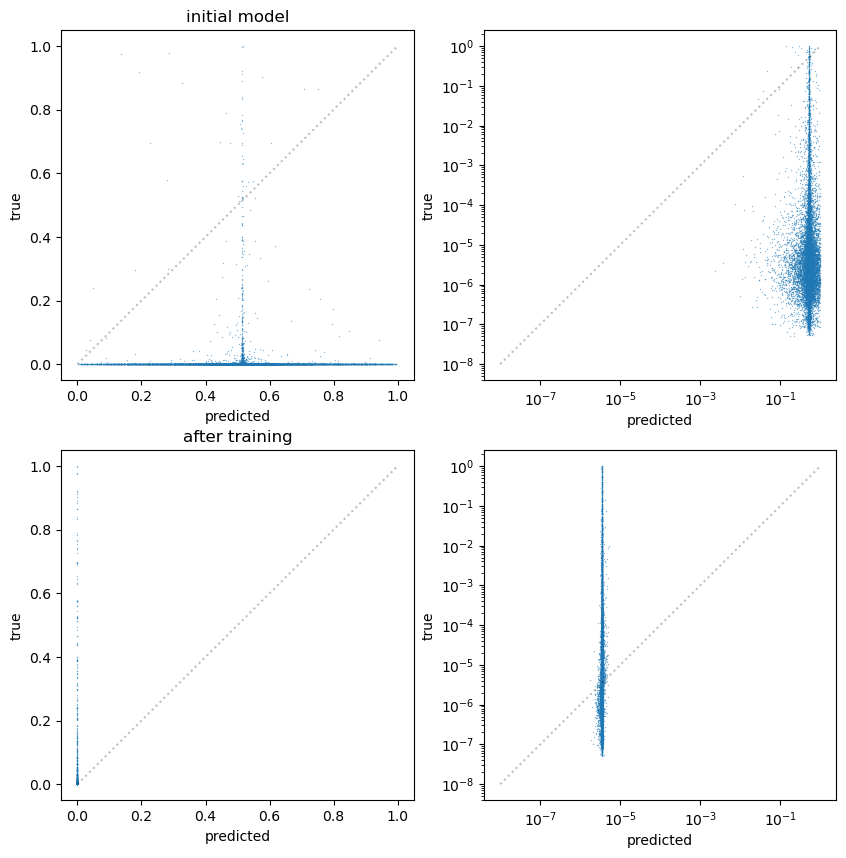

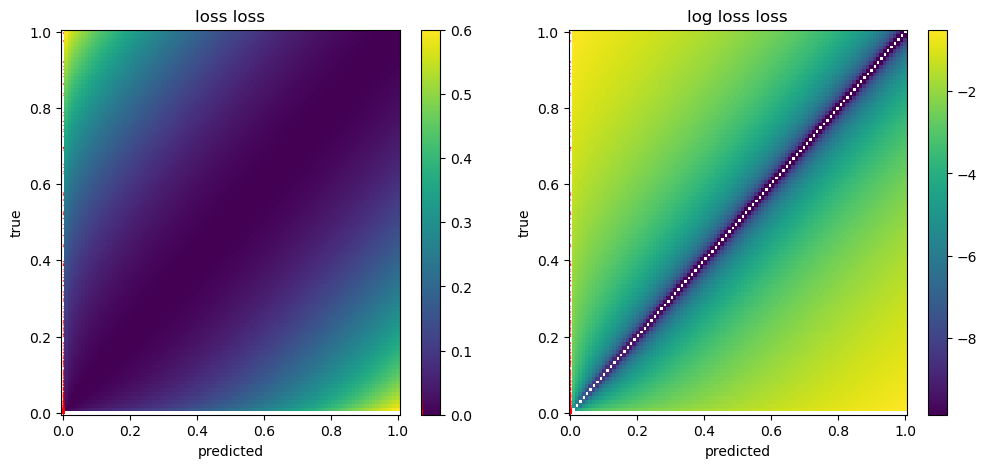

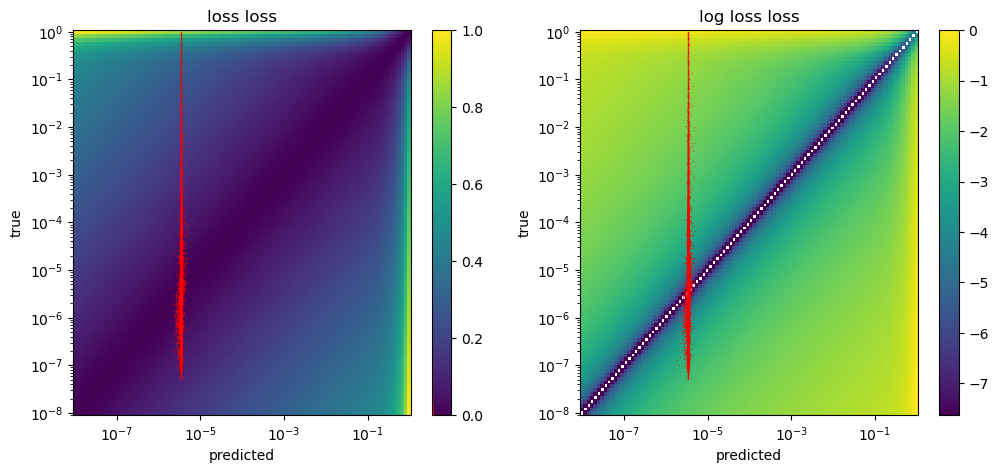

In [495]:
LEARNING_RATE = 1e-3
EPOCHS = 15000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl, epsl=1e-8)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=5, w0=20) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

#optimizer = optax.adam(learning_rate=LEARNING_RATE)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(LEARNING_RATE))

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci))

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

#### Boost w0

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 0.0005030859 relative to image: 0.99998736 relmax: 0.9971812


/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


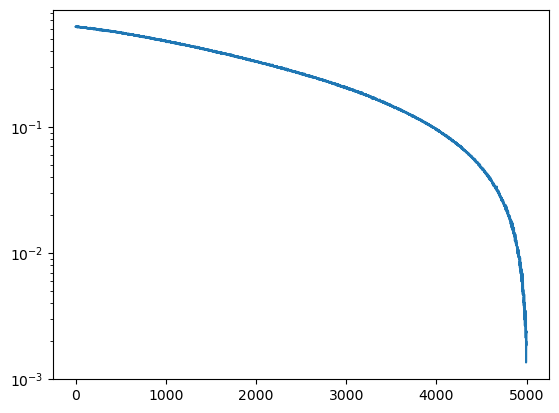

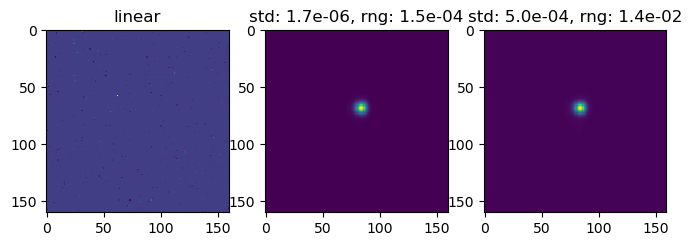

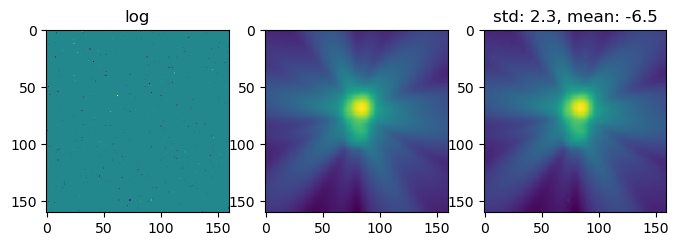

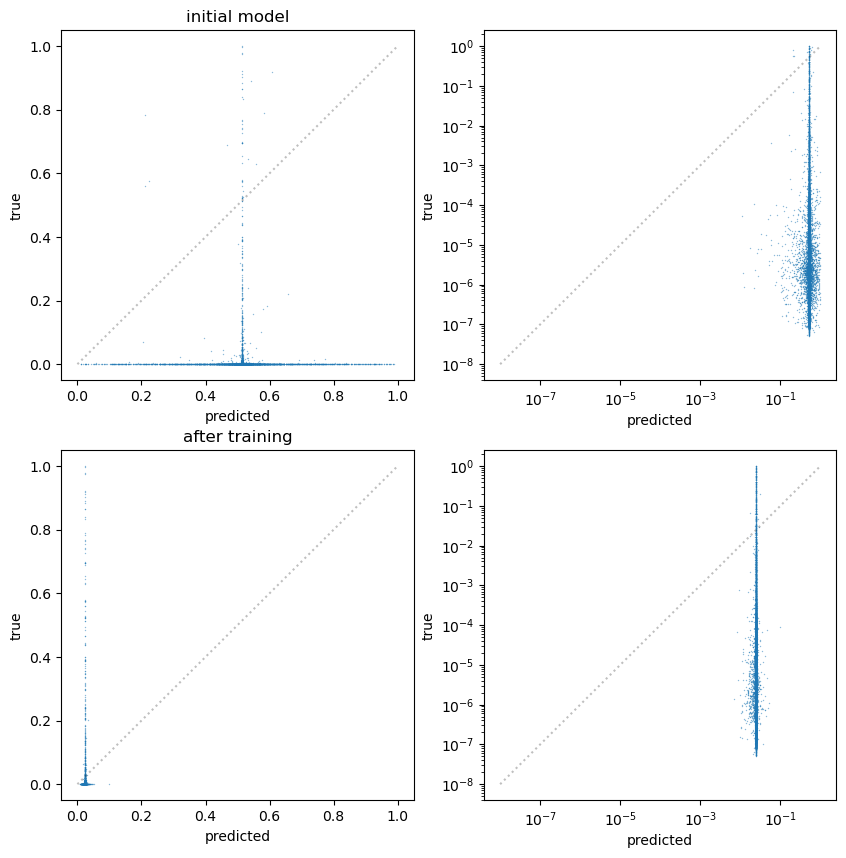

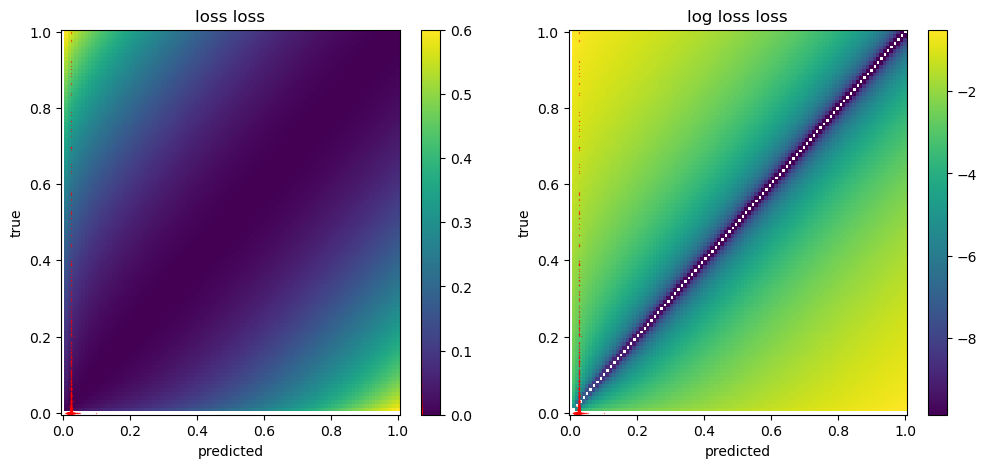

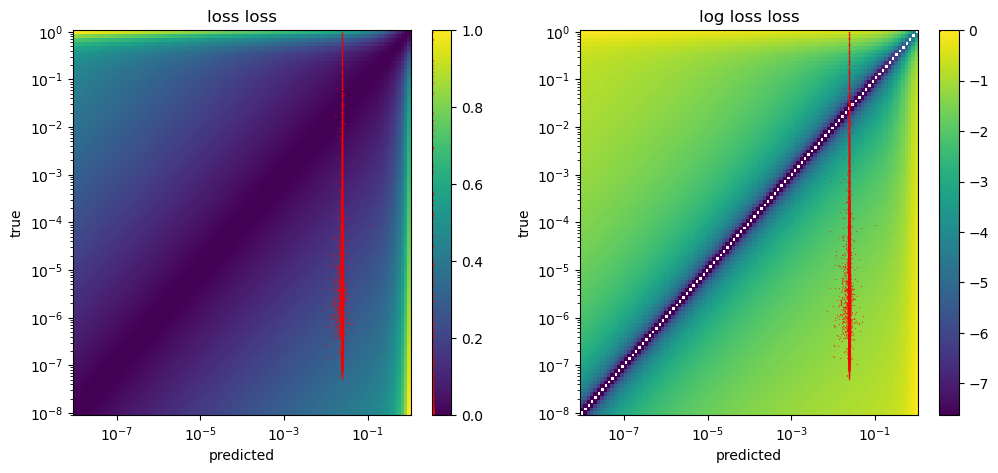

In [407]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=10, w0=40) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci))

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

#### Shrink w0

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 2.6620042e-05 relative to image: 0.052912846 relmax: 0.10683935


/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/3490482992.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/yt + yt/yp)/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


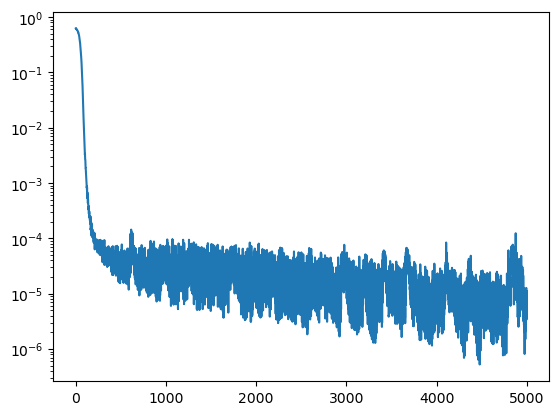

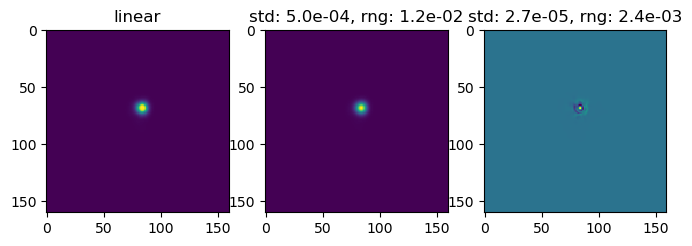

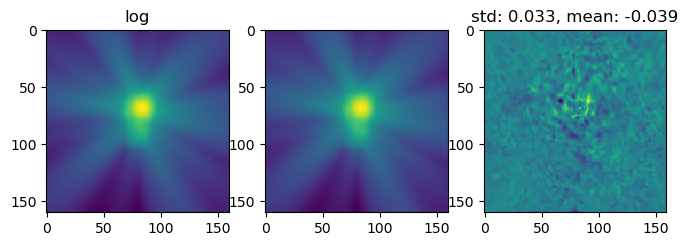

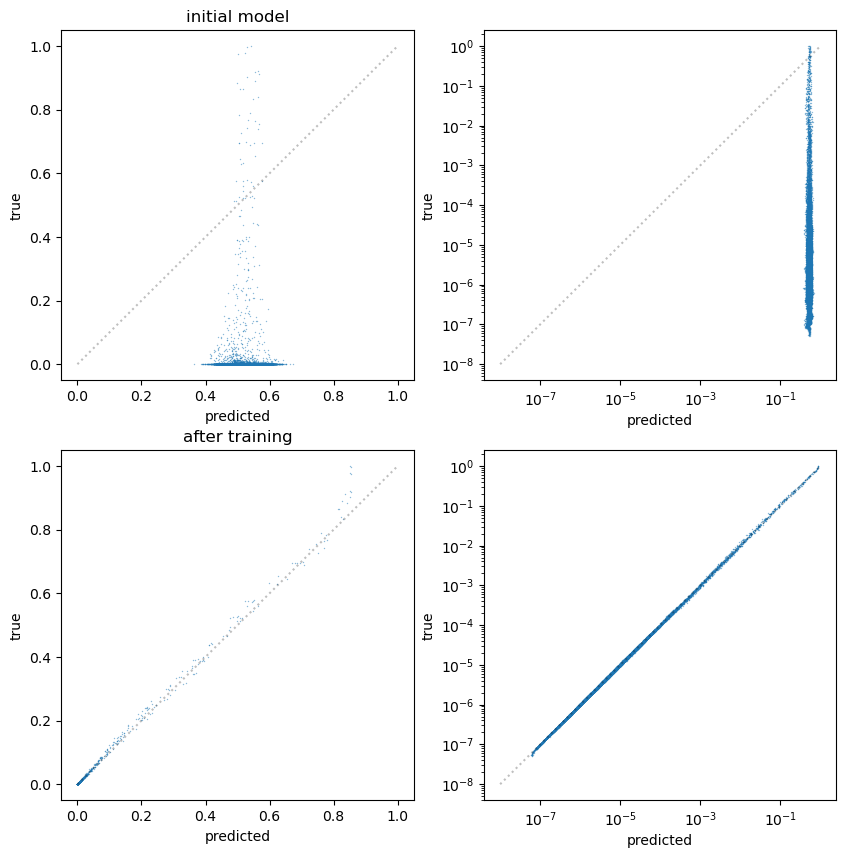

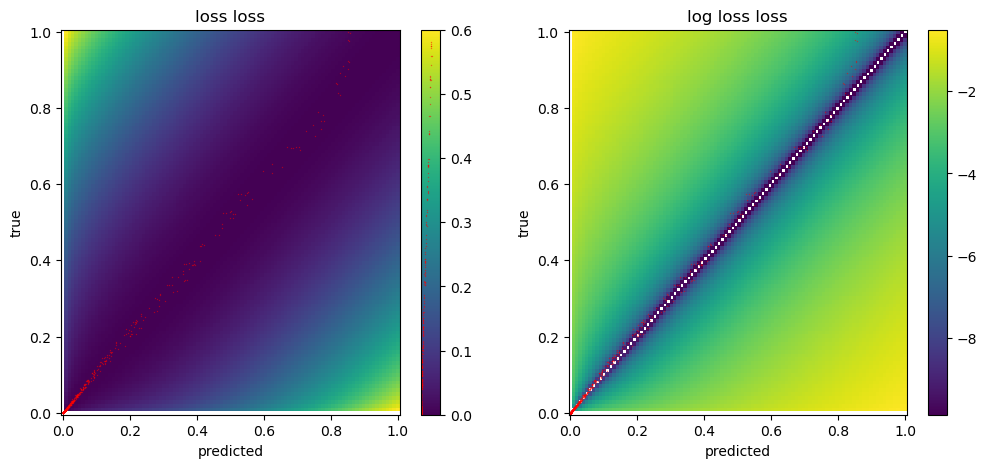

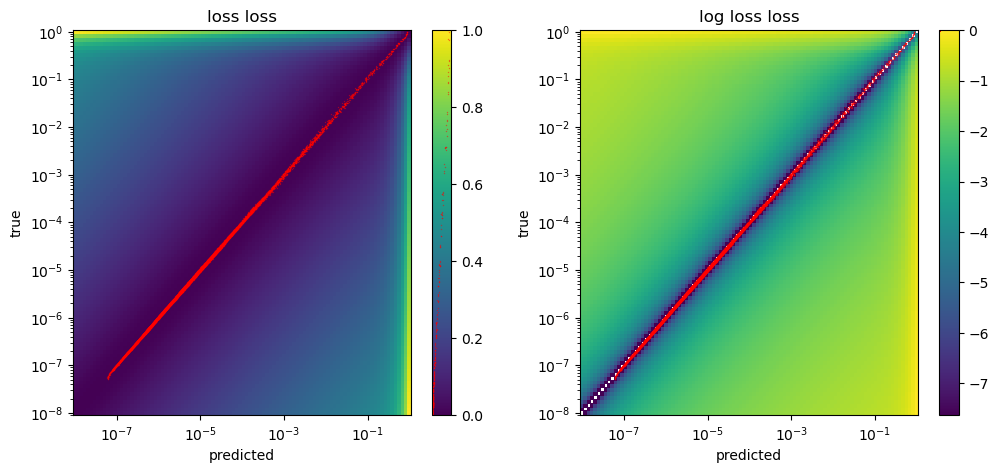

In [408]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=10, w0=10) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci))

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

#### Shrink both

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 6.262923e-05 relative to image: 0.12448856 relmax: 0.18093826


/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


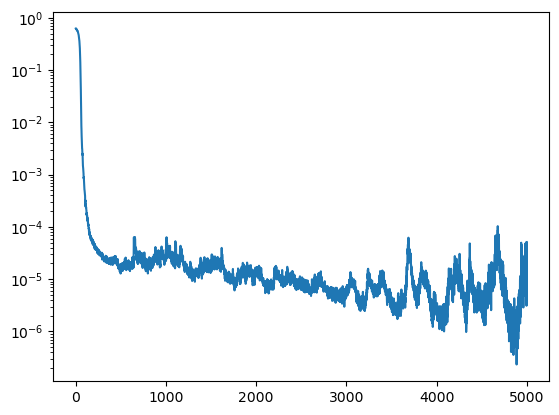

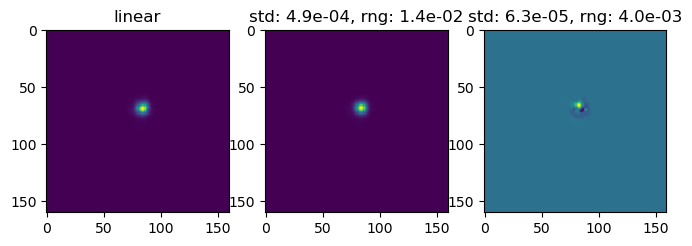

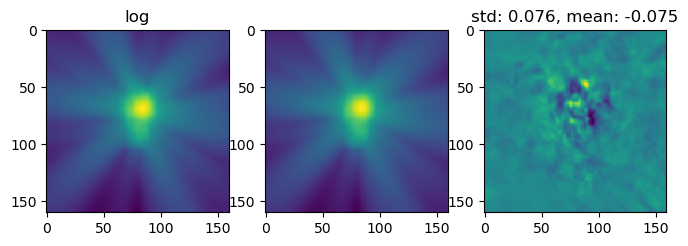

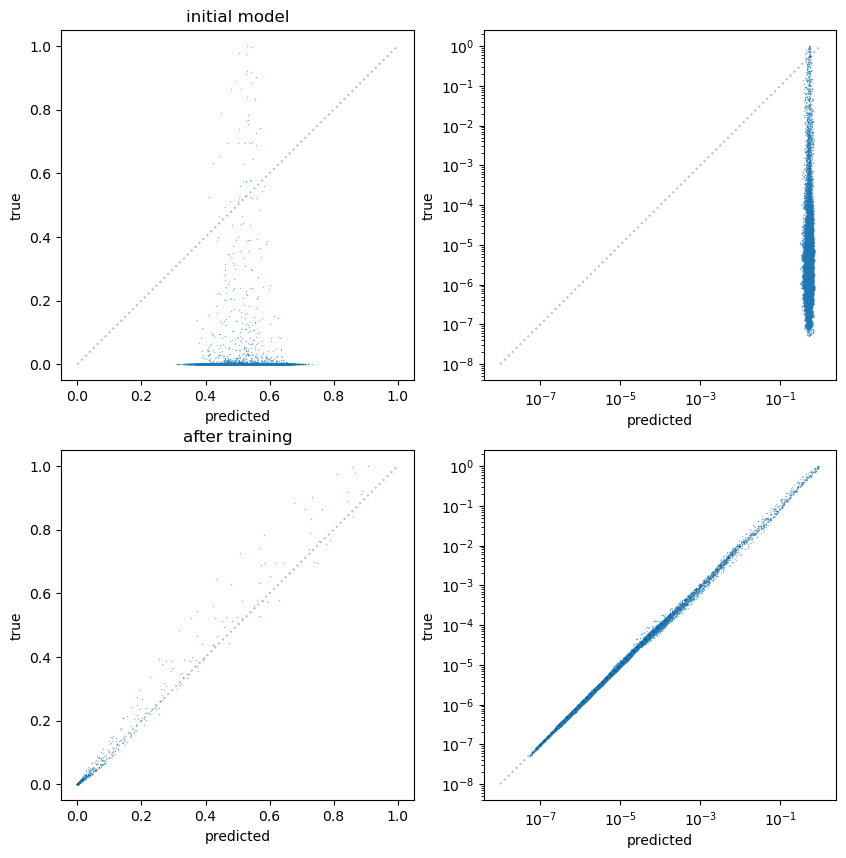

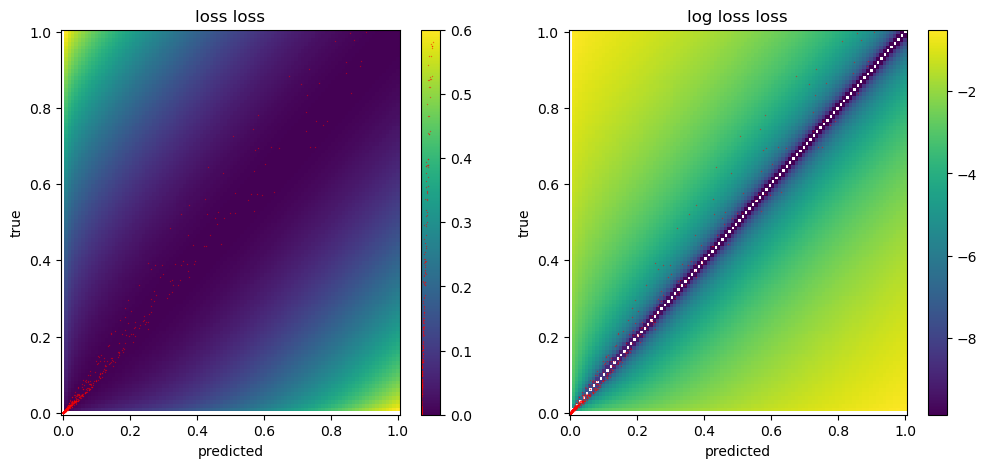

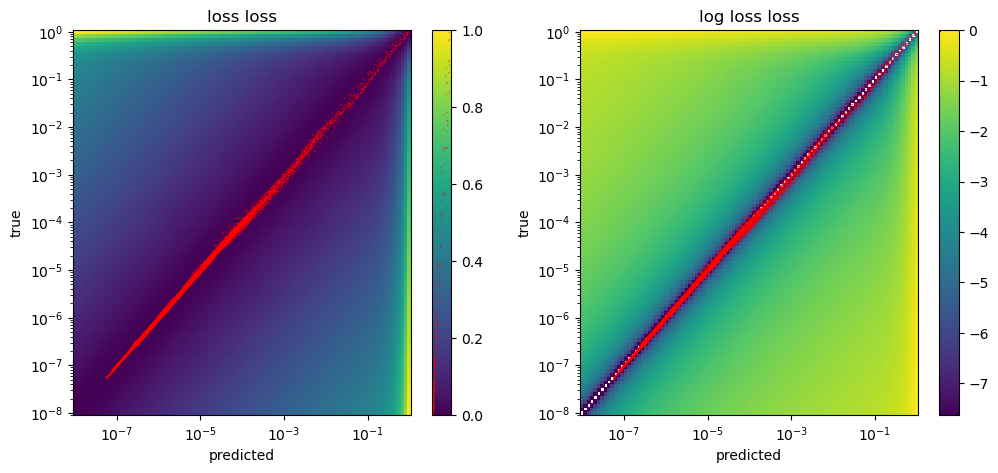

In [498]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl, epsl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl, epsl=epsl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=5, w0=10) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci), epsl=0)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

#### Boost both

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 8.1604936e-05 relative to image: 0.16220671 relmax: 0.183256


/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


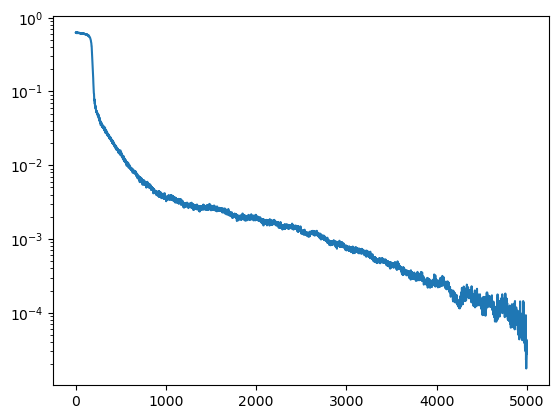

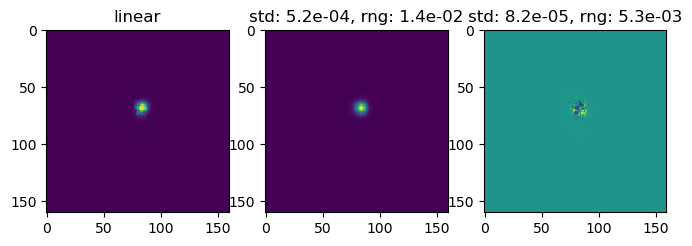

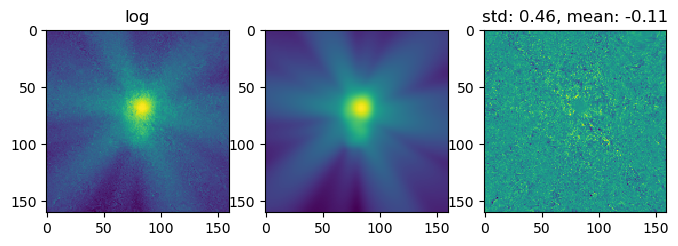

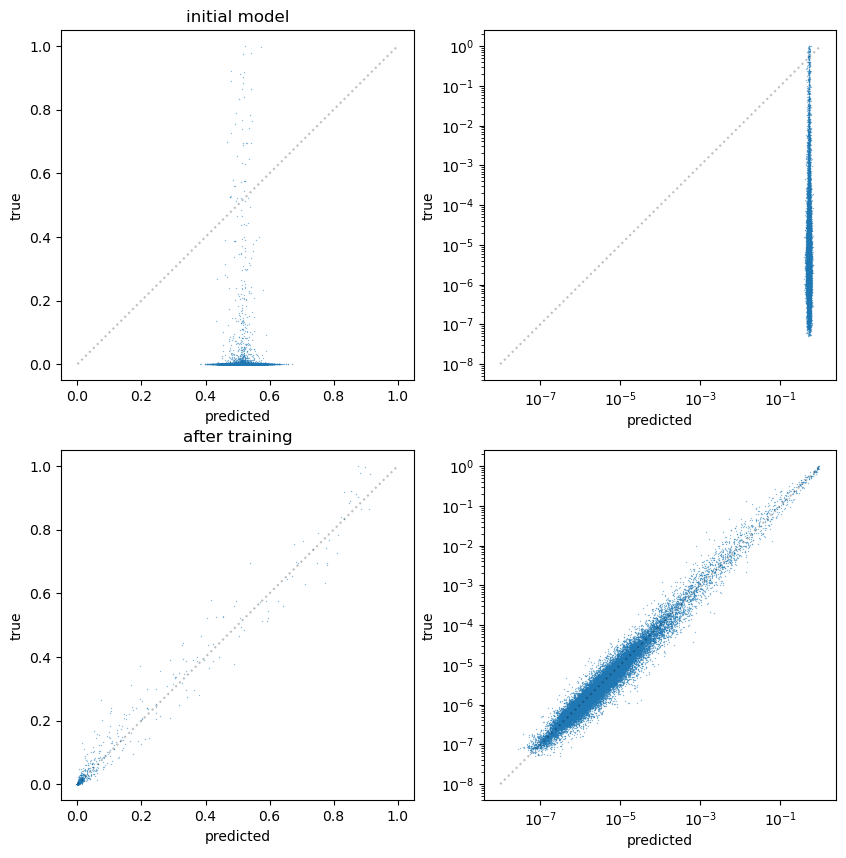

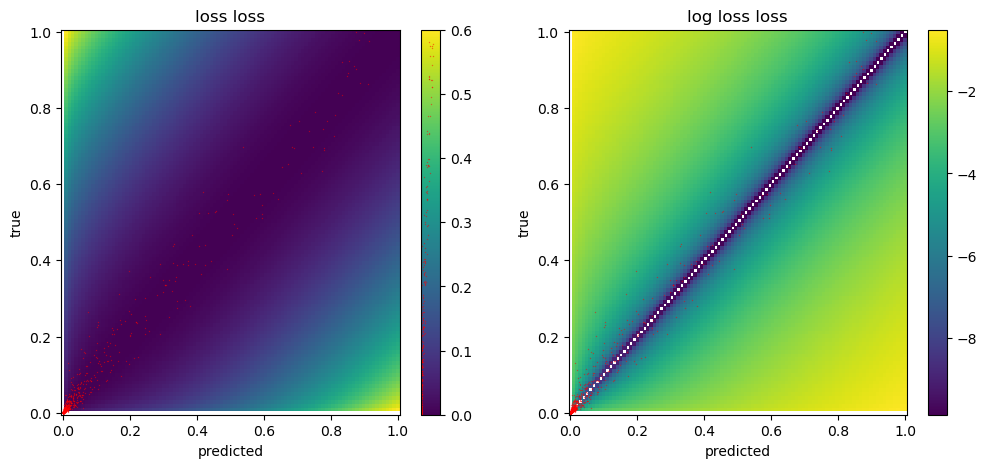

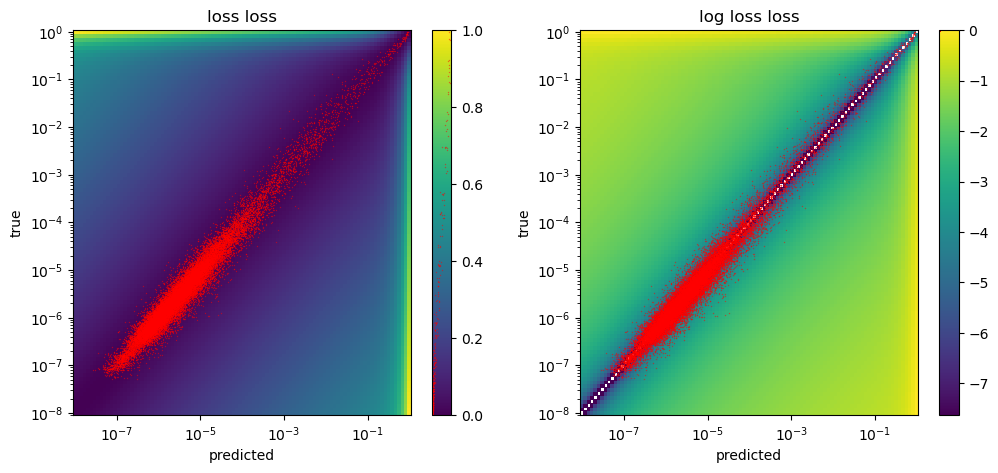

In [499]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl, epsl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl, epsl=epsl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=20, w0=40) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci), epsl=0)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

The fiducial case seems to be the fastest-converging

## Add non-uniform sampling

Try presenting the big values more frequently

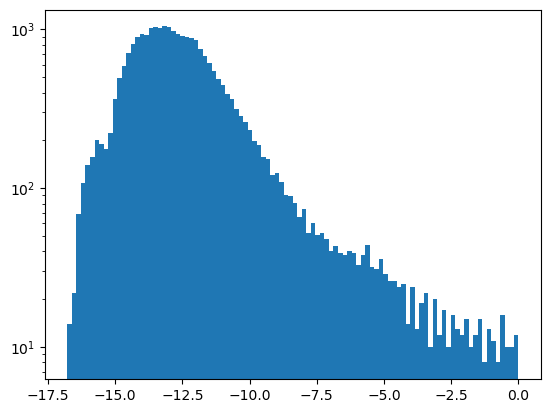

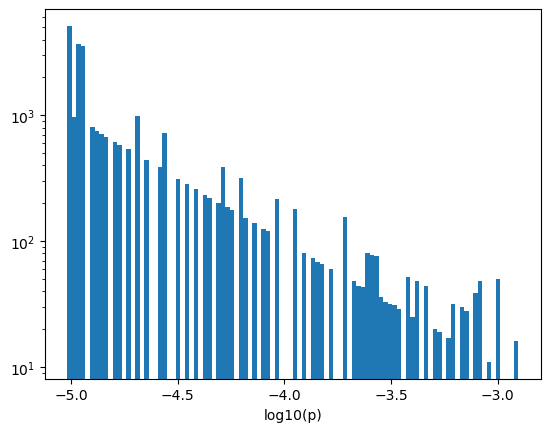

In [78]:
psf = psfarrs[512] # psf is (160, 160)
ys = psf.ravel()/psf.max()

n, binedge, _ = plt.hist(np.log(ys), bins=100, log=True)

dig = np.digitize(np.log(ys), binedge, right=False)
assert np.sum(dig==len(binedge)) == 1
dig[dig==len(binedge)] = len(binedge)-1
assert np.sum(dig==len(binedge)) == 0
dig -= 1
assert dig.max() == len(n)-1

sampleprobs = 1/n[dig]
sampleprobs = jnp.array(sampleprobs/sampleprobs.sum())
plt.figure()
plt.hist(jnp.log10(sampleprobs), bins=100, log=True)
plt.xlabel('log10(p)');

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 4.514845e-06 relative to image: 0.008974189 relmax: 0.02473032


/tmp/ipykernel_7260/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7260/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7260/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7260/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


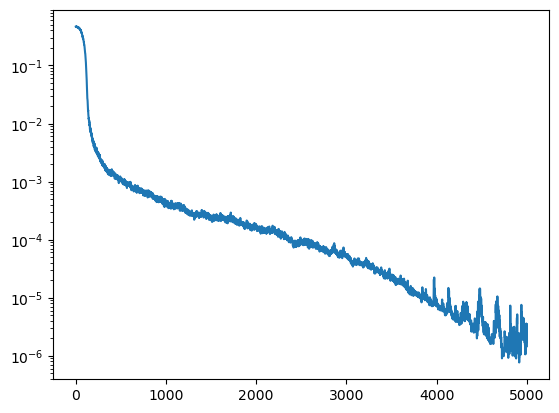

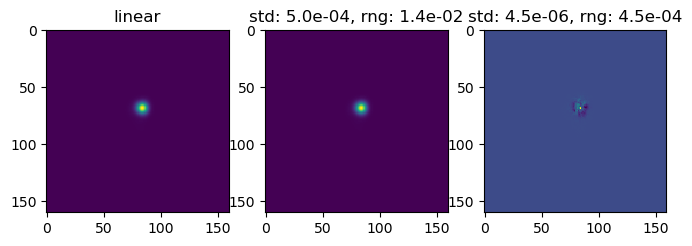

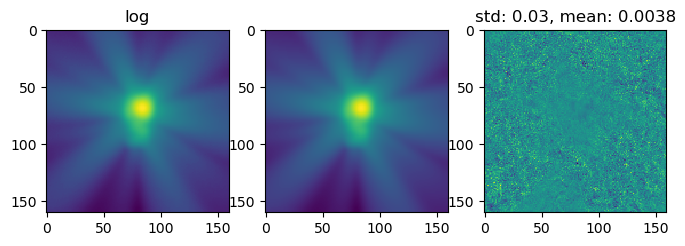

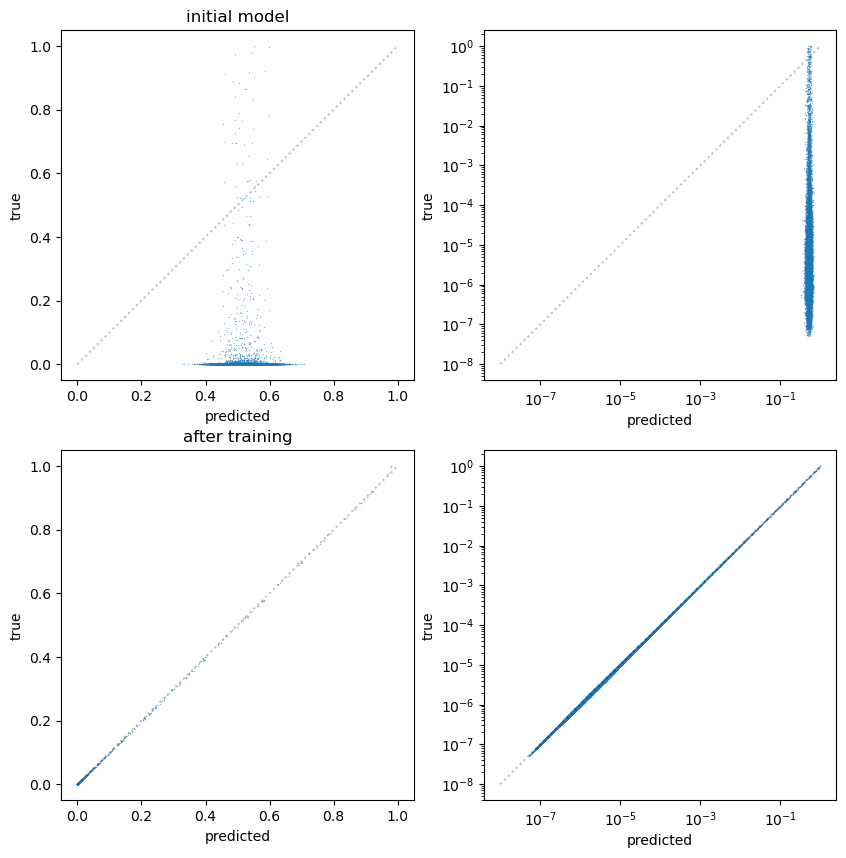

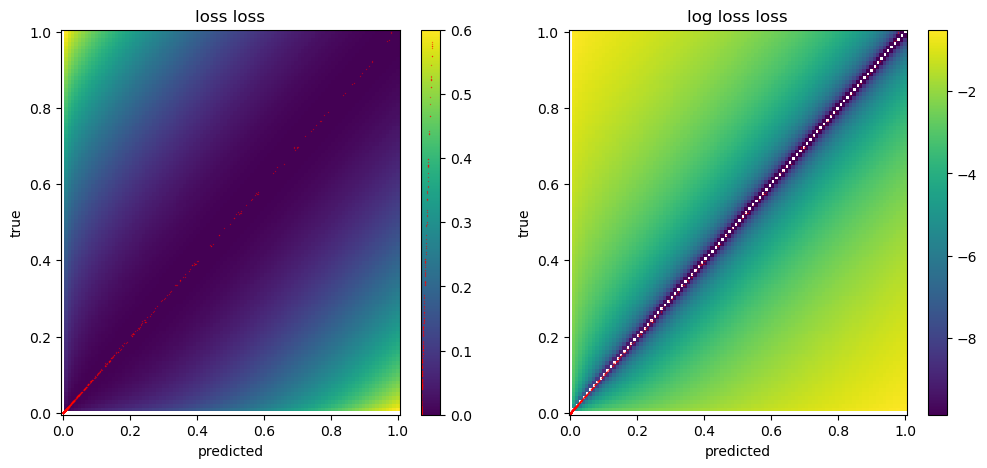

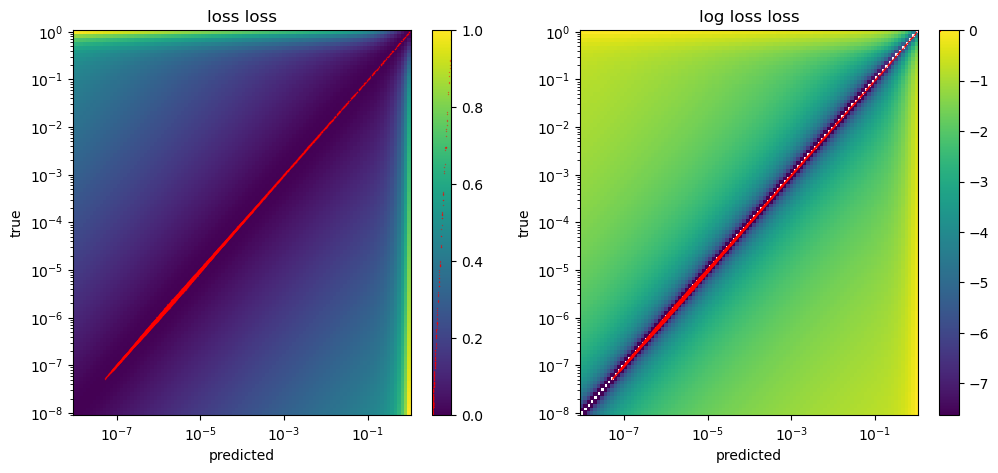

In [23]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl, epsl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl, epsl=epsl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=10, w0=20) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False, p=sampleprobs)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci), epsl=0)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

Well that helps *a lot*.  Try with replacement

  0%|          | 0/5000 [00:00<?, ?it/s]

resid std: 1.0313128e-05 relative to image: 0.020499477 relmax: 0.0315675


/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


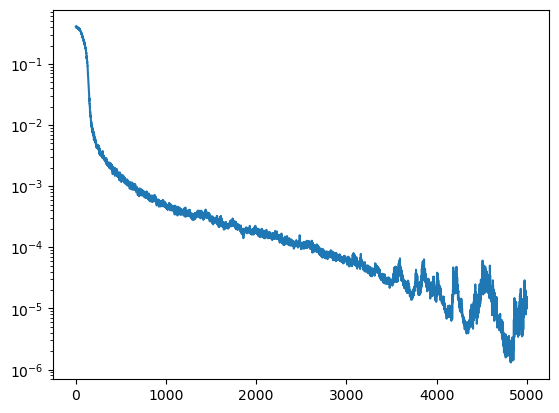

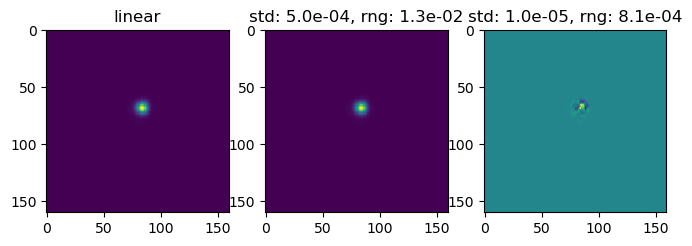

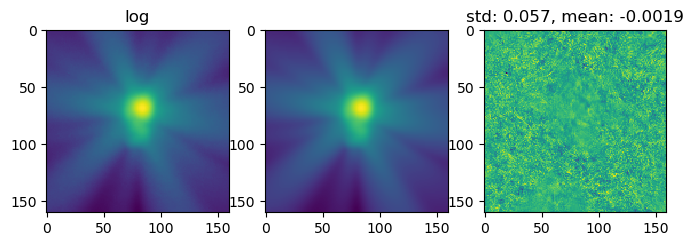

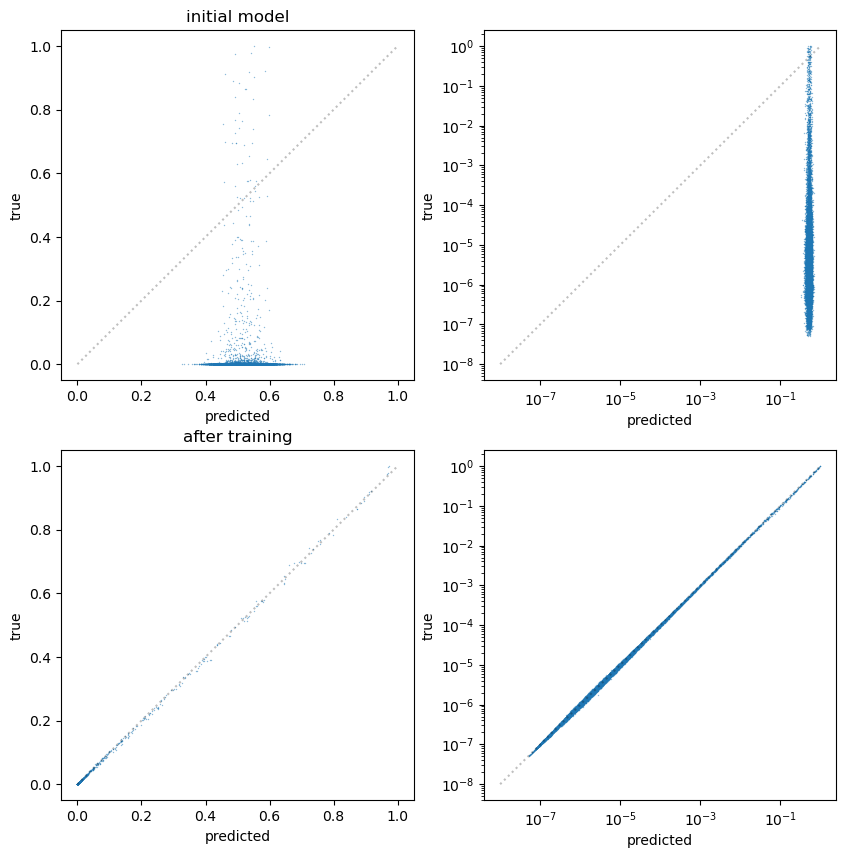

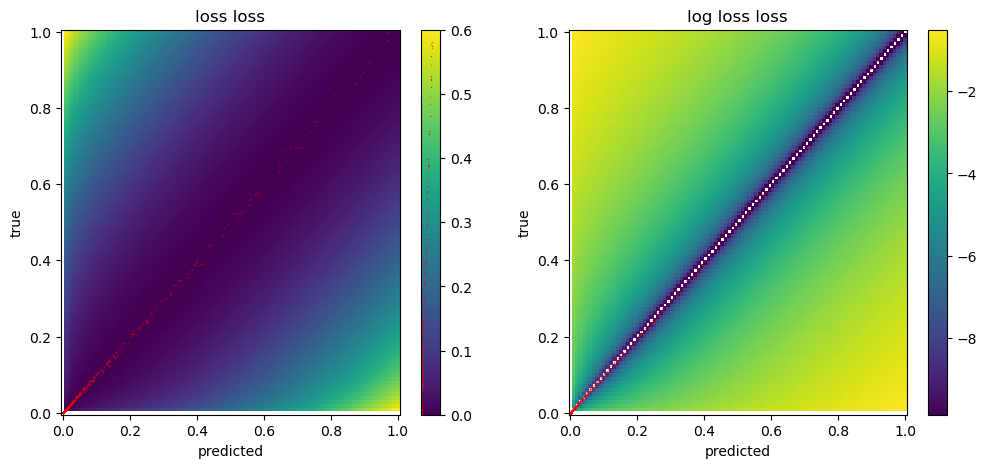

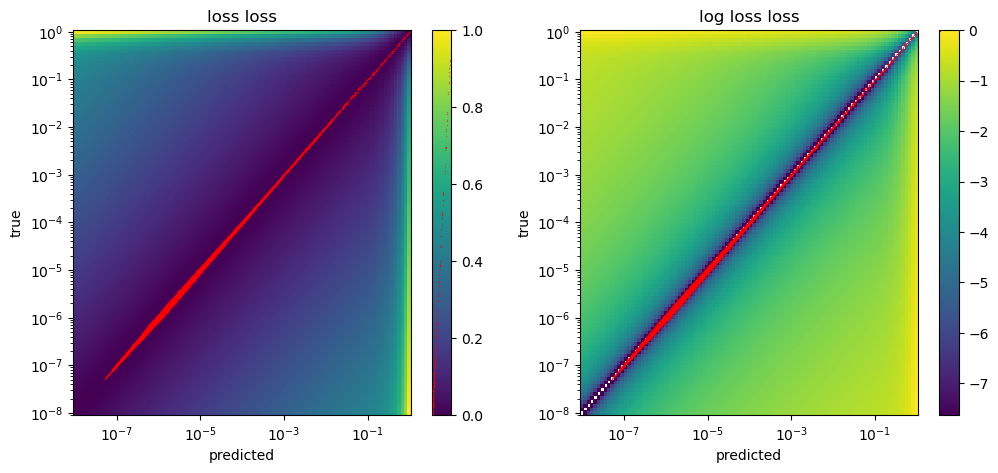

In [618]:
LEARNING_RATE = 1e-3
EPOCHS = 5000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl, epsl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl, epsl=epsl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=10, w0=20) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=True, p=sampleprobs)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci), epsl=0)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

Curiously replacement doesn't help.  Try a longer run

  0%|          | 0/25000 [00:00<?, ?it/s]

resid std: 2.595102e-06 relative to image: 0.0051583024 relmax: 0.0171843


/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: divide by zero encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/772922435.py:2: RuntimeWarning: invalid value encountered in divide
  lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
/tmp/ipykernel_7355/1516964693.py:11: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(yp, yt, np.log(l), **kwargs)
/tmp/ipykernel_7355/1516964693.py:36: RuntimeWarning: divide by zero encountered in log
  cb = axs[1].pcolor(ypl, ytl, np.log(l), **kwargs)


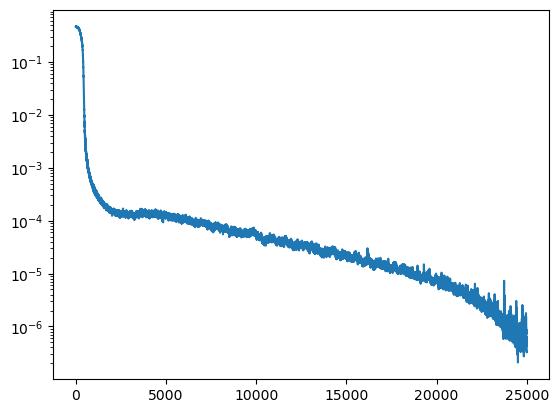

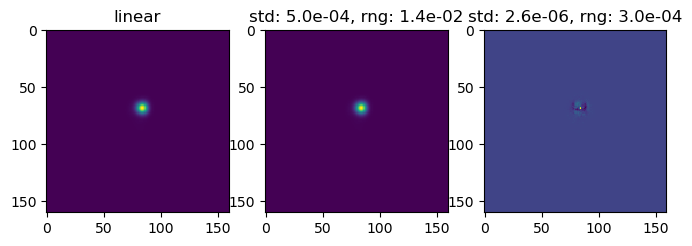

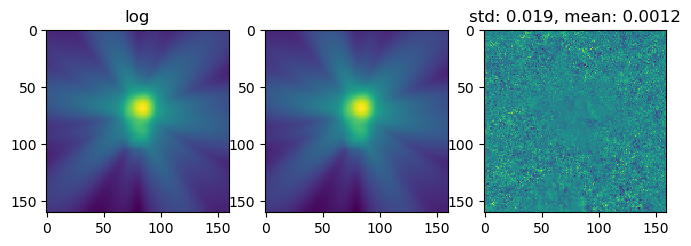

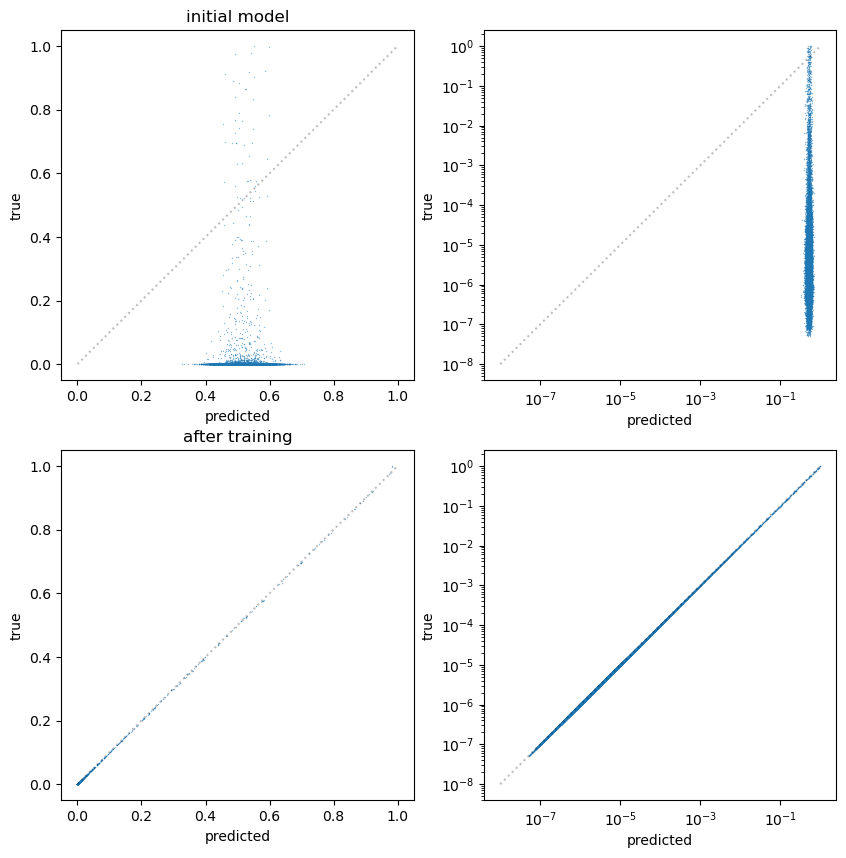

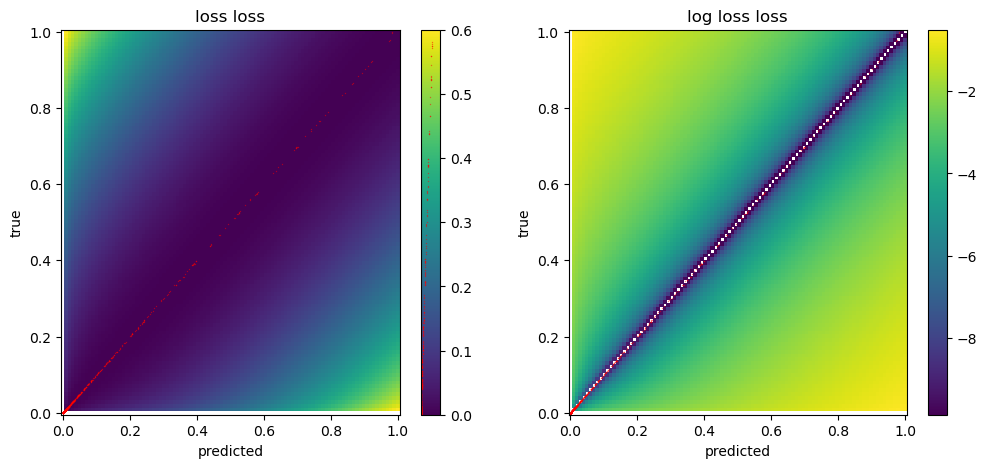

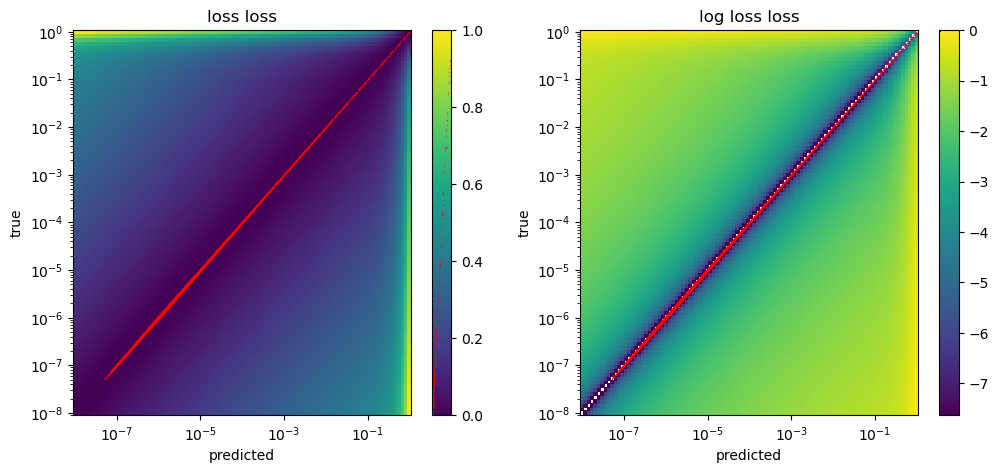

In [620]:
LEARNING_RATE = 2e-4
EPOCHS = 25000
BATCH_SIZE = 2048

loss_to_use = mixed_mse_log_loss

def mloss_weighted(model, x, y, eps=1e-2, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    w = (y/(1-eps) + eps)**2
    return np.sum(losses*w)/np.sum(w)

def mloss_equal_weighted(model, x, y, wl=0.5, epsl=0):
    y_pred = jax.vmap(model)(x)
    losses = loss_to_use(y_pred, y, wl=wl, eps=epsl)
    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl, epsl):
    loss, grads = eqx.filter_value_and_grad(mloss_equal_weighted)(model, x, y, wl=wl, epsl=epsl)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFWIRE(n_in_coo=2, hidden_size=128, num_hidden_layers=2, s0=10, w0=20) # half the default to compare to the full size real version
pred0 = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False, p=sampleprobs)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    loss = loss_to_use(jax.vmap(model)(xi), yi)
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=jnp.ones(len(batch_idx))*(1-fraci), epsl=0)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std(), 'relmax:', diff.max()/rnpsf.max())

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0,0].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].scatter(pred0.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[0,1].loglog()
axs[0,0].set_title('initial model')


axs[1,0].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5)
axs[1,1].loglog()
axs[1,0].set_title('after training')
for ax in axs.ravel():
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.plot([1e-8, 1], [1e-8, 1], color='k', ls=':', alpha=.25)


fig1, fig2 = plot_losses(loss_to_use, name='loss')
for fig in [fig1, fig2]:
    for ax in fig.axes:
        ax.scatter(pred.ravel(), ys.ravel(), s=1, lw=0, alpha=0.5, c='r')

Alright, this seems to be the winning architecture.  

# Try running it on the 4d case

In [11]:
psfarrspall = psfarrs.reshape(psfarrs.shape[0], -1)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xpxall = jnp.broadcast_to(xpx.ravel(), psfarrspall.shape)
ypxall = jnp.broadcast_to(ypx.ravel(), psfarrspall.shape)

psfxall = jnp.broadcast_to(psfxs[..., None], psfarrspall.shape)
psfyall = jnp.broadcast_to(psfys[..., None], psfarrspall.shape)

xs = jnp.stack((xpxall.ravel(), ypxall.ravel(), psfxall.ravel(), psfyall.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = jnp.array(psfarrspall.ravel()/psfarrspall.max())

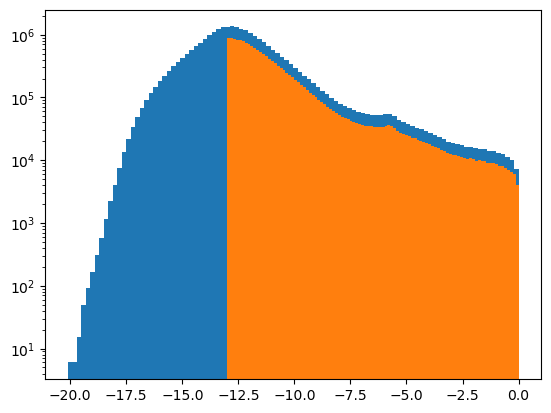

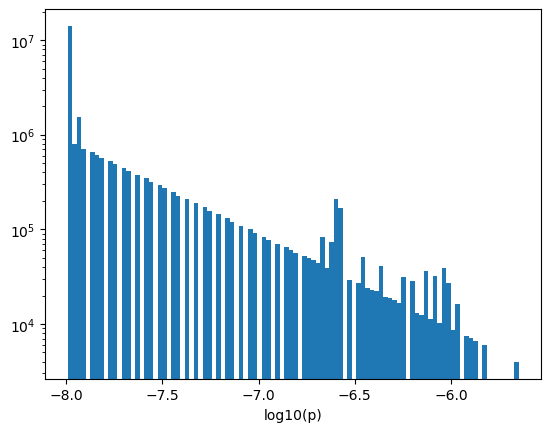

In [12]:
msk = jnp.log(ys) < -13
ymod = ys[~msk]#.set(jnp.exp(-13))

plt.hist(jnp.log(ys), bins=100, log=True);
n, binedge, _ = plt.hist(jnp.log(ymod), bins=100, log=True)

dig = np.digitize(np.log(ys), binedge, right=False)
assert np.sum(dig==len(binedge)) == 1
dig[dig==len(binedge)] = len(binedge)-1
assert np.sum(dig==len(binedge)) == 0
dig -= 1
dig[dig==-1] = 0
assert dig.max() == len(n)-1

sampleprobs = 1/n[dig]
sampleprobs = jnp.array(sampleprobs/sampleprobs.sum())

plt.figure()
plt.hist(jnp.log10(sampleprobs), bins=100, log=True);
plt.xlabel('log10(p)');

  0%|          | 0/50000 [00:00<?, ?it/s]

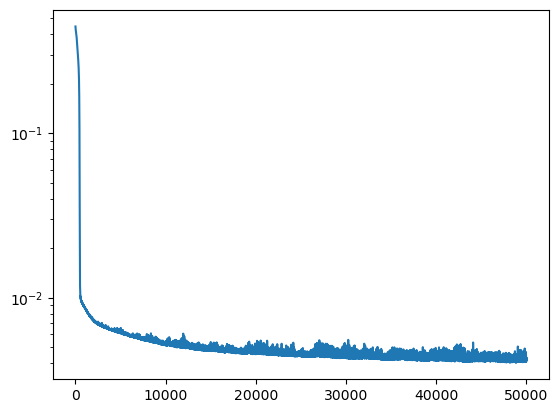

In [96]:
LEARNING_RATE = 1e-4
EPOCHS = 50000
BATCH_SIZE = ys.size//32

def mloss(model, x, y, wl=0.5, eps=0):
    yp = jax.vmap(model)(x)
    yt = y

    lterm = jnp.log((yp/(yt + eps) + yt/(yp + eps))/2)/17.7
    mseterm = (yt-yp)**2
    losses = wl * lterm + (1 - wl) * mseterm

    return np.mean(losses)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, wl, eps):
    loss, grads = eqx.filter_value_and_grad(mloss)(model, x, y, wl=wl, eps=eps)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

model = PSFWIRE(n_in_coo=4, hidden_size=128, num_hidden_layers=2, s0=10, w0=20) # half the default to compare to the full size real version

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    fraci = i / (EPOCHS-1)

    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)#, p=sampleprobs)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, wl=0.5,eps=0)#wl=jnp.ones(len(batch_idx))*(1-fraci), eps=0)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)

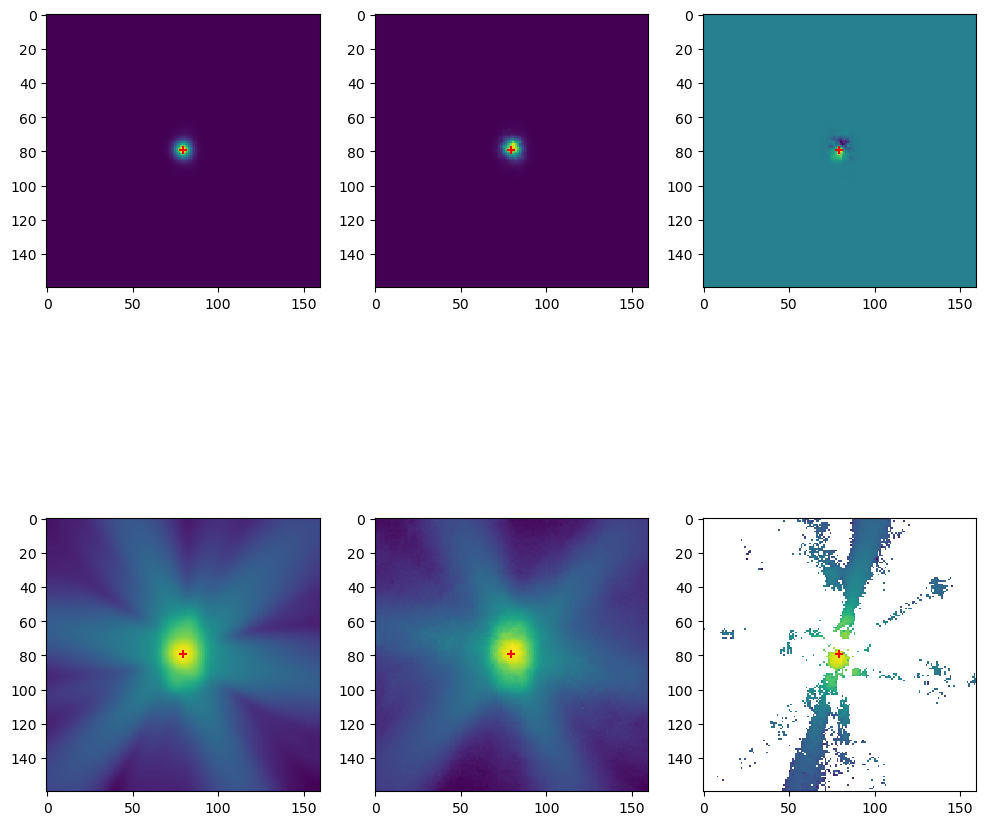

In [97]:
nearzero = np.argmin(psfxs**2+psfys**2)
xo = psfxs[nearzero]
yo = psfys[nearzero]
psftest = psfarrs[nearzero]
psftest = psftest / psftest.sum()

xos = jnp.ones((xpx.size)) * xo
yos = jnp.ones((xpx.size)) * yo

xtest = jnp.stack((xpx.ravel(), ypx.ravel(), xos, yos), axis=-1).astype(float)
xtest = xnorm.normalize(xtest)
ytest = jax.vmap(model)(xtest).reshape(psfarrs.shape[1:])
ytest = ytest / ytest.sum()

diff = psftest - ytest

fig, axs = plt.subplots(2, 3, figsize=(12, 12))

for i, y in enumerate([psftest, ytest, diff]):
    axs[0, i].imshow(y, interpolation='nearest')
    axs[1, i].imshow(jnp.log(y), interpolation='nearest')
for ax in axs.ravel():
    pscale = 0.01304098375 # Scale in arcsec/pix (after oversampling) 
    ax.scatter([xo/pscale + (psftest.shape[0]-1)/2], [yo/pscale + (psftest.shape[1]-1)/2], color='r', marker='+')